# Tessera propAMM: how retail gets worse fills on Base

- In this notebook, we analyse execution quality on [Tessera](https://defillama.com/protocol/tessera-v), the Wintermute proprietary AMM (propAMM) that has become one of the largest trading venues on Base
- PropAMMs post quotes onchain from an off-chain pricing engine and are routed to by aggregators (OKX, KyberSwap, 1inch, 0x, Paraswap, Binance Wallet…) because their quoted prices beat AMM pools
- The [0x "PropAMM Shenanigans" post](https://0x.org/post/propamm-shenanigans) documented that the quoted price does not survive until settlement: the operator refreshes a tight quote in the last Flashblock of block N, aggregators route on it, then reprices worse in the first Flashblock of block N+1 where user transactions settle, and the user's slippage tolerance silently absorbs the difference
- We measure this over ten months of onchain history and answer five questions
  1. **Is the quote honest?** Does the price an aggregator routed on survive until the fill?
  2. **Who pays?** Retail vs bots, by aggregator and by front-end
  3. **Are they trading the same pairs?** Whether the bot and aggregator differences survive when the pair is held fixed
  4. **How much?** In basis points against Tessera's own quote and against a fair reference price from the deepest Uniswap V3 / Aerodrome pool, and in dollars
  5. **When, and why?** The skim comes and goes in regimes; we detect them, test whether the keeper's onchain behaviour switches with them, measure what the market does after retail and bot fills, and look at who ends up paying at the wallet level
- In between we look for the mechanism: *why* retail fills are worse than bot fills on the same venue in the same blocks

## Usage

This is an open source notebook based on open data
- You can edit and remix this notebook yourself

To do your own data research:

- Read general instructions [how to run the tutorials](./)
- Run `scripts/base/scan-tessera-propamm.py` to collect Tessera trades, keeper price updates, transaction traces (aggregator identification, user slippage bounds) and historical quotes into a DuckDB file
- Run `scripts/base/scan-tessera-benchmark-prices.py` to add reference pool prices for a fair-price comparison
- The default database location is `~/.tradingstrategy/tessera/tessera-base.duckdb`; override with `TESSERA_DUCKDB_PATH`

Terminology used below:

- **Quote**: Tessera's own `tesseraSwapViewAmounts()` output for the trade size at the end of the previous block — the best onchain approximation of what the aggregator routed on
- **Fill**: the amounts in the `TesseraTrade` event
- **Quote-to-fill bps**: `(quoted_out − filled_out) / quoted_out × 10 000`; positive means the user got less than quoted
- **Fair price**: the marginal (mid) price of the deepest concentrated-liquidity pool for the pair at the end of the previous block
- **Retail**: trades routed through a labelled aggregator router; **bot**: trades from known arbitrage contracts or EIP-7702 self-calls; **unlabelled**: routers we could not identify
- **In-block position**: `cumulative_gas_used / block_gas_used` of the transaction, 0 = top of block, 1 = bottom; Base blocks are built from ten 200 ms Flashblocks in order, so this is the proxy for the Flashblock index

## Setup

- Set up notebook rendering output mode
- Use static image charts so this notebook is readable on Github / ReadTheDocs
- Colours are assigned by role and kept fixed across every chart: retail is blue, bots are orange, unlabelled flow is grey, keeper price updates are aqua

In [1]:
import os
from pathlib import Path

import duckdb
import numpy as np
import pandas as pd
import plotly.graph_objects as go
import plotly.io as pio
from plotly.offline import init_notebook_mode
from plotly.subplots import make_subplots

from eth_defi.research.notebook import set_large_plotly_chart_font

pd.options.display.float_format = "{:,.2f}".format
pd.options.display.max_columns = None
pd.options.display.max_rows = 60

image_format = "png"
width = 1400
height = 700

init_notebook_mode()
pio.renderers.default = image_format
current_renderer = pio.renderers[image_format]
current_renderer.width = width
current_renderer.height = height

set_large_plotly_chart_font(title_font_size=26, font_size=18, legend_font_size=18, axis_title_font_size=20, line_width=2)

# Fixed role colours, never cycled
COLOURS = {
    "retail": "#2a78d6",
    "bot": "#eb6834",
    "unlabelled": "#8a8a8a",
    "price update": "#1baf7a",
    "quote": "#4a3aa7",
    "fill": "#e34948",
}
FLOW_ORDER = ["retail", "bot", "unlabelled"]

# Fixed aggregator colour order (validated categorical palette, slots 1-8)
AGGREGATOR_COLOURS = {
    "okx": "#2a78d6",
    "kyberswap": "#eb6834",
    "0x": "#1baf7a",
    "1inch": "#eda100",
    "paraswap": "#e87ba4",
    "binance-wallet": "#008300",
    "lifi": "#4a3aa7",
    "aggregator-2f68": "#e34948",
}


MAJORS = ["WETH/USDC", "USDC/WETH", "cbBTC/USDC", "USDC/cbBTC"]


def detect_change_points(series: pd.Series, min_size: int = 5, min_shift: float = 2.0) -> list[pd.Timestamp]:
    """Optimal partitioning of a daily series with a sum-of-absolute-deviations cost.

    Exact dynamic programme (not greedy binary segmentation, which cannot isolate a short
    excursion in the middle of a series): minimises the total within-segment absolute deviation
    from the segment median plus a penalty of ``min_shift * min_size`` per extra segment, with
    every segment at least ``min_size`` observations. Adjacent segments whose medians differ by
    less than ``min_shift`` are merged afterwards. Missing days must already be dropped by the caller.
    """
    values = series.dropna()
    v = values.values
    n = len(v)
    penalty = min_shift * min_size
    if n < 2 * min_size:
        return []

    def cost(i: int, j: int) -> float:
        seg = v[i:j]
        return float(np.abs(seg - np.median(seg)).sum())

    best = [np.inf] * (n + 1)
    prev = [-1] * (n + 1)
    best[0] = -penalty
    for j in range(min_size, n + 1):
        for i in range(0, j - min_size + 1):
            if best[i] == np.inf:
                continue
            c = best[i] + cost(i, j) + penalty
            if c < best[j]:
                best[j], prev[j] = c, i
    cuts: list[int] = []
    j = n
    while prev[j] > 0:
        cuts.append(prev[j])
        j = prev[j]
    cuts = sorted(cuts)

    changed = True
    while changed and cuts:
        changed = False
        edges = [0] + cuts + [n]
        for k in range(1, len(edges) - 1):
            if abs(np.median(v[edges[k - 1] : edges[k]]) - np.median(v[edges[k] : edges[k + 1]])) < min_shift:
                cuts.pop(k - 1)
                changed = True
                break
    return [values.index[k] for k in cuts]


def build_regimes(daily: pd.Series, cuts: list[pd.Timestamp], skim_threshold_bps: float = 3.0) -> pd.DataFrame:
    """Turn change points into a regimes table. Positive medians mean users received less than fair."""
    edges = [daily.index.min()] + list(cuts) + [daily.index.max() + pd.Timedelta(days=1)]
    rows = []
    for i, (start, end) in enumerate(zip(edges[:-1], edges[1:])):
        seg = daily[(daily.index >= start) & (daily.index < end)]
        rows.append({"regime_id": i, "start": start, "end": end - pd.Timedelta(days=1), "days": len(seg), "retail_fill_vs_fair_p50": seg.median(), "label": "skim" if seg.median() >= skim_threshold_bps else "honest"})
    return pd.DataFrame(rows)


def assign_regime(ts: pd.Series, regimes: pd.DataFrame) -> pd.Series:
    """Map timestamps to regime ids by date range."""
    out = pd.Series(np.nan, index=ts.index)
    for _, r in regimes.iterrows():
        out[(ts >= r["start"]) & (ts < r["end"] + pd.Timedelta(days=1))] = r["regime_id"]
    return out


def add_regime_bands(fig: go.Figure, regimes: pd.DataFrame) -> go.Figure:
    """Shade skim regimes and label every regime at the top of a time-series chart."""
    for _, r in regimes.iterrows():
        x1 = r["end"] + pd.Timedelta(days=1)
        if r["label"] == "skim":
            fig.add_vrect(x0=r["start"], x1=x1, fillcolor=COLOURS["fill"], opacity=0.08, line_width=0, layer="below")
        fig.add_annotation(x=r["start"] + (x1 - r["start"]) / 2, y=0.99, yref="paper", text=f"{r['label']} {r['retail_fill_vs_fair_p50']:+.1f} bps", showarrow=False, yanchor="top", font=dict(size=14), bgcolor="rgba(255,255,255,0.85)")
    return fig


def style(fig: go.Figure, title: str, xaxis: str, yaxis: str, legend: bool = True) -> go.Figure:
    """Apply the shared chart style: one y axis, recessive grid, legend only when needed."""
    fig.update_layout(
        title=title,
        xaxis_title=xaxis,
        yaxis_title=yaxis,
        template="plotly_white",
        showlegend=legend,
        legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="left", x=0, traceorder="normal"),
        margin=dict(l=70, r=30, t=110, b=70),
        bargap=0.15,
    )
    fig.update_xaxes(showgrid=False, zeroline=False)
    fig.update_yaxes(gridcolor="#e6e6e3", zeroline=False)
    return fig

## Open the dataset

- Connect to the DuckDB file produced by the two scanner scripts, read-only
- The raw tables cover the full Tessera history on Base; the enrichment tables (traces, quotes, benchmarks) cover the analysis window from block 48,000,000 (July 2026 onwards)
- Show what we have

In [2]:
duckdb_path = Path(os.environ.get("TESSERA_DUCKDB_PATH", "~/.tradingstrategy/tessera/tessera-base.duckdb")).expanduser()
assert duckdb_path.exists(), f"Run scripts/base/scan-tessera-propamm.py first, {duckdb_path} missing"
con = duckdb.connect(str(duckdb_path), read_only=True)
con.execute("SET enable_progress_bar = false")

WINDOW_START_BLOCK = int(os.environ.get("TESSERA_WINDOW_START_BLOCK", "48000000"))
USDC = "0x833589fCD6eDb6E08f4c7C32D4f71b54bdA02913"
WETH = "0x4200000000000000000000000000000000000006"

tables = ["blocks", "trades", "price_updates", "trade_calls", "trade_orders", "quotes", "benchmark_swaps", "trade_benchmarks"]
overview = pd.DataFrame(
    [(t, con.execute(f"SELECT count(*) FROM {t}").fetchone()[0]) for t in tables],
    columns=["Table", "Rows"],
)
history = con.execute("SELECT min(timestamp), max(timestamp), min(block_number), max(block_number) FROM trades").fetchone()
window = con.execute("SELECT min(timestamp), max(timestamp) FROM trades WHERE block_number >= ?", [WINDOW_START_BLOCK]).fetchone()
print(f"Full history: {history[0]:%Y-%m-%d} – {history[1]:%Y-%m-%d} (blocks {history[2]:,} – {history[3]:,})")
print(f"Analysis window: {window[0]:%Y-%m-%d} – {window[1]:%Y-%m-%d} (block {WINDOW_START_BLOCK:,} onwards)")
display(overview.style.format({"Rows": "{:,}"}))

Full history: 2025-10-30 – 2026-09-16 (blocks 37,519,381 – 51,404,942)
Analysis window: 2026-06-30 – 2026-09-16 (block 48,000,000 onwards)


,Table,Rows
0,blocks,"13,011,882"
1,trades,"8,389,439"
2,price_updates,"56,660,400"
3,trade_calls,"811,848"
4,trade_orders,"811,848"
5,quotes,"2,897,412"
6,benchmark_swaps,"4,709,491"
7,trade_benchmarks,"712,975"


## Load trades in the analysis window

- Join the per-trade analysis view with the fair-price benchmark view
- Classify flow: `retail` is anything routed through a labelled aggregator router, `bot` is a known arbitrage contract or an EIP-7702 self-call, `unlabelled` is a router we could not identify
- Compute the USD notional from the USDC leg of the trade, and the dollar value of the quote-to-fill gap

In [3]:
df = con.execute("""
    SELECT
        a.block_number, a.timestamp, a.tx_hash, a.log_index, a.tx_index,
        a.token_in, a.token_out, a.symbol_in, a.symbol_out,
        a.amount_in_decimal, a.amount_out_decimal,
        a.aggregator, a.frontend, a.wallet_kind, a.client_data, a.is_self_call, a.router, a.tx_from,
        a.rel_gas_position, a.max_priority_fee_per_gas,
        a.quote_to_fill_bps, a.same_block_quote_to_fill_bps, a.size_impact_bps,
        a.user_slippage_bps, a.user_slippage_consumed_fraction, a.user_headroom_bps, a.user_route_headroom_bps,
        a.given_slippage_bps, a.order_matches_leg,
        b.fill_vs_benchmark_bps, b.quote_vs_benchmark_bps, b.benchmark_age_blocks, b.protocol AS benchmark_protocol, b.benchmark_fee_bps,
        b.pool, b.sells_token0, b.fill_price_t1_per_t0
    FROM trade_analysis a
    LEFT JOIN trade_vs_benchmark b ON b.tx_hash = a.tx_hash AND b.log_index = a.log_index
    WHERE a.venue = 'tessera' AND a.block_number >= ?
""", [WINDOW_START_BLOCK]).df()

df["pair"] = df["symbol_in"] + "/" + df["symbol_out"]
df["flow"] = np.select(
    [(df["aggregator"] == "bot") | df["is_self_call"].fillna(False), df["aggregator"].notna()],
    ["bot", "retail"],
    default="unlabelled",
)
df["notional_usd"] = np.where(df["token_in"] == USDC, df["amount_in_decimal"], np.where(df["token_out"] == USDC, df["amount_out_decimal"], np.nan))
df["extracted_usd"] = df["quote_to_fill_bps"] / 10_000 * df["notional_usd"]
df["hour"] = df["timestamp"].dt.floor("h")
df["day"] = df["timestamp"].dt.floor("D")

summary = df.groupby("flow").agg(
    trades=("tx_hash", "size"),
    notional_usd=("notional_usd", "sum"),
    median_quote_to_fill_bps=("quote_to_fill_bps", "median"),
    has_user_bound=("user_slippage_bps", lambda s: s.notna().mean()),
).reindex(FLOW_ORDER)
summary["share_of_trades"] = summary["trades"] / summary["trades"].sum()
display(summary.style.format({"trades": "{:,}", "notional_usd": "${:,.0f}", "median_quote_to_fill_bps": "{:.2f}", "has_user_bound": "{:.0%}", "share_of_trades": "{:.0%}"}))

,trades,notional_usd,median_quote_to_fill_bps,has_user_bound,share_of_trades
flow,,,,,
retail,"409,647","$299,399,768",4.61,13%,56%
bot,"156,874","$782,651,280",-0.32,3%,22%
unlabelled,"162,071","$155,689,727",4.85,0%,22%


## Dataset overview: pairs and volume

- Tessera volume is concentrated in a handful of pairs against USDC
- Retail and bot flow have very different pair preferences: bots concentrate on WETH/USDC and cbBTC/USDC where the reference price is tightest

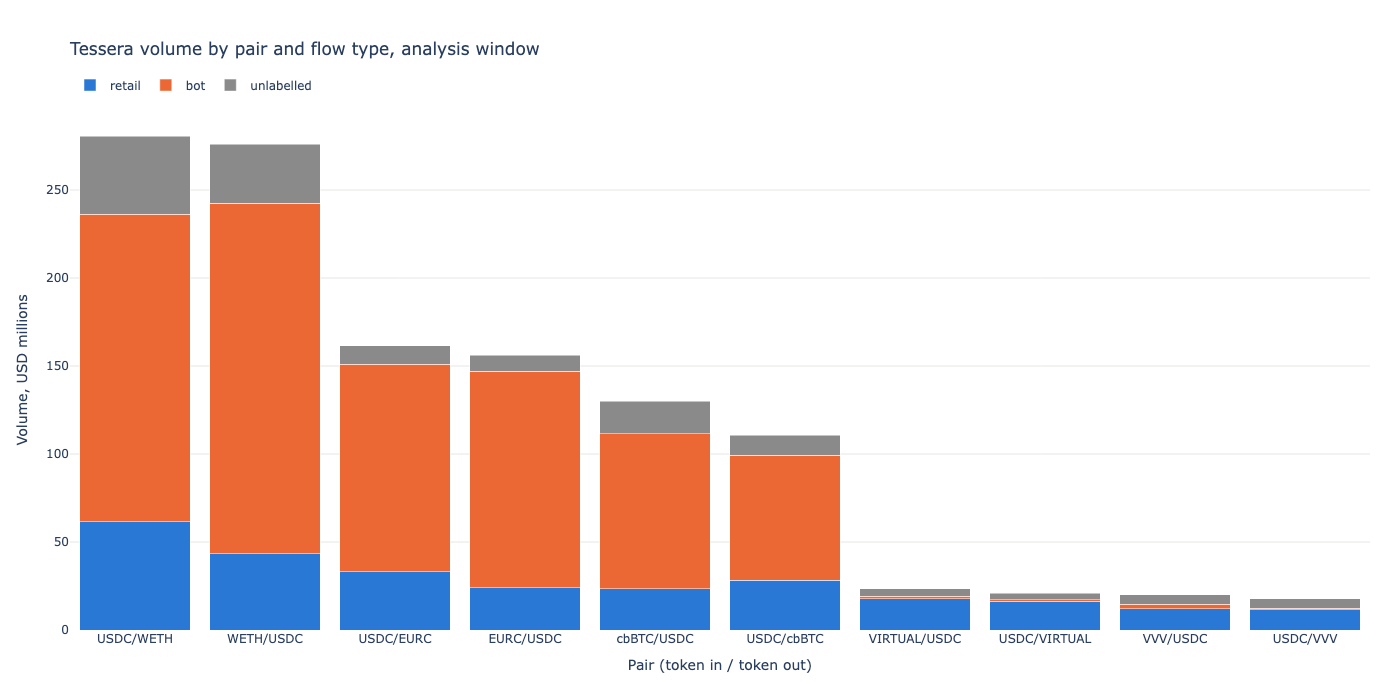

flow,bot,retail,unlabelled,total
pair,,,,
USDC/WETH,$174.7M,$61.5M,$44.5M,$280.7M
WETH/USDC,$199.2M,$43.4M,$33.4M,$276.0M
USDC/EURC,$117.8M,$33.2M,$10.5M,$161.5M
EURC/USDC,$122.9M,$24.0M,$9.2M,$156.1M
cbBTC/USDC,$88.0M,$23.5M,$18.5M,$130.0M
USDC/cbBTC,$70.8M,$28.3M,$11.5M,$110.7M
VIRTUAL/USDC,$1.5M,$17.7M,$4.1M,$23.3M
USDC/VIRTUAL,$0.8M,$16.3M,$3.8M,$20.9M
VVV/USDC,$2.6M,$12.2M,$5.4M,$20.1M


In [4]:
pairs = df.groupby(["pair", "flow"]).agg(trades=("tx_hash", "size"), notional_usd=("notional_usd", "sum")).reset_index()
pair_order = pairs.groupby("pair")["notional_usd"].sum().sort_values(ascending=False).index[:10]
pairs = pairs[pairs["pair"].isin(pair_order)]

fig = go.Figure()
for flow in FLOW_ORDER:
    sub = pairs[pairs["flow"] == flow].set_index("pair").reindex(pair_order)
    fig.add_bar(name=flow, x=list(pair_order), y=sub["notional_usd"] / 1e6, marker_color=COLOURS[flow])
fig.update_layout(barmode="stack")
style(fig, "Tessera volume by pair and flow type, analysis window", "Pair (token in / token out)", "Volume, USD millions").show()

table = df.pivot_table(index="pair", columns="flow", values="notional_usd", aggfunc="sum", fill_value=0).reindex(pair_order)
table["total"] = table.sum(axis=1)
display((table / 1e6).style.format("${:,.1f}M"))

**What this chart shows.** Tessera's traded volume in the analysis window, split by pair and by who traded: retail (a labelled aggregator on the call path), bots (known arbitrage contracts or self-calling EIP-7702 wallets), and unlabelled routers we could not identify. The table below gives the same split in dollars.

**What the result means.** Volume is concentrated in WETH/USDC (about $550M both directions), EURC/USDC and cbBTC/USDC. Bots dominate the dollar volume on those pairs ($783M in total against $299M of retail) even though retail places more trades (410k against 157k): bots trade in large, regular clips, retail in small tickets. VIRTUAL, VVV and AERO are the reverse, small volume and mostly retail.

**What it means for retail users.** A retail user on Tessera is sharing the venue with a professional counterparty that trades the same pairs in far larger size. Everything that follows compares the two side by side in the same blocks, which is the fair test of whether the venue treats them the same. The unlabelled slice (22 % of trades) is reported separately and never counted as retail, so the retail figures are not inflated by flow we could not classify.

# Question 1: is the quote honest?

## Keeper price updates cluster at the top and bottom of every block

- Tessera's pricing engine reads quotes from a store contract that the operator's keeper wallet writes to several times per block, with no events emitted
- If updates were driven by market data they would be spread evenly through the block
- Instead they cluster at the very top and the very bottom of the block: the 0x post's "quote in the last Flashblock, reprice in the first Flashblock" signature, here over the whole analysis window

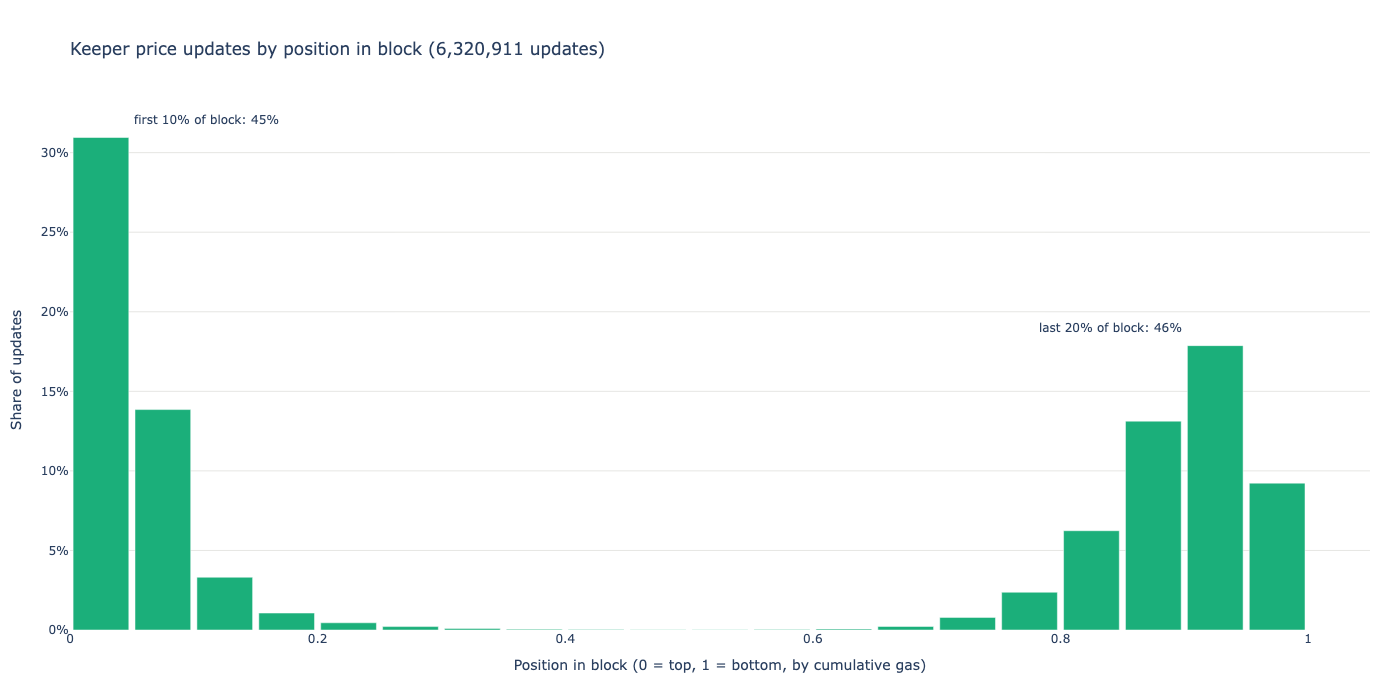

In [5]:
updates = con.execute("""
    SELECT floor(rel_gas_position * 20) / 20 AS position_bin, count(*) AS n
    FROM price_update_analysis
    WHERE selector = '0x1667d875' AND block_number >= ? AND rel_gas_position IS NOT NULL
    GROUP BY 1 ORDER BY 1
""", [WINDOW_START_BLOCK]).df()
updates["share"] = updates["n"] / updates["n"].sum()

fig = go.Figure(go.Bar(x=updates["position_bin"] + 0.025, y=updates["share"], width=0.045, marker_color=COLOURS["price update"], name="price updates"))
top = updates.loc[updates["position_bin"] < 0.1, "share"].sum()
bottom = updates.loc[updates["position_bin"] >= 0.8, "share"].sum()
fig.add_annotation(x=0.05, y=updates["share"].max(), text=f"first 10% of block: {top:.0%}", showarrow=False, yshift=18, xanchor="left")
fig.add_annotation(x=0.9, y=updates.loc[updates["position_bin"] >= 0.8, "share"].max(), text=f"last 20% of block: {bottom:.0%}", showarrow=False, yshift=18, xanchor="right")
style(fig, f"Keeper price updates by position in block ({updates['n'].sum():,} updates)", "Position in block (0 = top, 1 = bottom, by cumulative gas)", "Share of updates", legend=False)
fig.update_yaxes(tickformat=".0%")
fig.show()

**What this chart shows.** Where in the block Tessera's keeper writes new quotes to its price store, measured by cumulative gas used at the point the update transaction executes (0 = top of block, 1 = bottom). Base builds each two-second block from ten 200 ms Flashblocks in order, so position in block is a proxy for the Flashblock the update landed in.

**What the result means.** The distribution is bimodal to the point of being empty in the middle: 45 % of updates land in the first tenth of the block and 46 % in the last fifth, with almost nothing in between. A keeper reacting to market data would spread its updates through the block. This pattern is the timing signature described by 0x: refresh the quote at the very end of one block, where aggregators snapshot it, and write again at the very top of the next, where user transactions settle.

**What it means for retail users.** The price an aggregator saw when it chose Tessera was written at the bottom of the previous block; the price a user actually trades against was written at the top of their own block, before their transaction executed. Nothing in the user's wallet, front-end or slippage setting can see this happen: both writes are ordinary transactions from the venue's own keeper, and the only trace they leave is in the quote the user ends up receiving.

## Retail fills land a median 4.6 bps below Tessera's own quote, bots do not

- For every trade we recomputed Tessera's own quote for the exact trade size at the end of the previous block, the moment an aggregator would have snapshotted it
- Positive quote-to-fill bps means the user received less than that quote
- Retail flow pays a consistent few basis points; bots fill at or better than the quote
- The retail curve has steps at exactly 0, 1, 2 and 4 bps: the degradation is quantised in whole basis points, a discrete pricing parameter rather than continuous market noise

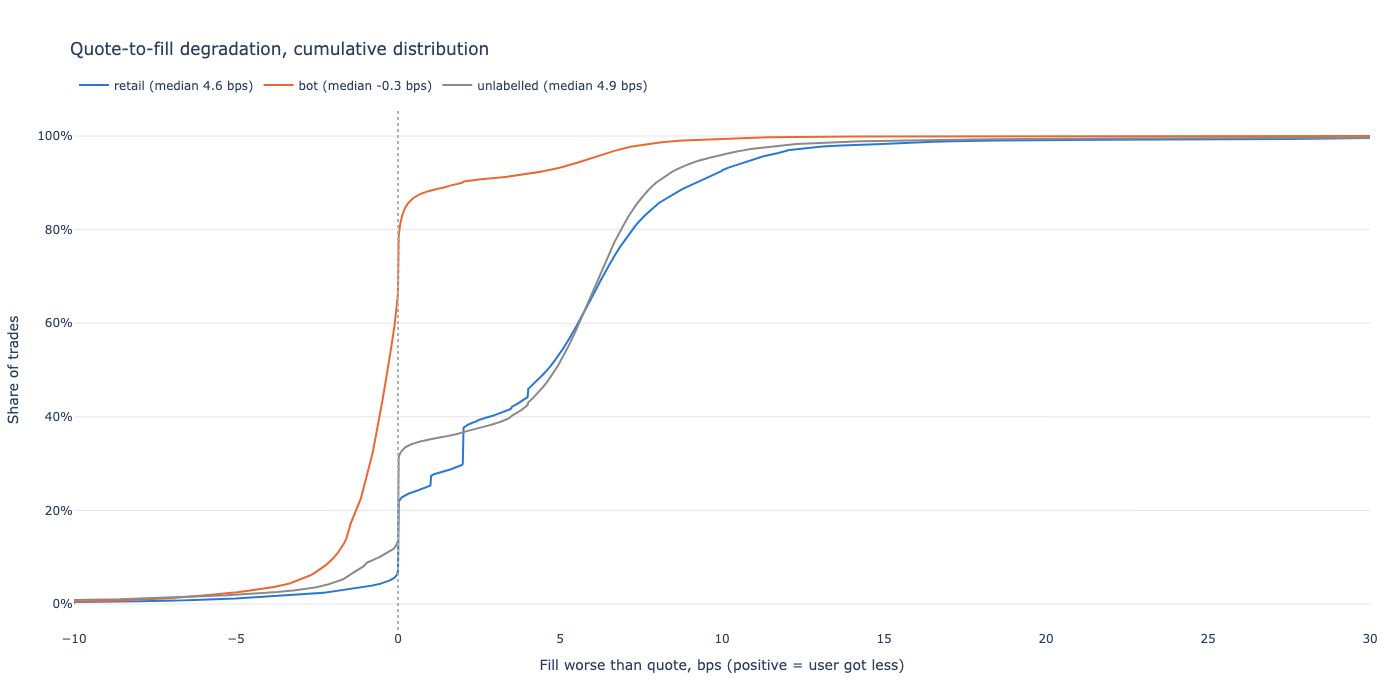

,count,mean,10%,50%,90%,99%
flow,,,,,,
retail,"408,080.00",4.61,0.00,4.61,9.20,18.17
bot,"155,736.00",-0.22,-1.97,-0.32,2.00,8.69
unlabelled,"160,236.00",3.85,-0.58,4.85,7.96,15.16


In [6]:
fig = go.Figure()
for flow in FLOW_ORDER:
    s = df.loc[df["flow"] == flow, "quote_to_fill_bps"].dropna().clip(-10, 30).sort_values()
    fig.add_scatter(x=s.values, y=np.linspace(0, 1, len(s)), mode="lines", name=f"{flow} (median {s.median():.1f} bps)", line=dict(color=COLOURS[flow], width=2))
fig.add_vline(x=0, line=dict(color="#b0b0ad", dash="dot"))
style(fig, "Quote-to-fill degradation, cumulative distribution", "Fill worse than quote, bps (positive = user got less)", "Share of trades")
fig.update_yaxes(tickformat=".0%")
fig.show()

q = df.groupby("flow")["quote_to_fill_bps"].describe(percentiles=[0.1, 0.5, 0.9, 0.99]).reindex(FLOW_ORDER)[["count", "mean", "10%", "50%", "90%", "99%"]]
display(q.style.format("{:,.2f}"))

**What this chart shows.** For every trade we recomputed Tessera's own quote for that exact trade size at the end of the previous block, the best onchain approximation of the price the aggregator routed on, and compared it with the amount the user actually received. The curves are cumulative distributions of that gap in basis points: positive means the user got less than quoted.

**What the result means.** Retail is filled a median 4.6 bps below the quote (p90 9.2 bps, p99 18 bps) while bots are filled 0.3 bps *better* than it. The retail curve rises in steps at exactly 0, 1, 2 and 4 bps: the degradation is not continuous market noise but a small set of discrete values, which is what a pricing parameter produces. The remaining unlabelled flow (4.9 bps) behaves like retail, so excluding it does not flatter the venue.

**What it means for retail users.** On a $10,000 swap, 4.6 bps is $4.60 taken between the moment the router chose Tessera and the moment the trade settled, on top of whatever the quote itself embedded, and on roughly nine trades in ten. It never shows up as a failed transaction or a warning: the fill is inside the slippage tolerance the front-end set, so from the user's side the trade simply worked. The same venue, in the same blocks, fills bots at or better than the quote, which rules out the explanation that the quote was stale for everyone.

## The degradation is largest on the deepest pairs

- The degradation is not a property of one illiquid token: it is present on WETH/USDC and cbBTC/USDC, the deepest markets on Base
- The bottom of the distribution (p10) sits around one basis point on the majors — a spread-like floor — while the median is five to six

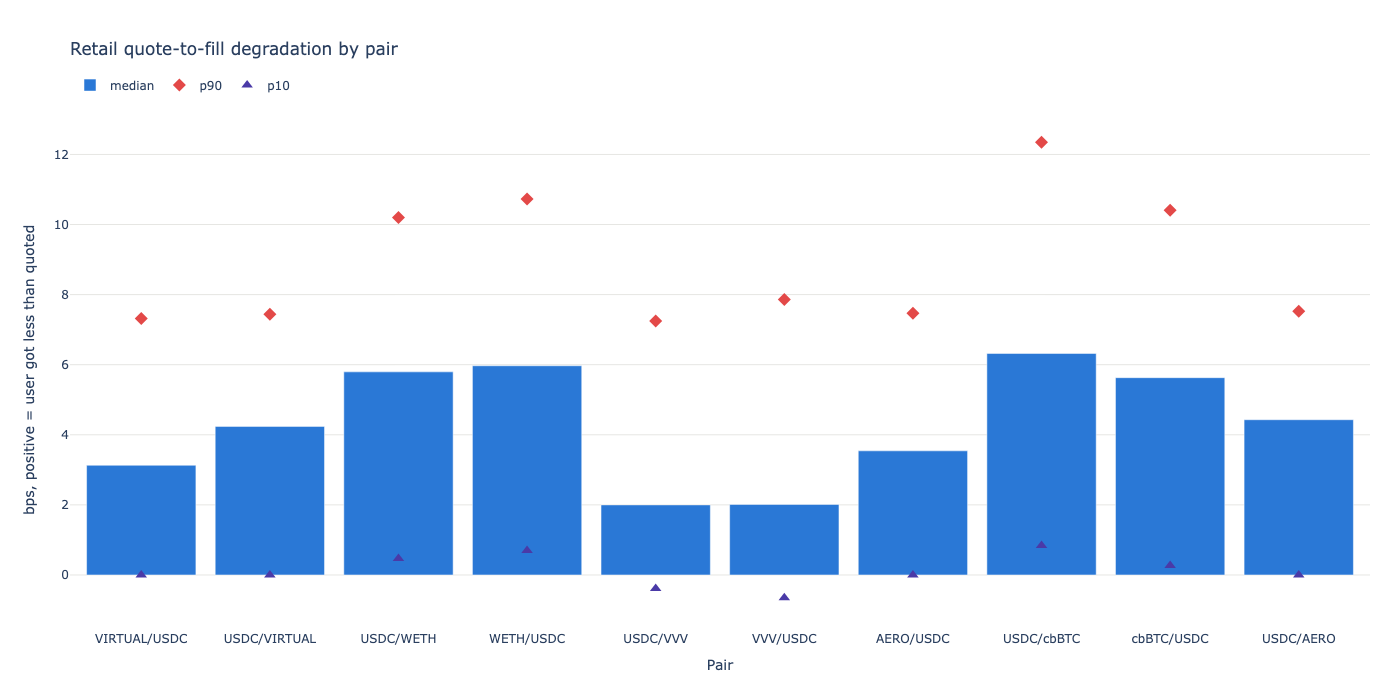

,n,p10,p50,p90,mean
pair,,,,,
VIRTUAL/USDC,"70,608",0.00,3.13,7.32,3.94
USDC/VIRTUAL,"68,995",0.00,4.24,7.44,3.70
USDC/WETH,"48,634",0.47,5.80,10.20,5.62
WETH/USDC,"42,723",0.70,5.97,10.73,6.51
USDC/VVV,"29,364",-0.39,2.00,7.25,2.60
VVV/USDC,"27,490",-0.65,2.01,7.86,3.39
AERO/USDC,"22,804",0.00,3.54,7.47,3.94
USDC/cbBTC,"18,282",0.84,6.32,12.35,9.01
cbBTC/USDC,"16,191",0.27,5.63,10.40,5.49


In [7]:
retail = df[df["flow"] == "retail"]
by_pair = retail.groupby("pair")["quote_to_fill_bps"].agg(n="size", p10=lambda s: s.quantile(0.1), p50="median", p90=lambda s: s.quantile(0.9), mean="mean")
by_pair = by_pair[by_pair["n"] >= 1000].sort_values("n", ascending=False).head(10)

fig = go.Figure()
fig.add_bar(x=by_pair.index, y=by_pair["p50"], name="median", marker_color=COLOURS["retail"])
fig.add_scatter(x=by_pair.index, y=by_pair["p90"], mode="markers", name="p90", marker=dict(color=COLOURS["fill"], size=10, symbol="diamond"))
fig.add_scatter(x=by_pair.index, y=by_pair["p10"], mode="markers", name="p10", marker=dict(color=COLOURS["quote"], size=10, symbol="triangle-up"))
style(fig, "Retail quote-to-fill degradation by pair", "Pair", "bps, positive = user got less than quoted").show()
display(by_pair.style.format({"n": "{:,}", "p10": "{:.2f}", "p50": "{:.2f}", "p90": "{:.2f}", "mean": "{:.2f}"}))

**What this chart shows.** The same quote-to-fill degradation for retail flow, one bar per pair, with the 10th and 90th percentiles marked. Pairs are ordered by trade count and only pairs with at least a thousand retail trades are shown.

**What the result means.** The skim is largest on the deepest markets: WETH/USDC and cbBTC/USDC sit at 5.6 to 6.3 bps, with a 10th percentile of 0.3 to 0.8 bps that looks like a floor. Thinner tokens (VIRTUAL, VVV, AERO) sit at 2 to 4.5 bps. If the degradation were an artefact of illiquid tokens or stale reference prices it would be the other way round.

**What it means for retail users.** Swapping ETH or BTC against USDC, the most common retail trade, is where a Tessera fill costs the most relative to its quote. The pairs where the venue's quote is most likely to beat an AMM pool by a hair, and therefore most likely to win the routing, are also the pairs where the settled price falls furthest short of that quote.

## End-of-block quotes move no more than the market, which hides the mid-block state

- In a normal market the price moves more between blocks (two seconds apart) than inside a block (200 ms Flashblocks)
- 0x reported the inverse for propAMMs, sampling live at Flashblock granularity: five to seven times more movement within the block than across blocks
- Quotes are only comparable at the same trade size, so intra-block movement uses each trade's own quote at the end of the previous block vs the end of its own block, and inter-block movement uses WETH→USDC trades in consecutive blocks whose sizes are within 5% of each other; the reference pool's mid between consecutive blocks shows how much the market itself moved
- With end-of-block snapshots we do **not** see the inversion: Tessera's quote moves about as much as the market does. Both of our snapshots fall in the tight, end-of-block state; the worse mid-block state that retail settles in (see the mechanism section) sits between them and is invisible to historical `eth_call`. Reproducing 0x's measurement needs live Flashblock sampling

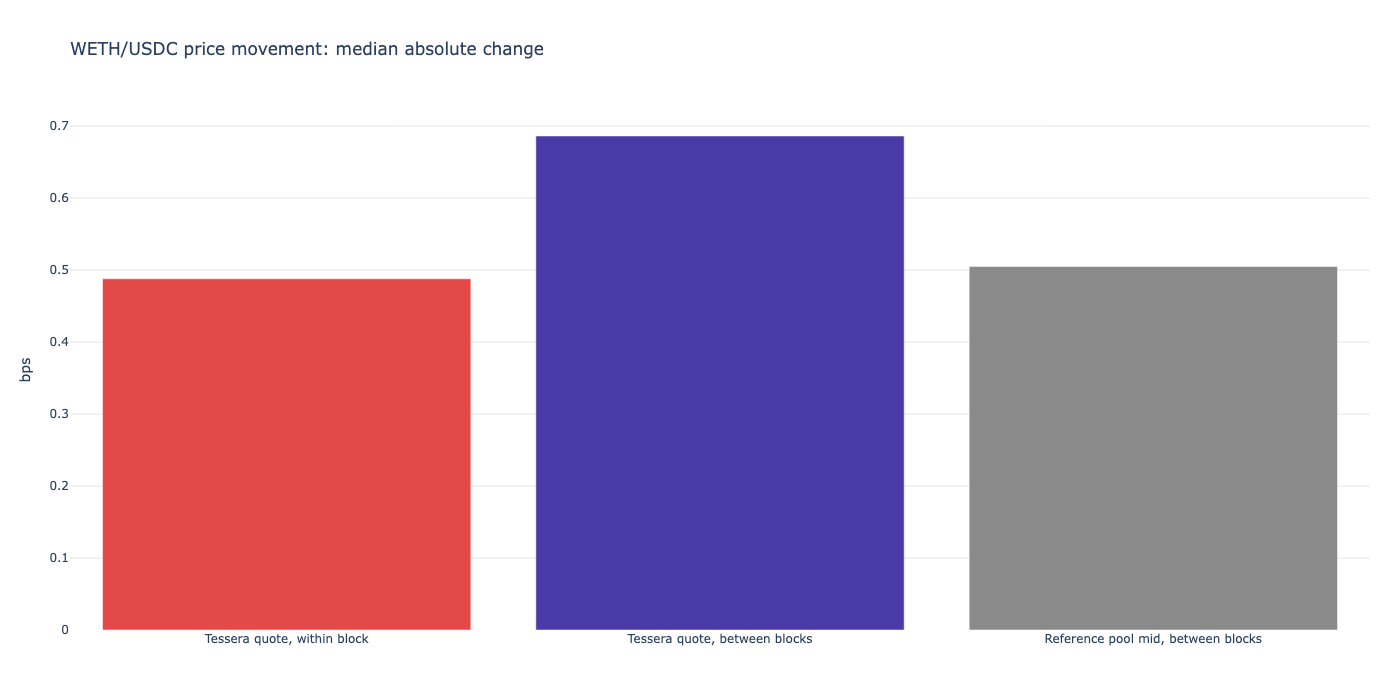

,median |Δ| bps,p90 |Δ| bps,samples
"Tessera quote, within block",0.49,2.17,"105,978.00"
"Tessera quote, between blocks",0.69,3.83,"2,428.00"
"Reference pool mid, between blocks",0.50,2.36,"787,812.00"


In [8]:
weth_sells = df[(df["token_in"] == WETH) & (df["token_out"] == USDC)].dropna(subset=["quote_to_fill_bps", "same_block_quote_to_fill_bps"]).copy()
# Same trade, same size: end of previous block vs end of own block
weth_sells["intra_bps"] = ((1 - weth_sells["same_block_quote_to_fill_bps"] / 1e4) / (1 - weth_sells["quote_to_fill_bps"] / 1e4) - 1) * 1e4
intra = weth_sells["intra_bps"].replace([np.inf, -np.inf], np.nan).dropna()
intra = intra[intra.abs() < 100]

# Consecutive blocks, sizes within 5%: quoted price per WETH at end of previous block
s1 = weth_sells.sort_values(["block_number", "amount_in_decimal"]).drop_duplicates("block_number")
s1["quote_px"] = (1 - s1["quote_to_fill_bps"] / 1e4) * s1["amount_out_decimal"] / s1["amount_in_decimal"]
nxt = s1.shift(-1)
consecutive = (nxt["block_number"] == s1["block_number"] + 1) & ((nxt["amount_in_decimal"] / s1["amount_in_decimal"] - 1).abs() < 0.05)
inter = ((nxt["quote_px"] / s1["quote_px"] - 1) * 1e4)[consecutive].dropna()
inter = inter[inter.abs() < 100]

market = con.execute("""
    WITH p AS (
        SELECT block_number, price, lag(price) OVER (ORDER BY block_number) AS prev_price, lag(block_number) OVER (ORDER BY block_number) AS prev_block
        FROM benchmark_block_prices b JOIN benchmark_pools p ON p.pool = b.pool
        WHERE p.token0 = ? AND p.token1 = ? AND b.block_number >= ?
    )
    SELECT (price / prev_price - 1) * 1e4 AS bps FROM p WHERE block_number = prev_block + 1
""", [WETH, USDC, WINDOW_START_BLOCK]).df()["bps"].dropna()

labels = ["Tessera quote, within block", "Tessera quote, between blocks", "Reference pool mid, between blocks"]
values = [intra.abs().median(), inter.abs().median(), market.abs().median()]
fig = go.Figure(go.Bar(x=labels, y=values, marker_color=[COLOURS["fill"], COLOURS["quote"], COLOURS["unlabelled"]]))
style(fig, "WETH/USDC price movement: median absolute change", "", "bps", legend=False).show()
display(pd.DataFrame({"median |Δ| bps": values, "p90 |Δ| bps": [intra.abs().quantile(0.9), inter.abs().quantile(0.9), market.abs().quantile(0.9)], "samples": [len(intra), len(inter), len(market)]}, index=labels).style.format("{:,.2f}"))

**What this chart shows.** How much Tessera's WETH/USDC quote moves within a block (end of the previous block to end of the trade's own block, same trade size) compared with how much it moves between consecutive blocks (trades in adjacent blocks with sizes within 5 %), and how much the reference pool's mid moves between consecutive blocks.

**What the result means.** With end-of-block snapshots the three medians are close: 0.49 bps within a block, 0.69 bps between blocks, 0.50 bps for the market itself. This does not reproduce 0x's five-to-sevenfold inversion, and we do not claim it: both of our snapshots fall in the tight end-of-block state, and the worse mid-block state that retail settles in (see the mechanism section) sits between them where a historical `eth_call` cannot look. Reproducing 0x's measurement needs live Flashblock sampling.

**What it means for retail users.** The degradation is not visible in end-of-block prices, which is also why it is invisible to any monitoring that samples the venue once per block. A user, an aggregator or an analyst comparing Tessera's quote at block boundaries would conclude the venue tracks the market closely. The gap opens and closes inside the block, and only the fills themselves record it.

## Retail fills sit five to seven bps below fair almost every day

- Is the skim episodic or steady? Six-hour medians over the window for the majors with a fresh reference price (buckets with fewer than 50 trades dropped)
- Retail fills sit five to seven bps below fair through almost the whole window. The exception is a short spell around 23–27 July when retail was filled within about one bp of fair; the venue can evidently fill retail at its quote when it chooses to
- Bot fills (shown only where a bucket has at least 50 bot trades) are absent before late July, appear in force from 17 August, and sit slightly above fair

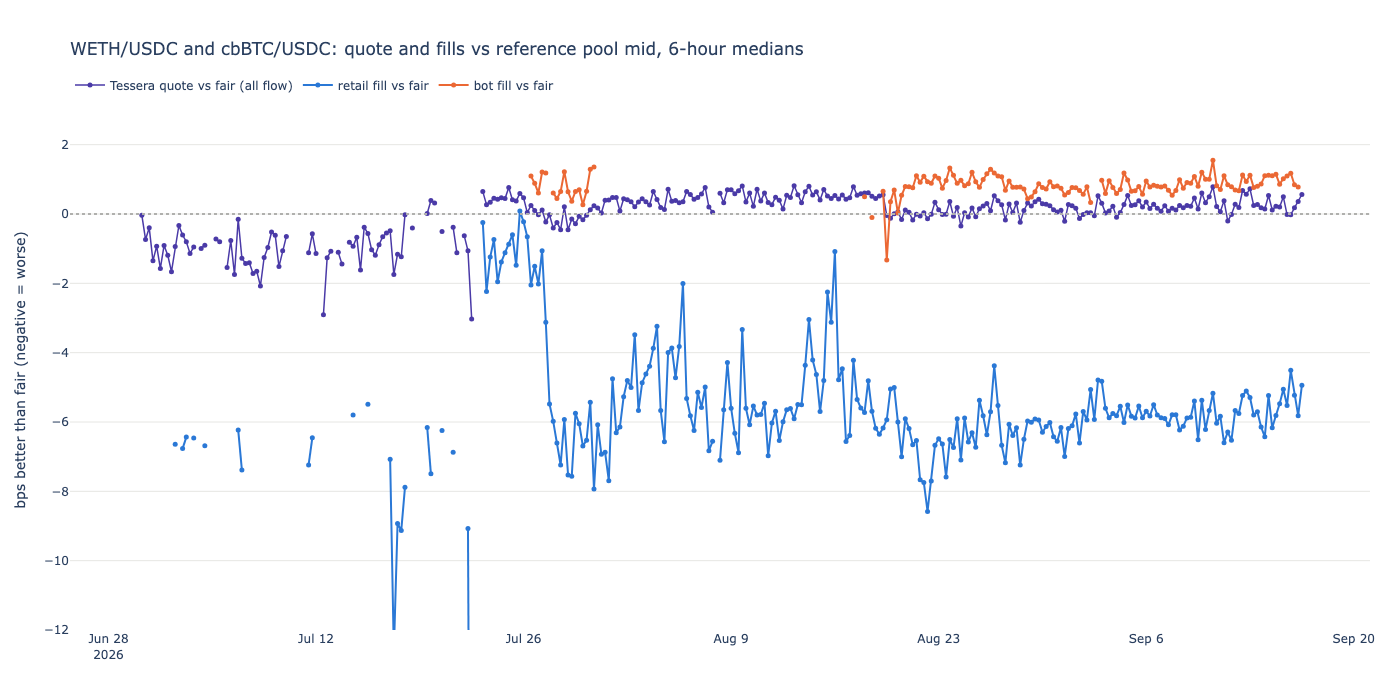

In [9]:
fresh = df[df["pair"].isin(["WETH/USDC", "USDC/WETH", "cbBTC/USDC", "USDC/cbBTC"]) & (df["benchmark_age_blocks"] <= 3)]
fresh = fresh.assign(bucket=fresh["timestamp"].dt.floor("6h"))

grid = pd.date_range(fresh["bucket"].min(), fresh["bucket"].max(), freq="6h")

def bucket_median(frame: pd.DataFrame, column: str, minimum: int = 50) -> pd.Series:
    """Median per 6-hour bucket on the full grid; buckets with too few trades become gaps so lines break instead of bridging them."""
    g = frame.groupby("bucket")[column]
    return g.median()[g.size() >= minimum].reindex(grid)

hourly_quote = bucket_median(fresh, "quote_vs_benchmark_bps")
hourly_retail = bucket_median(fresh[fresh["flow"] == "retail"], "fill_vs_benchmark_bps")
hourly_bot = bucket_median(fresh[fresh["flow"] == "bot"], "fill_vs_benchmark_bps")

fig = go.Figure()
fig.add_scatter(x=hourly_quote.index, y=hourly_quote, mode="lines+markers", name="Tessera quote vs fair (all flow)", line=dict(color=COLOURS["quote"], width=1.5), marker=dict(size=5))
fig.add_scatter(x=hourly_retail.index, y=-hourly_retail, mode="lines+markers", name="retail fill vs fair", line=dict(color=COLOURS["retail"], width=2), marker=dict(size=5))
fig.add_scatter(x=hourly_bot.index, y=-hourly_bot, mode="lines+markers", name="bot fill vs fair", line=dict(color=COLOURS["bot"], width=2), marker=dict(size=5))
fig.add_hline(y=0, line=dict(color="#b0b0ad", dash="dot"))
style(fig, "WETH/USDC and cbBTC/USDC: quote and fills vs reference pool mid, 6-hour medians", "", "bps better than fair (negative = worse)")
fig.update_yaxes(range=[-12, 3])
fig.show()

**What this chart shows.** Six-hour medians over the window, for WETH/USDC and cbBTC/USDC with a fresh reference price: Tessera's quote against the reference pool mid, retail fills against the mid, and bot fills against the mid. Positive is better than fair. Buckets with fewer than 50 trades are omitted.

**What the result means.** Tessera's quote tracks the pool mid closely throughout (within about half a basis point). Retail fills sit five to seven bps below the mid almost every six hours from the start of July to mid-September; the one exception is 23 to 27 July, when retail was filled within about a basis point of fair. Bot fills are absent before late July, appear in force from 17 August, and sit slightly above fair. The five-day exception matters: the venue evidently can settle retail at its quote, and the regime section below shows what was different during those days.

**What it means for retail users.** This is not a bad week or a volatile session. A retail user trading the majors on Tessera on any given day of the window, with the sole exception of five days in late July, received a price about six bps worse than the pool mid the aggregator was comparing against. The consistency is the point: it is a standing configuration of the venue, not a reaction to market conditions.

# Question 2: who pays?

## Which aggregator routed the trade decides whether the user pays

- The same venue, the same blocks, but very different outcomes depending on which aggregator routed the trade
- KyberSwap and 0x flow gets fills close to the quote; OKX, 1inch, Paraswap, LI.FI and Binance Wallet flow pays the full skim
- 0x publicly monitors fill quality and cuts sources that misbehave; the numbers suggest that pressure works

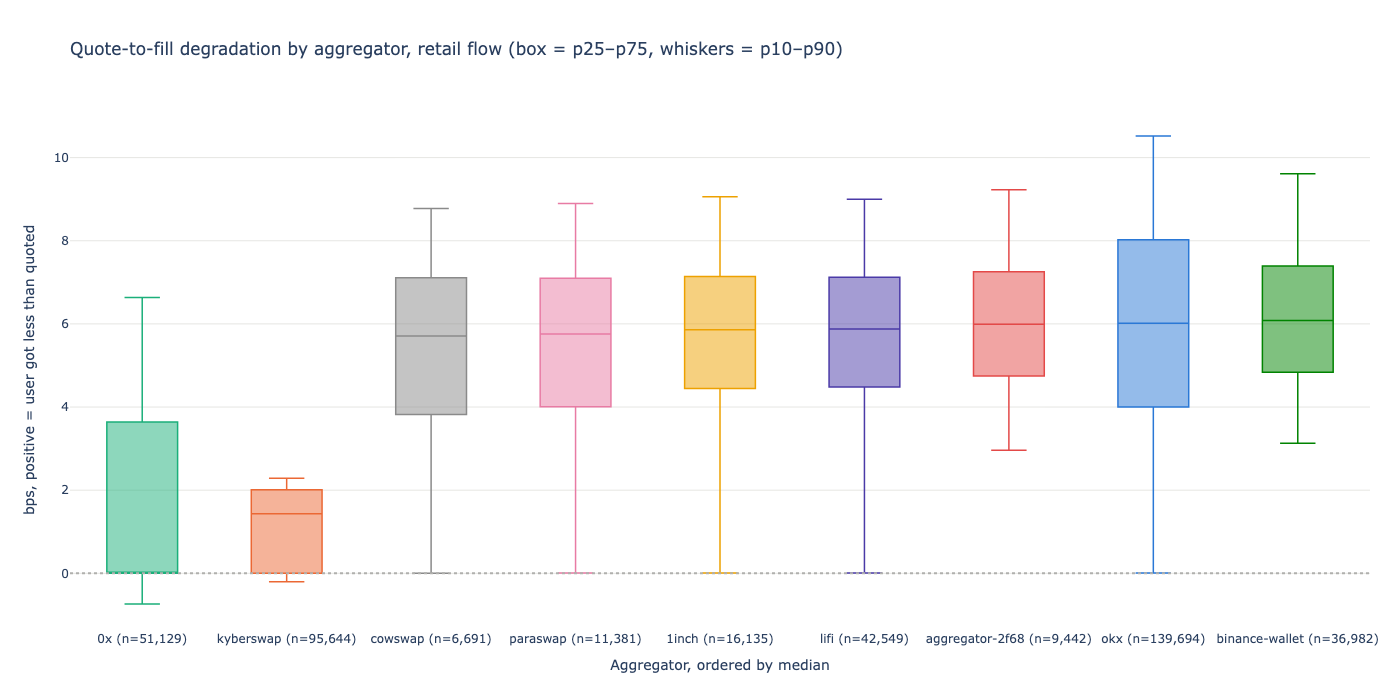

,n,p10,p50,p90,mean
aggregator,,,,,
0x,"51,129",-0.74,0.01,6.63,1.49
kyberswap,"95,644",-0.20,1.43,2.29,1.49
cowswap,"6,691",0.00,5.71,8.77,5.26
paraswap,"11,381",0.01,5.76,8.90,5.42
1inch,"16,135",0.01,5.86,9.06,5.82
lifi,"42,549",0.01,5.88,9.00,6.84
aggregator-2f68,"9,442",2.96,5.99,9.23,5.86
okx,"139,694",0.01,6.01,10.52,6.50
binance-wallet,"36,982",3.13,6.08,9.61,6.09


In [10]:
agg = df[df["flow"] == "retail"].groupby("aggregator")["quote_to_fill_bps"].agg(
    n="size", p10=lambda s: s.quantile(0.1), p25=lambda s: s.quantile(0.25), p50="median", p75=lambda s: s.quantile(0.75), p90=lambda s: s.quantile(0.9), mean="mean"
)
agg = agg[agg["n"] >= 500].sort_values("p50")

fig = go.Figure()
for name, row in agg.iterrows():
    label = f"{name} (n={int(row['n']):,})"
    fig.add_box(
        name=label, x=[label],
        q1=[row["p25"]], median=[row["p50"]], q3=[row["p75"]], lowerfence=[row["p10"]], upperfence=[row["p90"]],
        marker_color=AGGREGATOR_COLOURS.get(name, "#8a8a8a"), line_width=1.5,
    )
fig.add_hline(y=0, line=dict(color="#b0b0ad", dash="dot"))
style(fig, "Quote-to-fill degradation by aggregator, retail flow (box = p25–p75, whiskers = p10–p90)", "Aggregator, ordered by median", "bps, positive = user got less than quoted", legend=False).show()
display(agg[["n", "p10", "p50", "p90", "mean"]].style.format({"n": "{:,}", "p10": "{:.2f}", "p50": "{:.2f}", "p90": "{:.2f}", "mean": "{:.2f}"}))

**What this chart shows.** Quote-to-fill degradation for retail flow, one box per aggregator router identified on the transaction's call path, ordered by median. The box spans the 25th to 75th percentile and the whiskers the 10th to 90th.

**What the result means.** Two aggregators get their users filled close to the quote: 0x (median 0.0 bps) and KyberSwap (1.4 bps). Every other aggregator sits in a narrow band around 6 bps: CoW 5.7, Paraswap 5.8, 1inch 5.9, LI.FI 5.9, the unnamed aggregator 6.0, OKX 6.0, Binance Wallet 6.1. The venue is the same and the blocks are the same; what differs is how each aggregator's transactions land in the block and, in 0x's case, whether it still routes to Tessera at all (its Tessera volume on the majors fell away in early July). Question 3 checks whether these differences are a pair-mix effect: KyberSwap's advantage holds within every pair, 0x's holds only on the thin tokens.

**What it means for retail users.** Which app a user swaps through determines whether they pay this. A user routed through OKX, 1inch, Paraswap, LI.FI or Binance Wallet pays the full skim on almost every Tessera fill; a user on 0x or KyberSwap largely does not. Users have no way of seeing this in the quote, because the quotes are identical: it only shows in the fills. Aggregators that measure their own fill quality against the quote they routed on can see it immediately, and the two that do best are the two that have said publicly that they do.

## Front-ends inherit their aggregator's fill quality

- Aggregator routers often carry a front-end identifier: KyberSwap's `clientData` names the integrating app, ERC-4337 flow identifies smart-wallet users (Coinbase Smart Wallet)
- This puts retail-facing brand names on the numbers

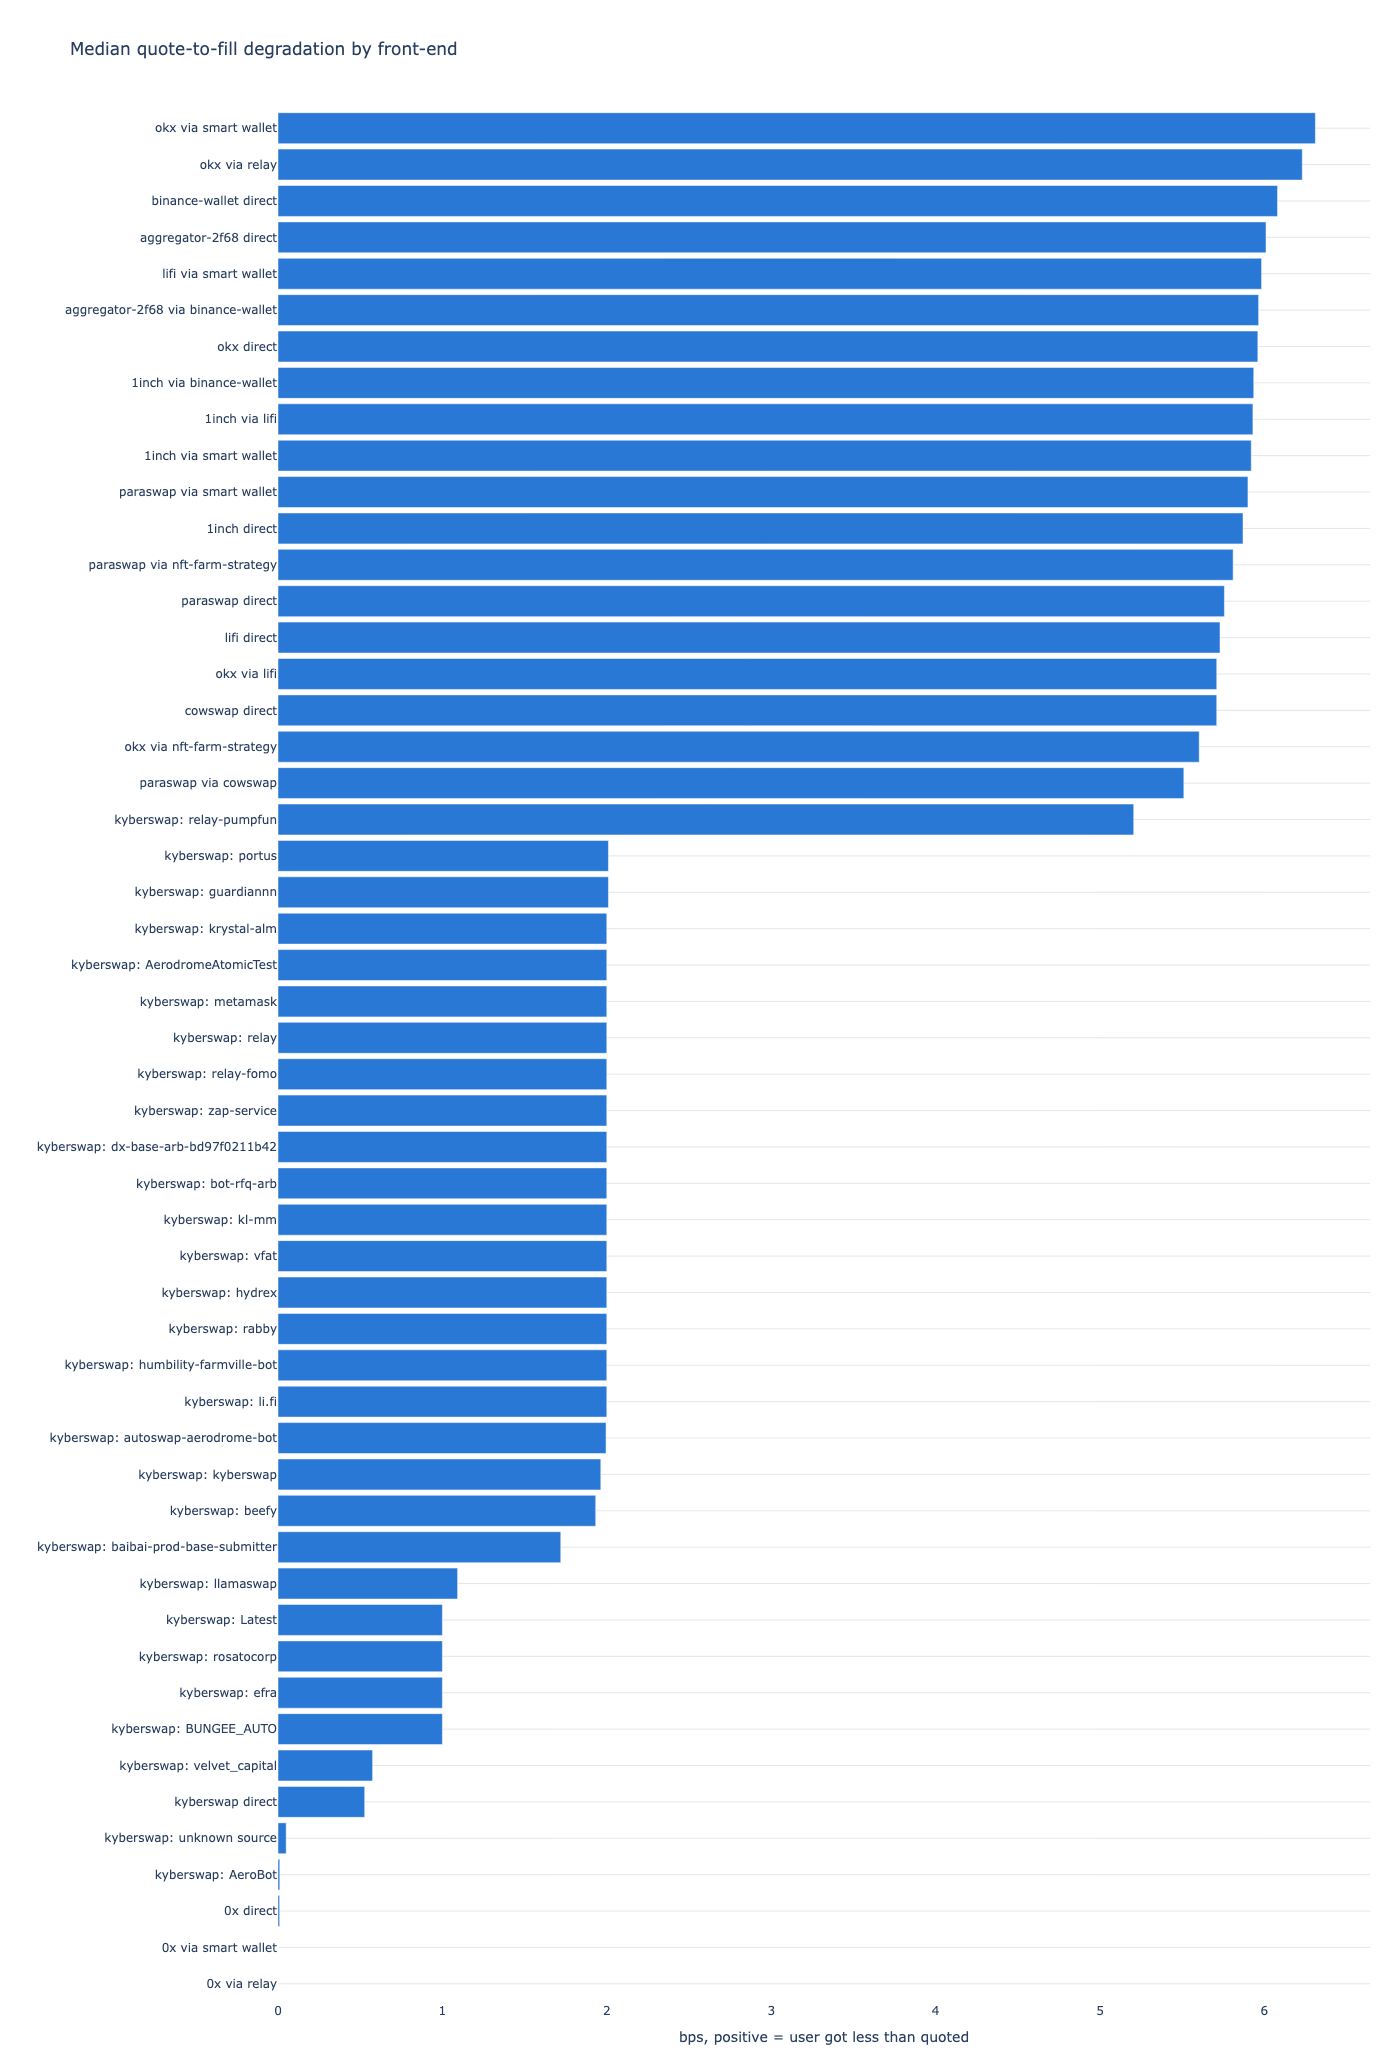

,n,p50,p90,notional_usd
frontend_label,,,,
okx via smart wallet,"8,435",6.31,11.77,"$1,006,511"
okx via relay,"17,235",6.23,10.23,"$4,401,344"
binance-wallet direct,"36,982",6.08,9.61,"$18,115,360"
aggregator-2f68 direct,"4,710",6.01,9.51,"$2,549,801"
lifi via smart wallet,"23,931",5.98,9.56,"$4,309,590"
aggregator-2f68 via binance-wallet,"4,587",5.96,8.81,"$1,458,569"
okx direct,"108,978",5.96,10.54,"$23,918,054"
1inch via binance-wallet,738,5.94,9.50,"$613,161"
1inch via lifi,877,5.93,8.22,"$589,151"


In [11]:
import json

def frontend_label(row):
    if isinstance(row["client_data"], str) and row["client_data"].startswith("{"):
        try:
            return f"{row['aggregator']}: {json.loads(row['client_data']).get('Source') or 'unknown source'}"
        except json.JSONDecodeError:
            pass
    if row["wallet_kind"] == "erc4337":
        return f"{row['aggregator']} via smart wallet"
    if isinstance(row["frontend"], str) and row["frontend"] != row["aggregator"]:
        return f"{row['aggregator']} via {row['frontend']}"
    return f"{row['aggregator']} direct"

retail = df[df["flow"] == "retail"].copy()
retail["frontend_label"] = retail.apply(frontend_label, axis=1)
fe = retail.groupby("frontend_label").agg(n=("tx_hash", "size"), p50=("quote_to_fill_bps", "median"), p90=("quote_to_fill_bps", lambda s: s.quantile(0.9)), notional_usd=("notional_usd", "sum"))
fe = fe[fe["n"] >= 300].sort_values("p50", ascending=True)

fig = go.Figure(go.Bar(x=fe["p50"], y=fe.index, orientation="h", marker_color=COLOURS["retail"], name="median"))
style(fig, "Median quote-to-fill degradation by front-end", "bps, positive = user got less than quoted", "", legend=False)
fig.update_yaxes(tickmode="array", tickvals=list(fe.index), automargin=True)
fig.show(height=max(700, 36 * len(fe) + 200))
display(fe.sort_values("p50", ascending=False).fillna(0).style.format({"n": "{:,}", "p50": "{:.2f}", "p90": "{:.2f}", "notional_usd": "${:,.0f}"}))

**What this chart shows.** The same degradation broken down by the front-end or wallet layer, where the router calldata carries one: KyberSwap's `clientData` names the integrating app, ERC-4337 flow identifies smart-wallet users, and wrapper contracts (Relay, LI.FI) sit in front of another aggregator. Only front-ends with at least 300 trades are shown.

**What the result means.** The ordering follows the aggregator underneath, not the brand on top. Every KyberSwap integration, whether Kraken's, Rabby's, Krystal's or KyberSwap's own app, sits at one to two bps; every OKX, 1inch, Paraswap, LI.FI and Binance Wallet path sits at about six, including smart-wallet users routed through them. Wrapping an aggregator in another product (OKX via Relay, 1inch via LI.FI) changes nothing.

**What it means for retail users.** A user cannot fix this by choosing a nicer wallet or a better-known app; the fill quality is inherited from the routing engine the app licenses. The practical consequence is that the "best price" shown in the app is not the price to compare across apps, because two apps showing the same Tessera quote will deliver different fills. The comparison that matters is the one this chart makes, and users cannot make it themselves.

## Slippage tolerance does not limit the skim

- From the aggregator router calldata we decoded the minimum output each user accepted; relative to Tessera's quote this is their slippage tolerance in bps
- Tolerances cluster at front-end defaults of 50, 100 and 200 bps, twenty to forty times the median skim, so the fill never reverts and nothing looks wrong to the user
- The degradation taken does not grow with the tolerance given: the venue takes a fixed few bps, not "whatever the user allowed"
- Only trades where the router order maps onto this single Tessera leg are shown (multi-hop routes express the bound in a different token)

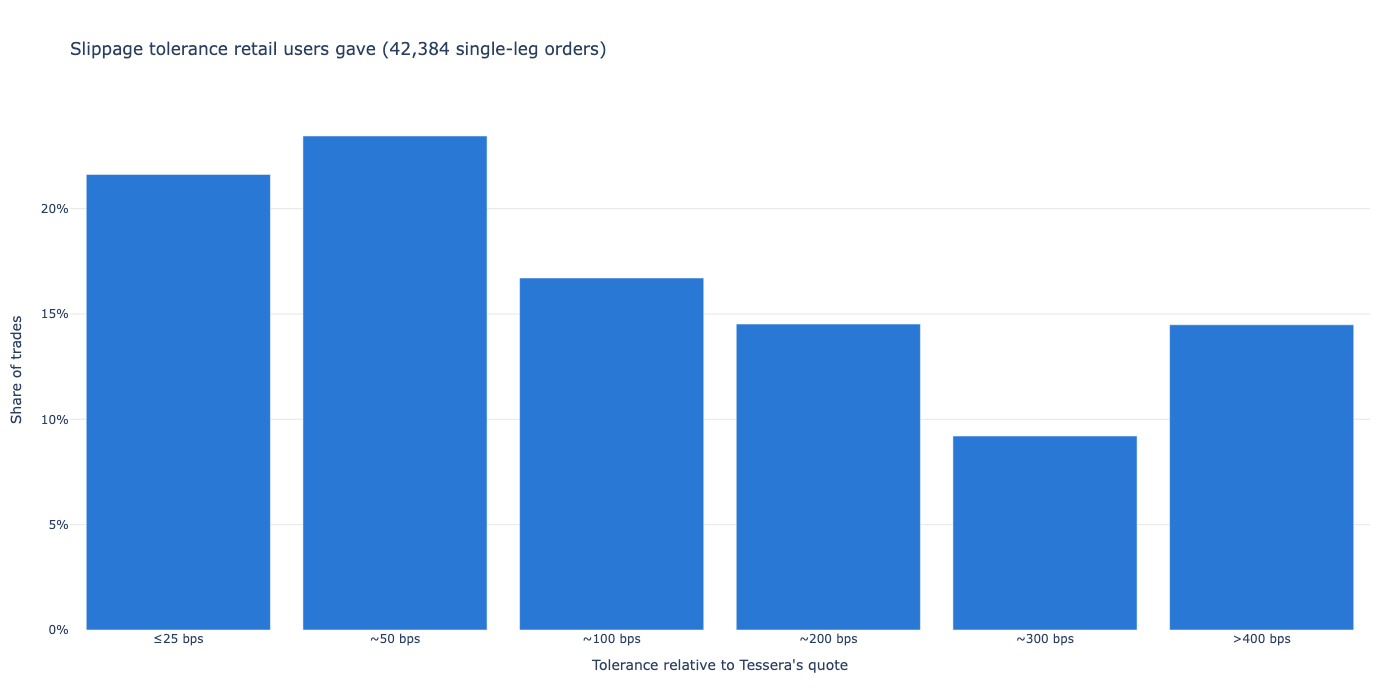

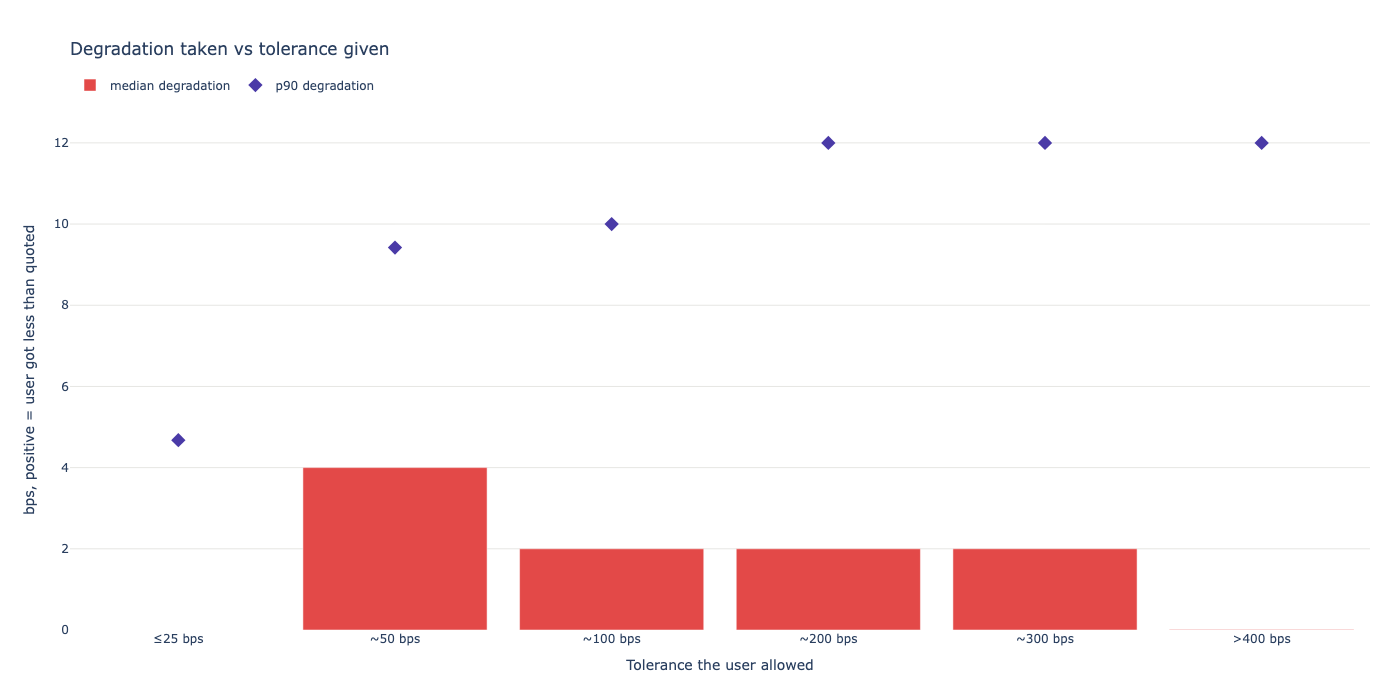

Median tolerance 99 bps, median degradation 1.1 bps, median share of tolerance consumed 0.8%, fills within 1 bps of the user's bound: 1.44%


,n,degradation_p50,degradation_p90,consumed_p50,share_of_trades
tolerance_bucket,,,,,
≤25 bps,"9,165",0.00,4.68,0.0%,22%
~50 bps,"9,939",4.00,9.42,8.0%,23%
~100 bps,"7,082",2.00,10.00,1.9%,17%
~200 bps,"6,155",2.00,12.00,1.0%,15%
~300 bps,"3,902",2.00,12.00,0.7%,9%
>400 bps,"6,141",0.01,12.00,0.0%,14%


In [12]:
bound = df[(df["flow"] == "retail") & df["order_matches_leg"].fillna(False) & df["user_slippage_bps"].between(0, 1000)].copy()
tol_bins = [0, 25, 75, 150, 250, 400, 1000]
tol_labels = ["≤25 bps", "~50 bps", "~100 bps", "~200 bps", "~300 bps", ">400 bps"]
bound["tolerance_bucket"] = pd.cut(bound["user_slippage_bps"], bins=tol_bins, labels=tol_labels, include_lowest=True)
tol = bound.groupby("tolerance_bucket", observed=True).agg(n=("tx_hash", "size"), degradation_p50=("quote_to_fill_bps", "median"), degradation_p90=("quote_to_fill_bps", lambda s: s.quantile(0.9)), consumed_p50=("user_slippage_consumed_fraction", "median"))
tol["share_of_trades"] = tol["n"] / tol["n"].sum()

fig = go.Figure(go.Bar(x=tol.index.astype(str), y=tol["share_of_trades"], marker_color=COLOURS["retail"], name="share of trades"))
style(fig, f"Slippage tolerance retail users gave ({len(bound):,} single-leg orders)", "Tolerance relative to Tessera's quote", "Share of trades", legend=False)
fig.update_yaxes(tickformat=".0%")
fig.show()

fig = go.Figure()
fig.add_bar(x=tol.index.astype(str), y=tol["degradation_p50"], name="median degradation", marker_color=COLOURS["fill"])
fig.add_scatter(x=tol.index.astype(str), y=tol["degradation_p90"], mode="markers", name="p90 degradation", marker=dict(color=COLOURS["quote"], size=11, symbol="diamond"))
style(fig, "Degradation taken vs tolerance given", "Tolerance the user allowed", "bps, positive = user got less than quoted").show()

at_bound = (bound["user_headroom_bps"] < 1).mean()
print(f"Median tolerance {bound['user_slippage_bps'].median():.0f} bps, median degradation {bound['quote_to_fill_bps'].median():.1f} bps, "
      f"median share of tolerance consumed {bound['user_slippage_consumed_fraction'].clip(-0.5, 1.5).median():.1%}, fills within 1 bps of the user's bound: {at_bound:.2%}")
display(tol.style.format({"n": "{:,}", "degradation_p50": "{:.2f}", "degradation_p90": "{:.2f}", "consumed_p50": "{:.1%}", "share_of_trades": "{:.0%}"}))

**What these charts show.** From the aggregator router's calldata we decoded the minimum output each user accepted; relative to Tessera's quote that is the user's slippage tolerance in basis points. The first chart is the distribution of tolerances, the second is the degradation actually taken within each tolerance bucket. Only orders where the router's order maps onto this single Tessera leg are included, so multi-hop routes are excluded.

**What the result means.** Tolerances cluster at front-end defaults: 50, 100, 200 and 300 bps, with a median of 99 bps. The degradation taken does not grow with the tolerance given; it is about two to four bps whether the user allowed 50 bps or 300. The median fill consumes under one percent of the tolerance and only 1.4 % of fills land within a basis point of the user's bound. The venue takes a fixed few bps, not "whatever the user allowed", and it stays far enough inside the bound that the transaction never reverts.

**What it means for retail users.** Tightening the slippage setting from 1 % to 0.1 % would not remove a four-bp skim, because four bps is inside either. A tolerance of 100 bps, which is what most apps set by default, gives the venue twenty-five times the room it uses. The setting protects the user against a large price move between quote and settlement; it offers no protection against a small, deliberate one, which is exactly what this is. Users who see their trades succeed inside their tolerance reasonably conclude the fill was fine.

## Small trades are hit hardest in bps, mid-size trades in dollars

- Is the skim a flat fee-like amount or does it scale with size like adverse selection would?
- Median and 90th percentile quote-to-fill bps by USD notional bucket, retail flow on pairs with a USDC leg
- The buckets are not like-for-like: KyberSwap and 0x (the low-degradation aggregators) route most of the $1k–100k flow, which pulls the middle buckets down; the per-aggregator chart above is the cleaner comparison

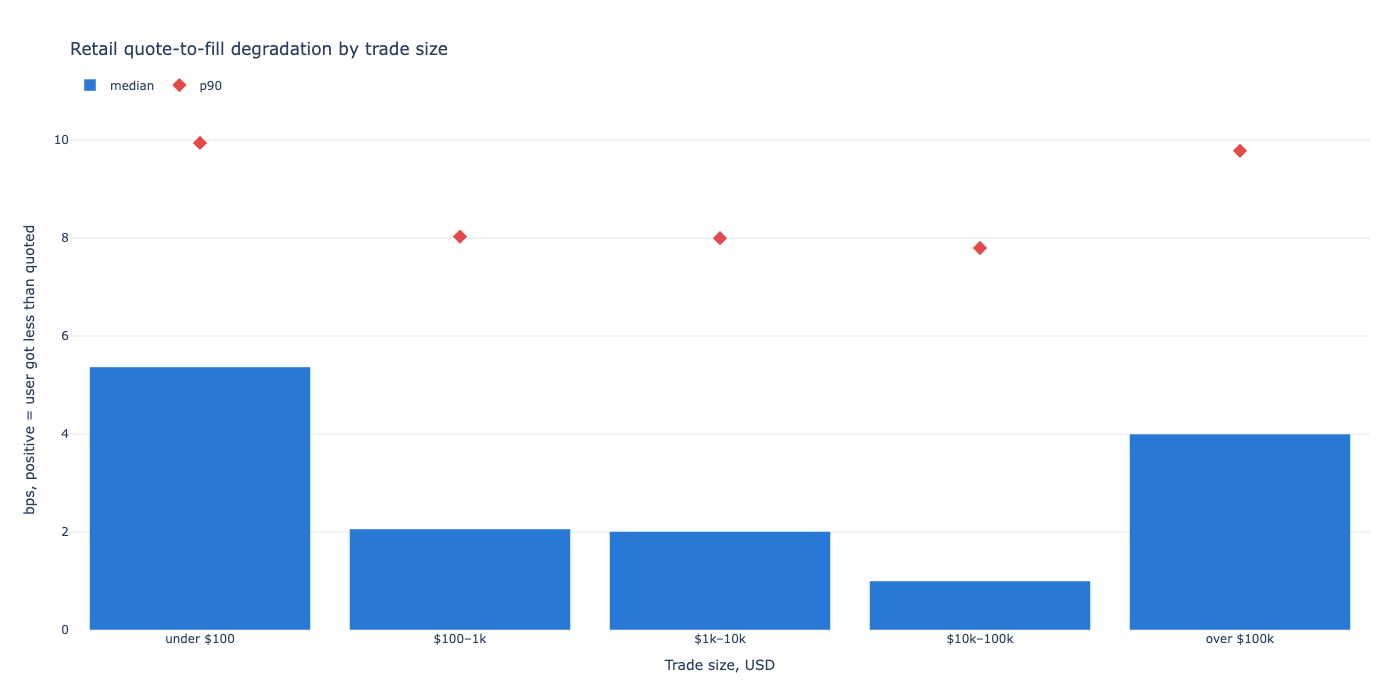

,n,p50,p90,mean,notional_usd,extracted_usd
size_bucket,,,,,,
under $100,"229,598",5.37,9.94,5.62,"$6,204,825","$2,729"
$100–1k,"130,250",2.06,8.03,3.37,"$47,615,632","$14,930"
$1k–10k,"45,297",2.01,8.00,3.21,"$129,184,092","$41,093"
$10k–100k,"4,323",1.00,7.80,2.74,"$92,177,420","$27,755"
over $100k,155,4.00,9.78,4.18,"$24,217,799","$10,361"


In [13]:
bins = [0, 100, 1_000, 10_000, 100_000, np.inf]
labels = ["under $100", "$100–1k", "$1k–10k", "$10k–100k", "over $100k"]
retail = df[(df["flow"] == "retail") & df["notional_usd"].notna()].copy()
retail["size_bucket"] = pd.cut(retail["notional_usd"], bins=bins, labels=labels)
size = retail.groupby("size_bucket", observed=True)["quote_to_fill_bps"].agg(n="size", p50="median", p90=lambda s: s.quantile(0.9), mean="mean")
size["notional_usd"] = retail.groupby("size_bucket", observed=True)["notional_usd"].sum()
size["extracted_usd"] = retail.groupby("size_bucket", observed=True)["extracted_usd"].sum()

fig = go.Figure()
fig.add_bar(x=size.index.astype(str), y=size["p50"], name="median", marker_color=COLOURS["retail"])
fig.add_scatter(x=size.index.astype(str), y=size["p90"], mode="markers", name="p90", marker=dict(color=COLOURS["fill"], size=11, symbol="diamond"))
style(fig, "Retail quote-to-fill degradation by trade size", "Trade size, USD", "bps, positive = user got less than quoted").show()
display(size.style.format({"n": "{:,}", "p50": "{:.2f}", "p90": "{:.2f}", "mean": "{:.2f}", "notional_usd": "${:,.0f}", "extracted_usd": "${:,.0f}"}))

**What this chart shows.** Retail quote-to-fill degradation by trade size in dollars, median and 90th percentile, with the number of trades, volume and dollars extracted per bucket in the table.

**What the result means.** The median degradation is highest on the smallest trades (5.4 bps under $100) and lowest in the $10k to $100k range (1.0 bps), then rises again above $100k (4.0 bps, on 155 trades). The buckets are not like-for-like: KyberSwap and 0x, the two low-degradation aggregators, route most of the $1k to $100k flow, which pulls the middle buckets down. In dollars, most of the extraction comes from the $1k to $100k range simply because that is where the volume is ($41k and $28k of the $97k total).

**What it means for retail users.** Small trades are hit hardest in percentage terms and are the least likely to be noticed: on a $50 swap, 5 bps is a quarter of a cent. Large trades are hit hardest in dollars. The pattern is consistent with a fixed per-fill adjustment rather than a size-dependent price impact, which is what a market maker protecting itself against large informed trades would apply; the trades that would carry information (the large ones) are not the ones being charged the most.

# Question 3: are they trading the same pairs?

## Bots and retail trade the same markets, in very different proportions

- A bot-versus-retail gap could in principle be a composition effect: if bots only traded WETH/USDC and retail only traded thin tokens, the two groups would never meet on the same pair and their fills would not be comparable
- Here we show each flow type's mix of markets (both directions of a pair combined), as a share of that flow's trades and of its USDC volume

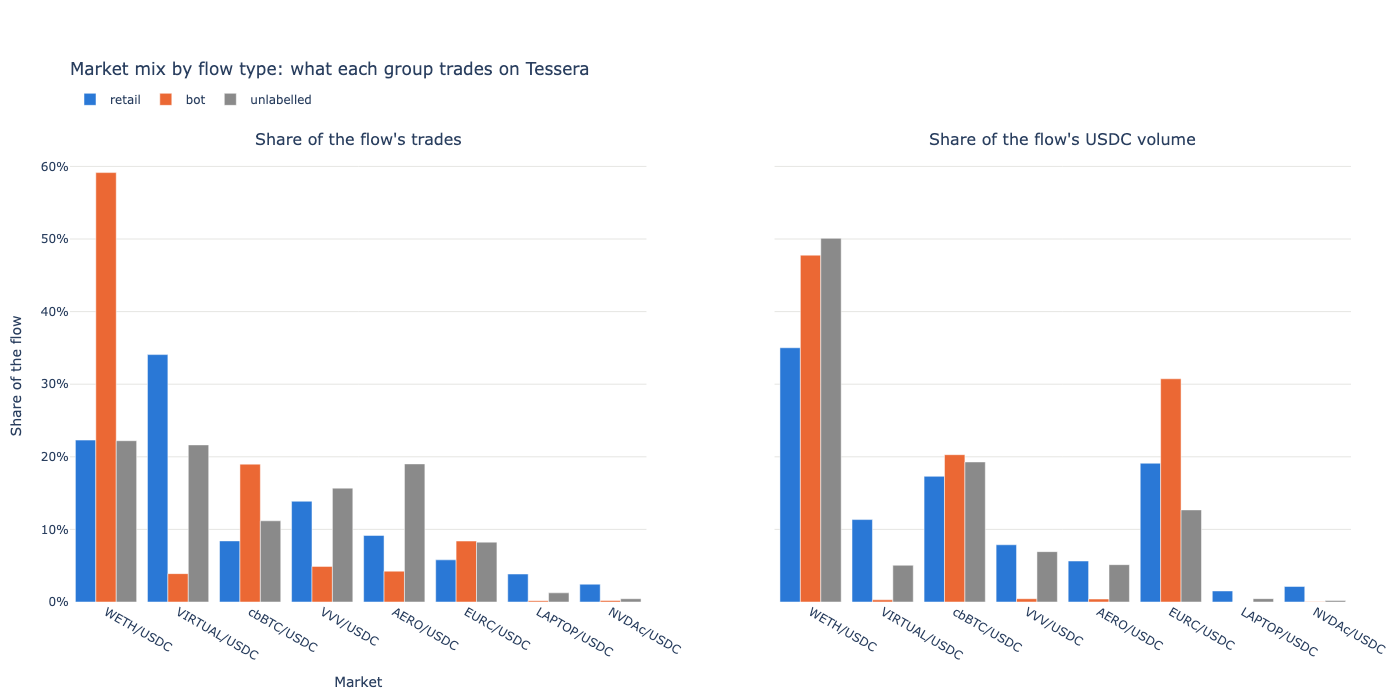

,overlap of trade mix,overlap of volume mix
retail vs bot,50%,73%
retail vs unlabelled,83%,83%


In [14]:
other_symbol = np.where(df["symbol_in"] == "USDC", df["symbol_out"], df["symbol_in"])
has_usdc_leg = (df["symbol_in"] == "USDC") | (df["symbol_out"] == "USDC")
df["market"] = np.where(has_usdc_leg, other_symbol + "/USDC", np.where(df["symbol_in"] < df["symbol_out"], df["symbol_in"] + "/" + df["symbol_out"], df["symbol_out"] + "/" + df["symbol_in"]))

mix_trades = df.pivot_table(index="market", columns="flow", values="tx_hash", aggfunc="size", fill_value=0)
mix_trades = mix_trades / mix_trades.sum()
mix_volume = df.pivot_table(index="market", columns="flow", values="notional_usd", aggfunc="sum", fill_value=0)
mix_volume = mix_volume / mix_volume.sum()
market_order = list(mix_trades.sum(axis=1).sort_values(ascending=False).index[:8])

fig = make_subplots(rows=1, cols=2, shared_yaxes=True, subplot_titles=["Share of the flow's trades", "Share of the flow's USDC volume"])
for flow in FLOW_ORDER:
    fig.add_bar(x=market_order, y=mix_trades.loc[market_order, flow], name=flow, marker_color=COLOURS[flow], row=1, col=1)
    fig.add_bar(x=market_order, y=mix_volume.loc[market_order, flow], name=flow, marker_color=COLOURS[flow], showlegend=False, row=1, col=2)
fig.update_layout(barmode="group")
style(fig, "Market mix by flow type: what each group trades on Tessera", "Market", "Share of the flow")
fig.update_layout(legend=dict(y=1.08), margin=dict(t=150))
fig.update_yaxes(tickformat=".0%")
fig.show()

overlap = pd.DataFrame({
    "overlap of trade mix": [np.minimum(mix_trades["retail"], mix_trades[f]).sum() for f in ["bot", "unlabelled"]],
    "overlap of volume mix": [np.minimum(mix_volume["retail"], mix_volume[f]).sum() for f in ["bot", "unlabelled"]],
}, index=["retail vs bot", "retail vs unlabelled"])
mix_table = pd.concat({"share of trades": mix_trades.loc[market_order], "share of USDC volume": mix_volume.loc[market_order]}, axis=1)
display(mix_table.style.format("{:.1%}"))
display(overlap.style.format("{:.0%}"))

**What this chart shows.** For retail, bot and unlabelled flow separately, the share of that group's trades (left) and of its USDC volume (right) that went to each market, with both directions of a pair combined. The second table is the overlap between two groups' mixes, the sum over markets of the smaller of the two shares: 100 % means identical mixes, 0 % means no market in common.

**What the result means.** The two groups trade the same handful of markets in very different proportions. Bots put 59 % of their trades and 48 % of their volume into WETH/USDC, with cbBTC/USDC and EURC/USDC making up most of the rest; they barely touch VIRTUAL, VVV or AERO. Retail's largest market by trade count is VIRTUAL/USDC (34 % of trades, 11 % of volume), and only 22 % of its trades are WETH/USDC, though by volume WETH/USDC is still its largest market at 35 %. The overlap is 50 % by trades and 73 % by volume. The unlabelled flow's mix is close to retail's (83 % overlap), consistent with it being mostly unidentified retail routers.

**What it means for retail users.** Retail and bots do meet on the same markets: WETH/USDC, cbBTC/USDC and EURC/USDC carry 60 % of retail's volume and 99 % of bots'. Any comparison of fill quality therefore has to be made within a market, which is what the next chart does; a group-level median mixes a thin-token-heavy retail book with a majors-only bot book, and the direction of that bias is not obvious until it is measured.

## Within every pair, retail is filled worse than bots; the pair mix cannot explain the gap

- If the bot advantage were a composition effect, it would shrink or vanish once the two groups are compared on the same pair
- We compare median quote-to-fill degradation per pair for pairs where both retail and bots have at least 500 trades, then reweight each group's per-pair medians onto the other group's pair mix

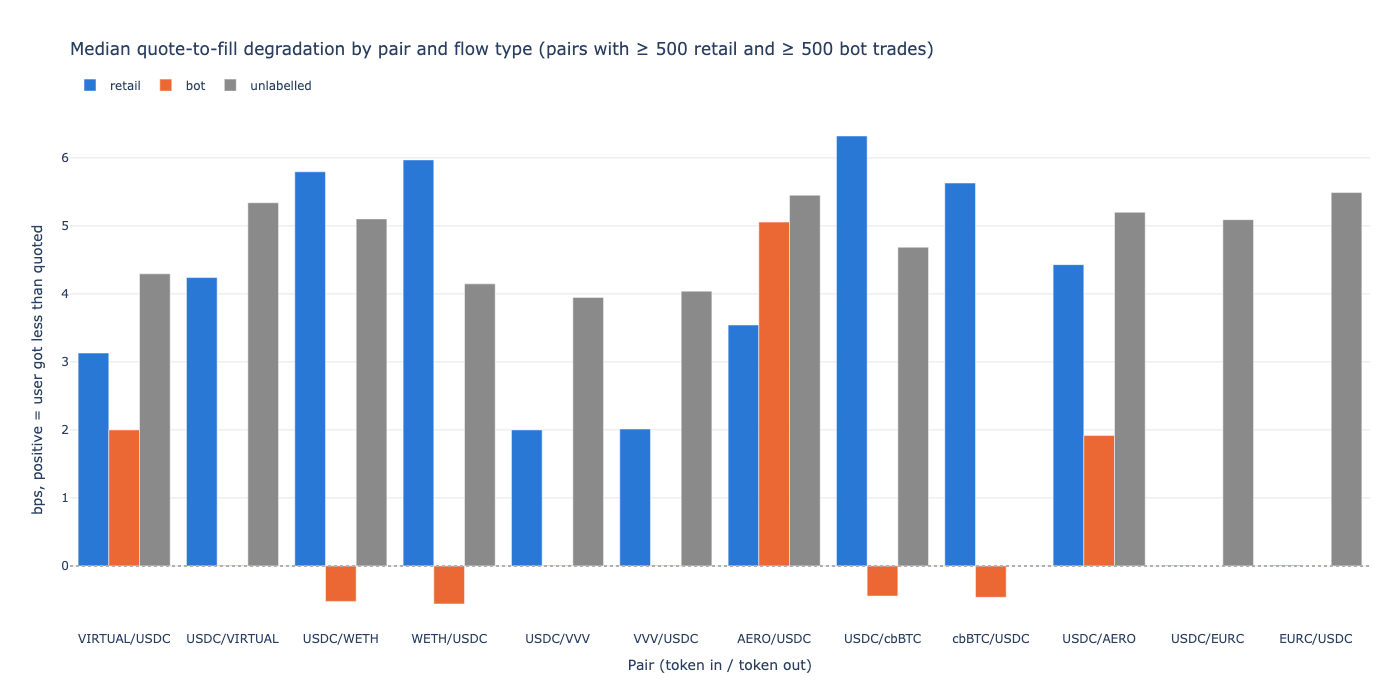

,median quote-to-fill bps
flow and pair mix,
"retail, own pair mix",4.61
"retail, reweighted to the bot pair mix",5.03
"bot, own pair mix",-0.32
"bot, reweighted to the retail pair mix",0.87


In [15]:
pair_flow = df.groupby(["pair", "flow"])["quote_to_fill_bps"].agg(n="size", p50="median").reset_index()
pair_flow_pivot = pair_flow.pivot(index="pair", columns="flow", values=["n", "p50"])
both = pair_flow_pivot[(pair_flow_pivot[("n", "retail")] >= 500) & (pair_flow_pivot[("n", "bot")] >= 500)].sort_values(("n", "retail"), ascending=False)

fig = go.Figure()
for flow in FLOW_ORDER:
    fig.add_bar(x=both.index, y=both[("p50", flow)], name=flow, marker_color=COLOURS[flow])
fig.add_hline(y=0, line=dict(color="#b0b0ad", dash="dot"))
fig.update_layout(barmode="group")
style(fig, "Median quote-to-fill degradation by pair and flow type (pairs with ≥ 500 retail and ≥ 500 bot trades)", "Pair (token in / token out)", "bps, positive = user got less than quoted").show()

retail_pair_median = pair_flow[pair_flow["flow"] == "retail"].set_index("pair")["p50"]
bot_pair_median = pair_flow[pair_flow["flow"] == "bot"].set_index("pair")["p50"]
retail_mix = df[df["flow"] == "retail"]["pair"].value_counts(normalize=True)
bot_mix = df[df["flow"] == "bot"]["pair"].value_counts(normalize=True)

def reweight(medians: pd.Series, weights: pd.Series) -> float:
    common = medians.index.intersection(weights.index)
    return float((medians[common] * weights[common]).sum() / weights[common].sum())

retail_on_bot_mix = reweight(retail_pair_median, bot_mix)
bot_on_retail_mix = reweight(bot_pair_median, retail_mix)
mix_adjusted = pd.DataFrame([
    ("retail, own pair mix", df.loc[df["flow"] == "retail", "quote_to_fill_bps"].median()),
    ("retail, reweighted to the bot pair mix", retail_on_bot_mix),
    ("bot, own pair mix", df.loc[df["flow"] == "bot", "quote_to_fill_bps"].median()),
    ("bot, reweighted to the retail pair mix", bot_on_retail_mix),
], columns=["flow and pair mix", "median quote-to-fill bps"]).set_index("flow and pair mix")
display(mix_adjusted.style.format("{:.2f}"))

fresh_majors = df[df["pair"].isin(MAJORS) & (df["benchmark_age_blocks"] <= 3)]
fair_by_pair = fresh_majors.groupby(["pair", "flow"])["fill_vs_benchmark_bps"].agg(n="size", p50="median").unstack("flow")
display(fair_by_pair.style.format({c: ("{:,.0f}" if c[0] == "n" else "{:.2f}") for c in fair_by_pair.columns}, na_rep="—"))

**What this chart shows.** Median quote-to-fill degradation per pair, retail and bots (and unlabelled) side by side, for the twelve pairs where both groups have at least 500 trades. The first table reweights each group's per-pair medians onto the other group's pair mix: "retail, reweighted to the bot pair mix" is what retail's median would be if retail traded the pairs bots trade, in the proportions bots trade them, at the fill quality retail actually gets on each pair. The second table repeats the fair-price comparison for each of the four major pairs separately.

**What the result means.** On every pair where the two meet, retail is filled worse than the quote and bots are filled at or better than it: 5.6 to 6.3 bps against −0.4 to −0.6 bps on the four WETH and cbBTC pairs, 2 to 4 bps against 0 to 2 bps on the VIRTUAL and VVV pairs. Reweighting makes the gap larger, not smaller: retail's median rises from 4.6 to 5.0 bps when moved onto the bot mix, because bots concentrate on the majors, where retail is skimmed most; bots' median rises from −0.3 to +0.9 bps when moved onto the retail mix, still far below retail. Against fair, the picture is the same on each major pair taken alone: retail 4.4 to 6.1 bps worse, bots 0.9 to 1.4 bps better. Two pairs stand out. EURC/USDC, the stablecoin pair, shows no skim at all for retail (0.01 bps in both directions), so the mechanism is applied per pair and switched off on the one pair where a 5 bps move would be visible against a 1:1 peg. AERO/USDC is the one pair where bots pay retail-like degradation (5.1 bps), which suggests the bot contracts active there are not the timing bots that dominate the majors.

**What it means for retail users.** Bars at exactly zero (retail and bots on EURC/USDC, unlabelled on cbBTC/USDC) are invisible; note that the unlabelled routers do pay about 5 bps on EURC/USDC, so the stablecoin exemption is not universal either. Pair choice is not a defence. A retail user buying ETH with USDC is on the pair where bots are most active and most advantaged, and the comparison is like-for-like: same pair, same venue, same blocks, opposite outcomes. Trading a thinner token halves the bps but does not remove them. The only retail-facing pair without a skim is the stablecoin pair, where the skim would have been trivially detectable.

## Aggregators send Tessera very different pair mixes

- Aggregator fill quality in Question 2 could likewise be a composition effect if the good aggregators simply route different pairs
- Here we show each aggregator's share of its Tessera retail volume by market

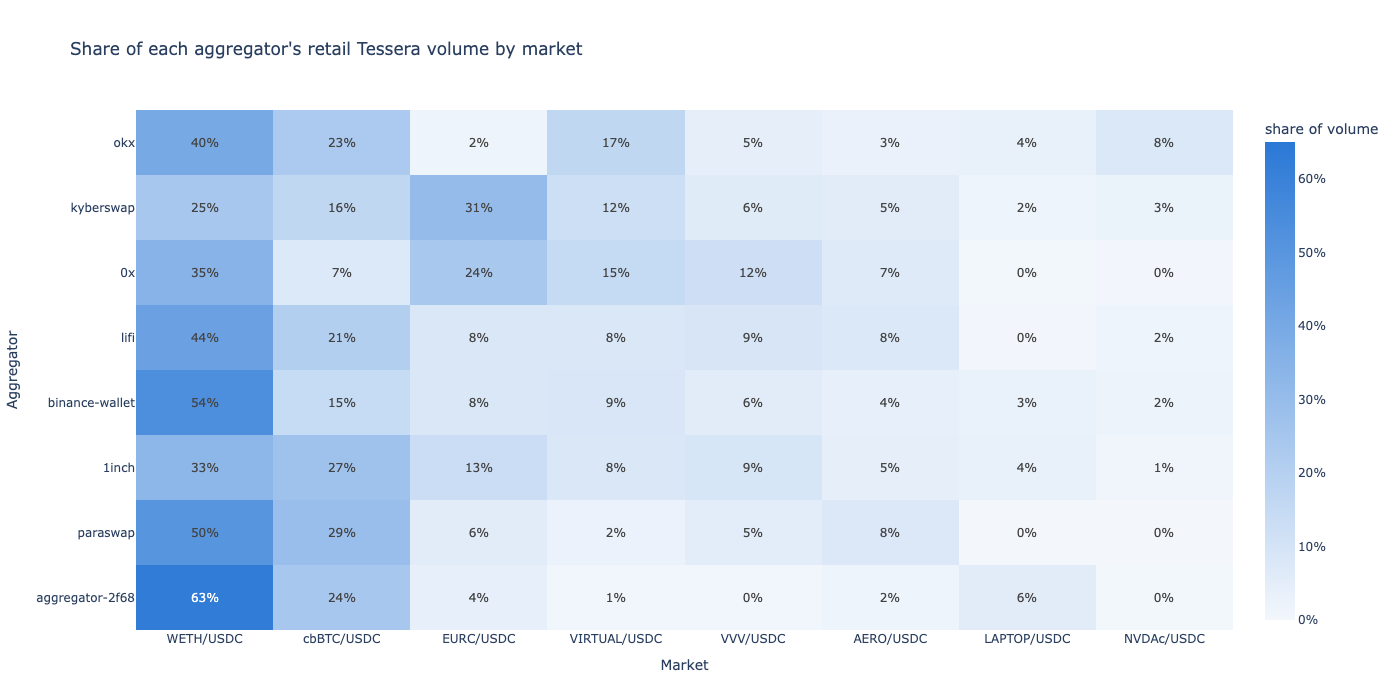

market,WETH/USDC,cbBTC/USDC,EURC/USDC,VIRTUAL/USDC,VVV/USDC,AERO/USDC,LAPTOP/USDC,NVDAc/USDC
aggregator,,,,,,,,
okx,23.8%,10.7%,0.3%,46.0%,5.0%,5.6%,4.1%,4.4%
kyberswap,14.4%,7.0%,11.6%,33.5%,16.7%,10.2%,4.7%,1.9%
0x,12.8%,1.4%,5.0%,37.9%,33.1%,8.6%,0.9%,0.3%
lifi,31.5%,10.3%,4.2%,16.1%,18.3%,16.7%,0.8%,2.0%
binance-wallet,32.5%,7.2%,15.5%,24.9%,5.7%,7.7%,5.2%,1.4%
1inch,13.4%,15.5%,3.4%,33.8%,11.3%,9.1%,10.5%,2.9%
paraswap,38.4%,10.5%,4.5%,11.1%,12.2%,23.2%,0.0%,0.0%
aggregator-2f68,58.8%,13.2%,7.8%,0.6%,0.4%,7.0%,11.5%,0.7%


In [16]:
retail = df[df["flow"] == "retail"]
top_aggregators = list(retail["aggregator"].value_counts().index[:8])
agg_market_volume = retail[retail["aggregator"].isin(top_aggregators)].pivot_table(index="aggregator", columns="market", values="notional_usd", aggfunc="sum", fill_value=0)
agg_market_volume = agg_market_volume.div(agg_market_volume.sum(axis=1), axis=0)
agg_market_order = list(agg_market_volume.sum().sort_values(ascending=False).index[:8])
agg_market_volume = agg_market_volume.loc[top_aggregators, agg_market_order]
agg_market_trades = retail[retail["aggregator"].isin(top_aggregators)].pivot_table(index="aggregator", columns="market", values="tx_hash", aggfunc="size", fill_value=0)
agg_market_trades = agg_market_trades.div(agg_market_trades.sum(axis=1), axis=0).loc[top_aggregators, agg_market_order]

fig = go.Figure(go.Heatmap(
    z=agg_market_volume.values, x=agg_market_order, y=top_aggregators,
    text=[[f"{v:.0%}" for v in row] for row in agg_market_volume.values], texttemplate="%{text}",
    colorscale=[[0, "#f3f7fc"], [1, COLOURS["retail"]]], zmin=0, zmax=0.65, colorbar=dict(title="share of volume", tickformat=".0%"),
))
style(fig, "Share of each aggregator's retail Tessera volume by market", "Market", "Aggregator", legend=False)
fig.update_yaxes(autorange="reversed")
fig.show()
display(agg_market_trades.style.format("{:.1%}").set_caption("Share of each aggregator's retail Tessera trades by market"))

**What this chart shows.** For the eight aggregators with the most retail Tessera trades, the share of that aggregator's Tessera volume in each market; each row sums to 100 %. The table gives the same split by trade count, which looks different because thin-token trades are small.

**What the result means.** The mixes differ a great deal. KyberSwap sends the most stablecoin flow (31 % of its volume in EURC/USDC, the pair with no skim) and the least WETH/USDC (25 %); 0x is similar (24 % EURC/USDC) and, by trade count, 71 % of its Tessera trades are VIRTUAL and VVV. Paraswap, the unnamed aggregator and Binance Wallet are majors-heavy (50 to 63 % WETH/USDC). OKX sends almost no EURC/USDC (1.5 %) and by trade count nearly half of its trades are VIRTUAL/USDC. So the Question 2 ranking compares aggregators on different baskets, and the next chart controls for that.

**What it means for retail users.** The pair a user is swapping and the aggregator they are using are not independent: the app a user picks also decides which of Tessera's markets their order is likely to land in, and therefore which per-pair skim applies. Whether the good aggregators are good because of what they route or because of how they route is the question the next chart answers.

## Within a pair, KyberSwap stays at one to two bps everywhere; 0x is protected only on the thin pairs

- The same aggregator comparison, one cell per aggregator and pair, so that composition is held fixed
- Each aggregator's per-pair medians are then reweighted onto the overall retail pair mix, giving a like-for-like ranking

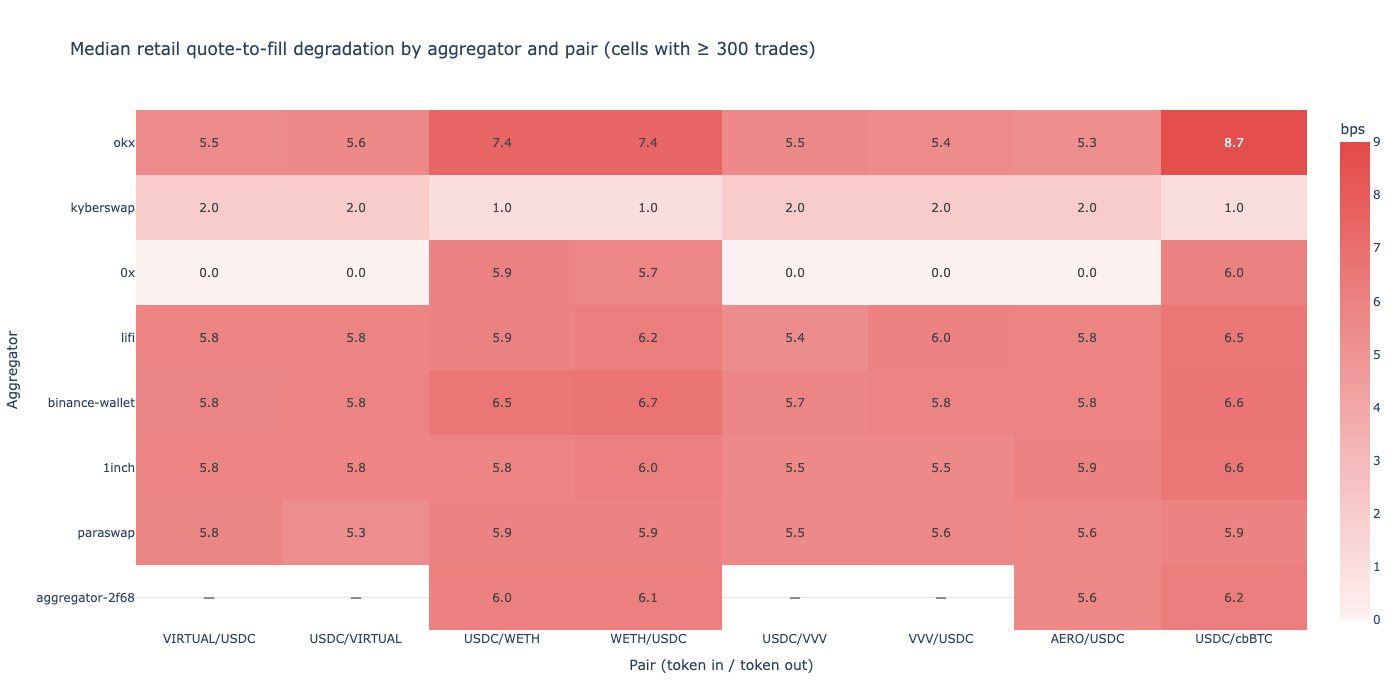

,own pair mix,reweighted to the retail pair mix,share of retail mix covered
aggregator,,,
0x,0.01,1.74,90%
kyberswap,1.43,1.84,100%
paraswap,5.76,5.68,88%
1inch,5.86,5.82,95%
lifi,5.88,5.87,95%
aggregator-2f68,5.99,5.99,42%
binance-wallet,6.08,6.07,99%
okx,6.01,6.46,94%


pair,VIRTUAL/USDC,USDC/VIRTUAL,USDC/WETH,WETH/USDC,USDC/VVV,VVV/USDC,AERO/USDC,USDC/cbBTC
aggregator,,,,,,,,
okx,"29,789","34,487","16,652","16,653","3,685","3,243","4,733","8,191"
kyberswap,"15,737","16,314","7,159","6,607","9,699","6,236","6,642","3,623"
0x,"11,913","7,448","5,750",773,"8,618","8,291","2,160",522
lifi,"3,801","3,059","7,740","5,650","4,123","3,664","4,215","2,485"
binance-wallet,"4,804","4,405","5,620","6,386","1,110",983,"1,385","1,104"
1inch,"3,072","2,378",871,"1,291",787,"1,036",877,"1,128"
paraswap,614,648,"2,434","1,935",690,696,"1,811",676
aggregator-2f68,—,—,"2,265","3,287",—,—,532,510


In [17]:
agg_pair = retail[retail["aggregator"].isin(top_aggregators)].groupby(["aggregator", "pair"])["quote_to_fill_bps"].agg(n="size", p50="median").reset_index()
agg_pair = agg_pair[agg_pair["n"] >= 300]
pair_order_retail = list(retail["pair"].value_counts().index[:8])
heat = agg_pair[agg_pair["pair"].isin(pair_order_retail)].pivot(index="aggregator", columns="pair", values="p50").reindex(index=top_aggregators, columns=pair_order_retail)
heat_n = agg_pair[agg_pair["pair"].isin(pair_order_retail)].pivot(index="aggregator", columns="pair", values="n").reindex(index=top_aggregators, columns=pair_order_retail)

fig = go.Figure(go.Heatmap(
    z=heat.values, x=pair_order_retail, y=top_aggregators,
    text=[[("—" if pd.isna(v) else f"{v:.1f}") for v in row] for row in heat.values], texttemplate="%{text}",
    colorscale=[[0, "#fdf1f1"], [1, COLOURS["fill"]]], zmin=0, zmax=9, colorbar=dict(title="bps"),
    hoverongaps=False,
))
style(fig, "Median retail quote-to-fill degradation by aggregator and pair (cells with ≥ 300 trades)", "Pair (token in / token out)", "Aggregator", legend=False)
fig.update_yaxes(autorange="reversed")
fig.show()

agg_mix_adjusted = pd.DataFrame([
    (a, retail.loc[retail["aggregator"] == a, "quote_to_fill_bps"].median(), reweight(agg_pair[agg_pair["aggregator"] == a].set_index("pair")["p50"], retail_mix), retail_mix.reindex(agg_pair.loc[agg_pair["aggregator"] == a, "pair"]).sum())
    for a in top_aggregators
], columns=["aggregator", "own pair mix", "reweighted to the retail pair mix", "share of retail mix covered"]).set_index("aggregator").sort_values("reweighted to the retail pair mix")
display(agg_mix_adjusted.style.format({"own pair mix": "{:.2f}", "reweighted to the retail pair mix": "{:.2f}", "share of retail mix covered": "{:.0%}"}))
display(heat_n.style.format("{:,.0f}", na_rep="—").set_caption("Trades per cell"))

**What this chart shows.** Median retail quote-to-fill degradation for every aggregator and pair combination with at least 300 trades, the eight busiest retail pairs across the columns. The first table gives each aggregator's overall median next to the same median reweighted onto the pair mix of all retail flow, with the share of that mix the aggregator's cells cover; the second table gives the trade count behind each cell.

**What the result means.** Holding the pair fixed splits the two "good" aggregators apart. KyberSwap is at 1.0 bps on the four major pairs and 2.0 bps on the thin pairs, in every cell. 0x is at 0.0 bps on VIRTUAL, VVV and AERO, where most of its trades are, but 5.7 to 6.0 bps on WETH/USDC and cbBTC/USDC, the same as everyone else. Reweighted onto the retail pair mix the two are tied, 0x at 1.7 bps and KyberSwap at 1.8, but for opposite reasons: KyberSwap is uniformly low, 0x is zero on the thin pairs (60 % of retail trades) and fully skimmed on the majors, where its users were not protected at all. OKX is the worst on the majors (7.4 bps on WETH/USDC, 8.7 on USDC/cbBTC) and about 5.5 on the thin pairs. The rest, 1inch, Paraswap, LI.FI, Binance Wallet and the unnamed aggregator, sit at 5.3 to 6.7 bps in every cell; their reweighted medians are within 0.1 bps of their raw ones. The values are quantised per aggregator and pair (KyberSwap exactly 1.0 or 2.0, 0x exactly 0.0 on thin pairs), which again reads as a configured parameter rather than market noise.

**What it means for retail users.** The Question 2 answer survives the composition check with one correction. KyberSwap users really do get better fills on the same pair, so its advantage is in how it routes and settles, not in what it routes. 0x users were protected only on the thin tokens; anyone swapping ETH or BTC through 0x paid the same six bps as through OKX or 1inch, and 0x's low overall number comes from its Tessera flow being mostly VIRTUAL and VVV. For a user the practical reading is per pair: on the majors only KyberSwap's users escape the skim, and on the thin pairs KyberSwap and 0x both do.

# Question 4: how much?

## Tessera's quote beats fair by 0.2 bps; the retail fill misses fair by 6

- Aggregators route to Tessera because its quote beats the AMM pools. We check that claim against the marginal price of the deepest pool for each pair at the same moment (end of the previous block)
- `quote vs fair` is the price improvement the aggregator saw; `fill vs fair` is what the user actually got
- Only WETH/USDC and cbBTC/USDC have a reference that is both deep and fresh (reference age ≤ 3 blocks); thin pairs are excluded because their pool price is stale and wide

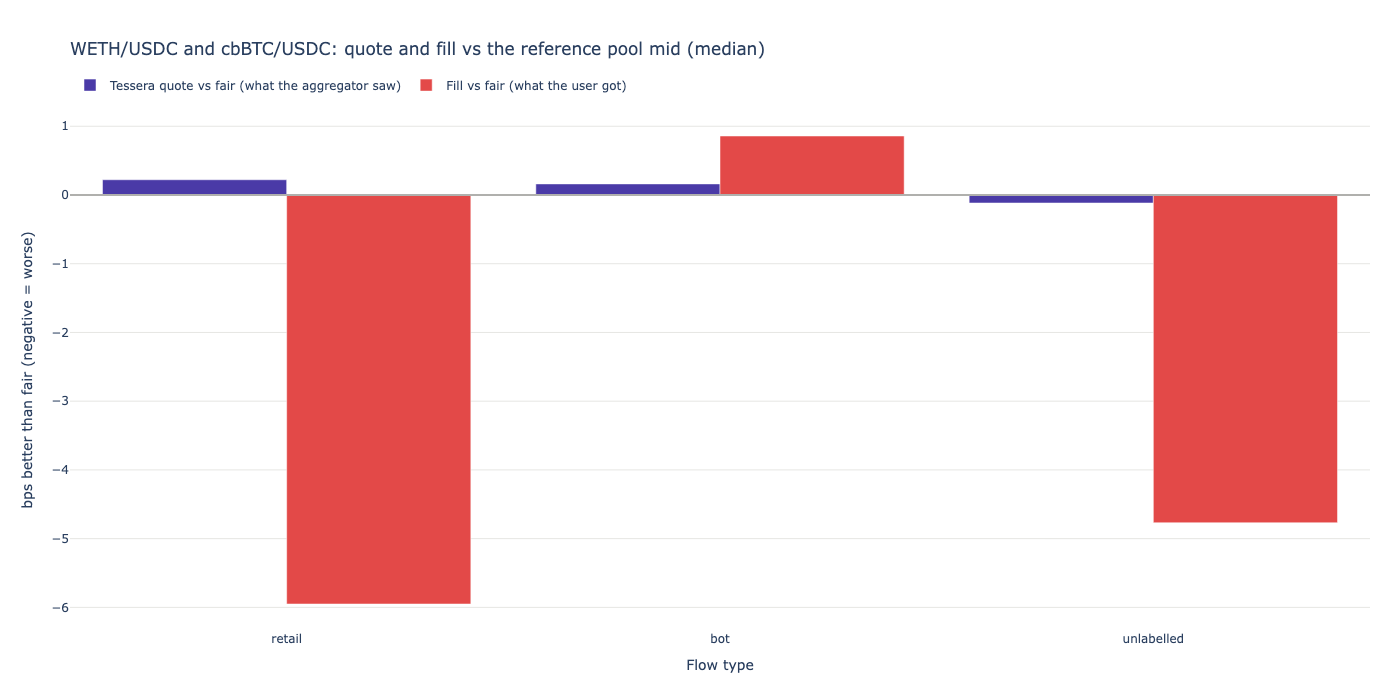

,n,quote_vs_fair_p50,fill_vs_fair_p50,fill_vs_fair_mean,pool_fee_bps
flow,,,,,
retail,"90,605",0.22,5.95,6.56,1.0
bot,"91,616",0.16,-0.86,-0.66,1.0
unlabelled,"35,477",-0.12,4.77,4.64,1.0


fill_vs_fair is positive when the user received less than the reference mid implied. A direct pool fill would have cost roughly the pool fee plus impact.


In [18]:
majors = df[df["pair"].isin(["WETH/USDC", "USDC/WETH", "cbBTC/USDC", "USDC/cbBTC"]) & (df["benchmark_age_blocks"] <= 3)]
fair = majors.groupby("flow").agg(
    n=("tx_hash", "size"),
    quote_vs_fair_p50=("quote_vs_benchmark_bps", "median"),
    fill_vs_fair_p50=("fill_vs_benchmark_bps", "median"),
    fill_vs_fair_mean=("fill_vs_benchmark_bps", "mean"),
    pool_fee_bps=("benchmark_fee_bps", "median"),
).reindex(FLOW_ORDER)

fig = go.Figure()
fig.add_bar(name="Tessera quote vs fair (what the aggregator saw)", x=FLOW_ORDER, y=fair["quote_vs_fair_p50"], marker_color=COLOURS["quote"])
fig.add_bar(name="Fill vs fair (what the user got)", x=FLOW_ORDER, y=-fair["fill_vs_fair_p50"], marker_color=COLOURS["fill"])
fig.add_hline(y=0, line=dict(color="#b0b0ad"))
fig.update_layout(barmode="group")
style(fig, "WETH/USDC and cbBTC/USDC: quote and fill vs the reference pool mid (median)", "Flow type", "bps better than fair (negative = worse)").show()
display(fair.style.format({"n": "{:,}", "quote_vs_fair_p50": "{:.2f}", "fill_vs_fair_p50": "{:.2f}", "fill_vs_fair_mean": "{:.2f}", "pool_fee_bps": "{:.1f}"}))
print("fill_vs_fair is positive when the user received less than the reference mid implied. A direct pool fill would have cost roughly the pool fee plus impact.")

**What this chart shows.** For WETH/USDC and cbBTC/USDC, where the reference pool has a swap within three blocks of every trade, two medians per flow type: how much better than the reference pool mid Tessera's *quote* was (what the aggregator saw when it chose Tessera), and how much better or worse than the mid the *fill* was (what the user got). Positive is better than fair.

**What the result means.** The aggregator's decision looks correct on paper: Tessera's quote is 0.22 bps better than the deepest pool's mid. The retail fill is 5.95 bps worse than that mid (mean 6.56). Bots are filled 0.86 bps better than the mid. The routing "price improvement" that justified sending the order to Tessera is a fifth of a basis point; the fill loss is almost thirty times larger than the improvement. A direct fill in the reference pool would have cost the 1 bp fee plus a small impact, so the retail user ended up four to five bps worse off than not being routed to Tessera at all.

**What it means for retail users.** This is the complete answer to "was I better off on Tessera?" for the majors: no. The venue won the order by quoting a hair inside the pool and then delivered a fill well outside it. The user sees neither the mid nor the fill relative to it; they see a successful swap. Bots, who trade the same venue in the same blocks, come out ahead of the mid, which is why there is a bot industry around this venue and no retail industry.

## Nearly all retail fills are below fair, most bot fills are above

- The full distribution for the majors: bots sit slightly better than the fair mid, retail sits several basis points below it
- The gap between the two curves is the value transferred from retail users, in the same blocks, at the same venue

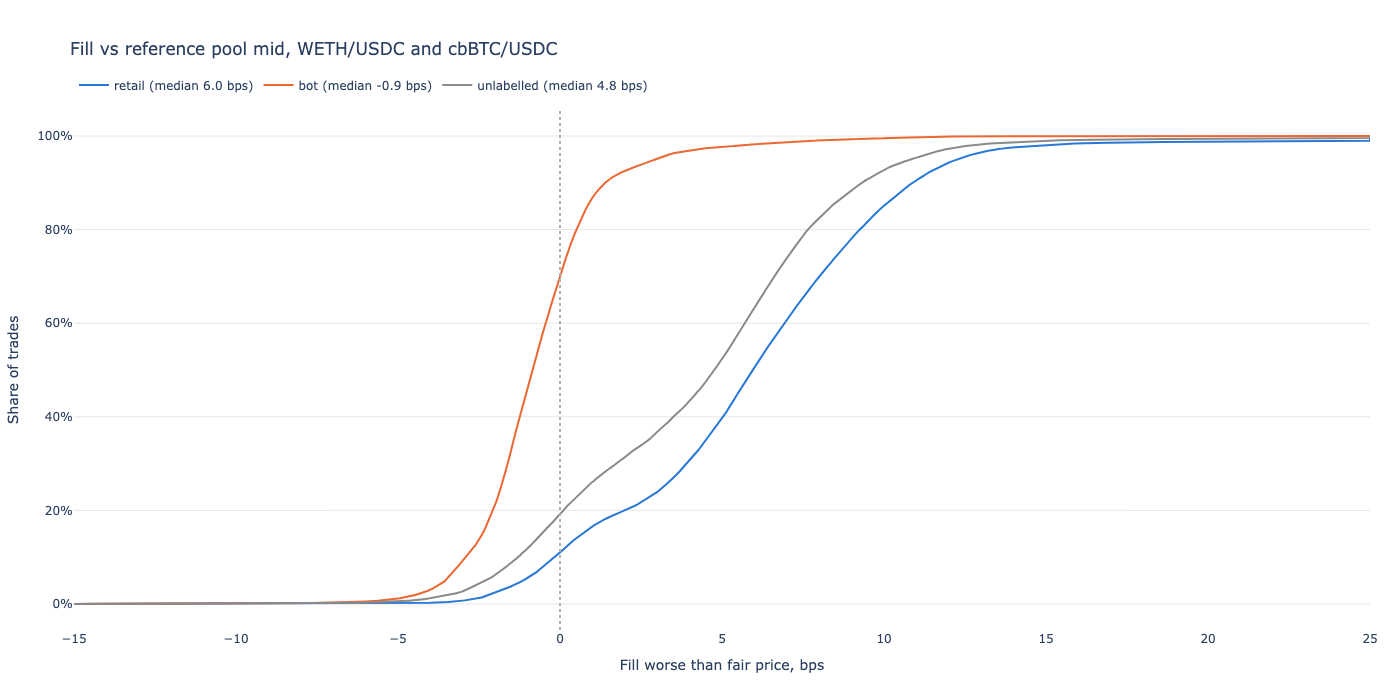

In [19]:
fig = go.Figure()
for flow in FLOW_ORDER:
    s = majors.loc[majors["flow"] == flow, "fill_vs_benchmark_bps"].dropna().clip(-15, 25).sort_values()
    fig.add_scatter(x=s.values, y=np.linspace(0, 1, len(s)), mode="lines", name=f"{flow} (median {s.median():.1f} bps)", line=dict(color=COLOURS[flow], width=2))
fig.add_vline(x=0, line=dict(color="#b0b0ad", dash="dot"))
style(fig, "Fill vs reference pool mid, WETH/USDC and cbBTC/USDC", "Fill worse than fair price, bps", "Share of trades")
fig.update_yaxes(tickformat=".0%")
fig.show()

**What this chart shows.** The full distribution behind the previous chart: for every trade on the majors, how far the fill was from the reference pool mid, as cumulative curves for retail, bots and unlabelled flow.

**What the result means.** The retail and bot curves are separated by about seven bps across the whole distribution, not just at the median: roughly 90 % of retail fills are worse than the mid, roughly 70 % of bot fills are better. The unlabelled curve sits between them, closer to retail. The gap between the two curves is the value that changes hands between the two kinds of user of the same venue in the same blocks.

**What it means for retail users.** There is no lucky tail for retail: it is not that some retail users get good fills and others bad, it is that nearly all retail fills sit below fair by a similar amount. The gap cannot be closed by timing, size or persistence from the user's side, because the fills that come out ahead belong to contracts that read the venue's own price store and submit at the bottom of the block.

## $97k taken from retail in the window, by aggregator

- Quote-to-fill gap in USD, summed per day and split by aggregator, for retail trades with a USDC leg
- Negative days would mean users got more than quoted; there are none

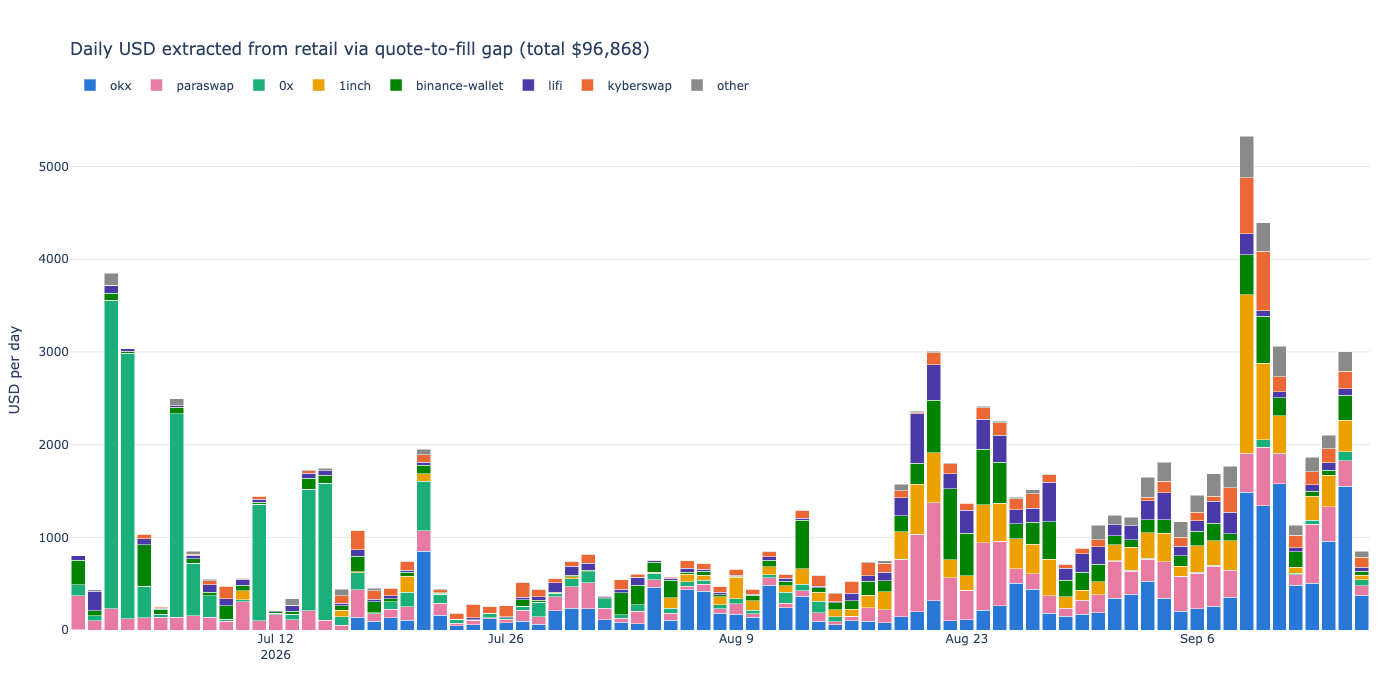

,trades,notional_usd,extracted_usd,extracted_bps_of_volume
aggregator,,,,
okx,"139,203","$30,559,185","$20,185",6.61
paraswap,"11,324","$30,494,249","$17,728",5.81
0x,"50,897","$70,166,378","$16,521",2.35
1inch,"16,053","$23,374,466","$11,961",5.12
binance-wallet,"36,729","$17,977,708","$11,528",6.41
lifi,"42,472","$14,357,935","$7,848",5.47
kyberswap,"95,400","$102,435,849","$6,778",0.66
aggregator-2f68,"9,355","$4,084,754","$2,439",5.97
cowswap,"6,624","$3,997,940","$1,879",4.70


In [20]:
retail = df[(df["flow"] == "retail") & df["extracted_usd"].notna()]
daily = retail.pivot_table(index="day", columns="aggregator", values="extracted_usd", aggfunc="sum", fill_value=0)
top_aggs = daily.sum().sort_values(ascending=False).index[:7]
daily["other"] = daily.drop(columns=top_aggs).sum(axis=1)
daily = daily[list(top_aggs) + ["other"]]

fig = go.Figure()
for name in daily.columns:
    fig.add_bar(name=name, x=daily.index, y=daily[name], marker_color=AGGREGATOR_COLOURS.get(name, "#8a8a8a"))
fig.update_layout(barmode="stack")
style(fig, f"Daily USD extracted from retail via quote-to-fill gap (total ${retail['extracted_usd'].sum():,.0f})", "", "USD per day").show()

total_by_agg = retail.groupby("aggregator").agg(trades=("tx_hash", "size"), notional_usd=("notional_usd", "sum"), extracted_usd=("extracted_usd", "sum"))
total_by_agg["extracted_bps_of_volume"] = total_by_agg["extracted_usd"] / total_by_agg["notional_usd"] * 1e4
display(total_by_agg.sort_values("extracted_usd", ascending=False).style.format({"trades": "{:,}", "notional_usd": "${:,.0f}", "extracted_usd": "${:,.0f}", "extracted_bps_of_volume": "{:.2f}"}))

**What this chart shows.** The quote-to-fill gap converted to dollars on the USDC leg of each retail trade, summed per day and stacked by aggregator. The table gives the total per aggregator and the extraction as basis points of that aggregator's volume.

**What the result means.** $97k was taken from retail through the quote-to-fill gap in the window on $299M of retail volume, about 3.2 bps of volume overall. Per aggregator the rate is what the box plot predicted: OKX 6.6 bps of its volume, Binance Wallet 6.4, Paraswap 5.8, LI.FI 5.5, 1inch 5.1, against KyberSwap at 0.7 and 0x at 2.4 (0x's average is pulled up by its July fills, before its Tessera volume fell away). There are no negative days: the venue never gave retail back more than it quoted.

**What it means for retail users.** The dollar amount is small relative to the venue's volume and large relative to the retail users who pay it, because it is spread across hundreds of thousands of small trades. $97k over two and a half months on one venue on one chain is not a scandal by itself; the pattern it exposes is, because it repeats on every fill, on every day, on every aggregator that does not check its own fills.

## Roughly $0.6M over the venue's lifetime, as an estimate

- The quote enrichment covers the analysis window; raw trade volume is available for the whole ten months
- We apply the window's measured extraction per dollar of volume for each pair to the monthly full-history volume of that pair
- This is an estimate: it assumes the window's average skim rate and retail share of volume held over time. The time series above shows the skim comes in regimes (on in early July, off from late July to mid August, on again since), so any single month can be well above or below this average

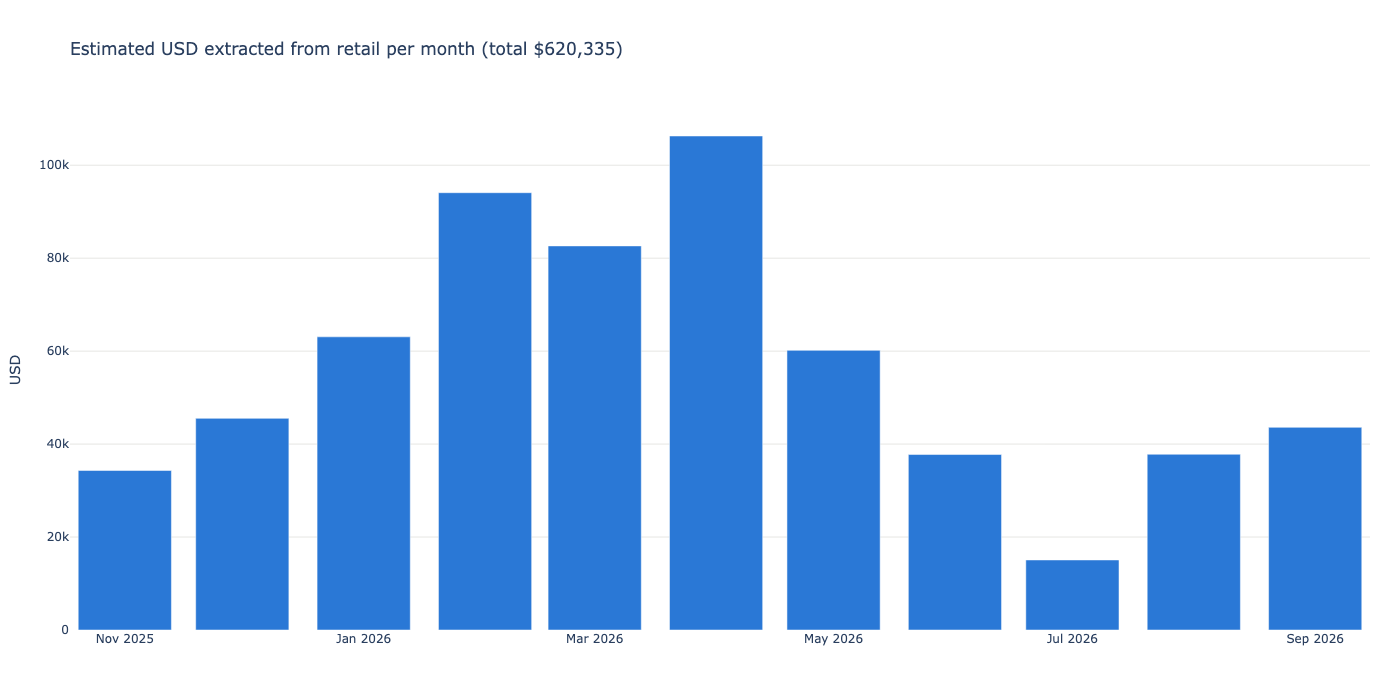

,volume_usd,estimated_extracted_usd,trades
month,,,
2025-11,"$368,356,687","$34,319","525,677"
2025-12,"$481,557,744","$45,535","704,404"
2026-01,"$659,905,803","$63,076","1,036,259"
2026-02,"$1,019,423,126","$94,084","1,126,428"
2026-03,"$926,658,710","$82,636","808,886"
2026-04,"$1,198,228,735","$106,286","546,909"
2026-05,"$659,903,789","$60,167","699,255"
2026-06,"$457,428,911","$37,756","272,596"
2026-07,"$222,167,119","$15,069","168,484"


In [21]:
monthly = con.execute("""
    SELECT date_trunc('month', t.timestamp) AS month, t.symbol_in || '/' || t.symbol_out AS pair,
           sum(CASE WHEN t.token_in = ? THEN t.amount_in_decimal WHEN t.token_out = ? THEN t.amount_out_decimal END) AS volume_usd,
           count(*) AS trades
    FROM trade_analysis t
    WHERE t.venue = 'tessera'
    GROUP BY 1, 2
""", [USDC, USDC]).df().dropna(subset=["volume_usd"])

# Measured extraction per dollar of total volume (all flow types) per pair in the window, so the window months reproduce the measured total
window_pairs = df[df["notional_usd"].notna()].groupby("pair").agg(volume_usd=("notional_usd", "sum"), extracted_usd=("extracted_usd", lambda s: s[df.loc[s.index, "flow"] == "retail"].sum()))
window_pairs["extraction_rate"] = window_pairs["extracted_usd"] / window_pairs["volume_usd"]
monthly = monthly.join(window_pairs["extraction_rate"], on="pair").dropna()
monthly["estimated_extracted_usd"] = monthly["volume_usd"] * monthly["extraction_rate"]
est = monthly.groupby("month").agg(volume_usd=("volume_usd", "sum"), estimated_extracted_usd=("estimated_extracted_usd", "sum"), trades=("trades", "sum"))
est = est[est["trades"] >= 1000]

fig = go.Figure(go.Bar(x=est.index, y=est["estimated_extracted_usd"], marker_color=COLOURS["retail"], name="estimated USD extracted"))
style(fig, f"Estimated USD extracted from retail per month (total ${est['estimated_extracted_usd'].sum():,.0f})", "", "USD", legend=False).show()
est.index = est.index.strftime("%Y-%m")
display(est.style.format({"volume_usd": "${:,.0f}", "estimated_extracted_usd": "${:,.0f}", "trades": "{:,}"}))

**What this chart shows.** An estimate of dollars extracted per month over Tessera's whole history on Base, applying the window's measured extraction per dollar of volume for each pair to that pair's full-history monthly volume. Months with fewer than a thousand trades are dropped.

**What the result means.** About $620k over the ten months, peaking at roughly $100k a month in the high-volume months of February to April. This is an estimate: it assumes the window's skim rate and the window's retail share of volume held in earlier months. The regime section shows the skim was switched off for five days in July, so the assumption is not exact; it is offered as an order of magnitude, not an account.

**What it means for retail users.** Over the venue's lifetime the pattern documented here has plausibly cost Base retail users somewhere in the mid six figures, spread thinly enough that no single user had reason to notice. The amount is less interesting than the durability: the mechanism has been running since the venue launched, through volume that grew tenfold and fell back, unchanged.

# Why are retail fills worse?

## Bots trade at the keeper's refresh, retail trades in the middle of the block

- Overlay where in the block the keeper updates prices, where bots fill, and where retail fills
- Bots trade at the very top of the block (ahead of the first keeper update) or at the very bottom (after the refresh); almost never in between
- Retail transactions arrive through aggregator routers and ordinary mempool ordering and land in the middle of the block, after the top-of-block update

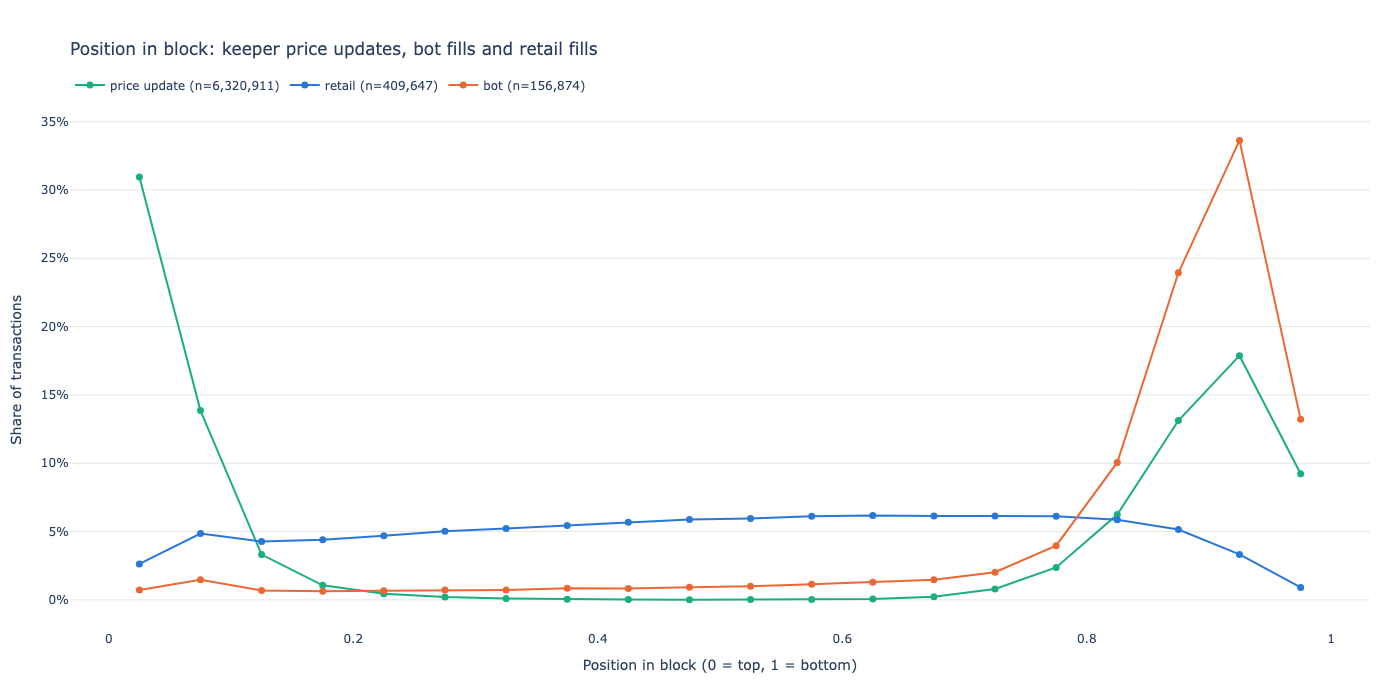

In [22]:
edges = np.linspace(0, 1, 21)
centers = (edges[:-1] + edges[1:]) / 2
upd = con.execute("""
    SELECT rel_gas_position FROM price_update_analysis
    WHERE selector = '0x1667d875' AND block_number >= ? AND rel_gas_position IS NOT NULL
""", [WINDOW_START_BLOCK]).df()["rel_gas_position"]

fig = go.Figure()
series = {"price update": upd, "retail": df.loc[df["flow"] == "retail", "rel_gas_position"], "bot": df.loc[df["flow"] == "bot", "rel_gas_position"]}
for name, s in series.items():
    hist, _ = np.histogram(s.dropna().clip(0, 0.999), bins=edges)
    fig.add_scatter(x=centers, y=hist / hist.sum(), mode="lines+markers", name=f"{name} (n={len(s):,})", line=dict(color=COLOURS[name], width=2), marker=dict(size=7))
style(fig, "Position in block: keeper price updates, bot fills and retail fills", "Position in block (0 = top, 1 = bottom)", "Share of transactions")
fig.update_yaxes(tickformat=".0%")
fig.show()

**What this chart shows.** Three distributions over position in the block, on one axis: where the keeper's price updates land, where bot fills land, and where retail fills land.

**What the result means.** Bots and the keeper are mirror images: bot fills peak at position 0.9, exactly where the keeper's end-of-block refresh lands, and at the very top of the block ahead of the keeper's first update; almost none land in the middle. Retail is spread flat through the middle of the block, where ordinary transaction ordering puts it. Whatever state the venue is in between the keeper's top-of-block write and its bottom-of-block refresh, bots avoid it and retail cannot.

**What it means for retail users.** A retail transaction is submitted through an app, forwarded by a router, and included wherever the sequencer places it. Landing at the exact end of a two-second block, after the venue has refreshed its quote and before the next block's reprice, is not something a wallet or app offers as an option. The bots on this chart do exactly that, on tens of thousands of fills, by reading the venue's price store and submitting with precise timing. The position of a fill in the block is the single variable that separates the two groups' outcomes, and it is the one variable retail does not control.

## The price is worse for everyone mid-block; bots avoid the middle

- If the top-of-block reprice is the mechanism, fills that land after it should be worse than fills that land before it or after the end-of-block refresh
- Median quote-to-fill by in-block position, retail vs bot
- The venue does not discriminate by counterparty: bots that do land mid-block pay the same five bps as retail. The price is worse for everyone in the middle of every block; bots simply avoid the middle and retail cannot

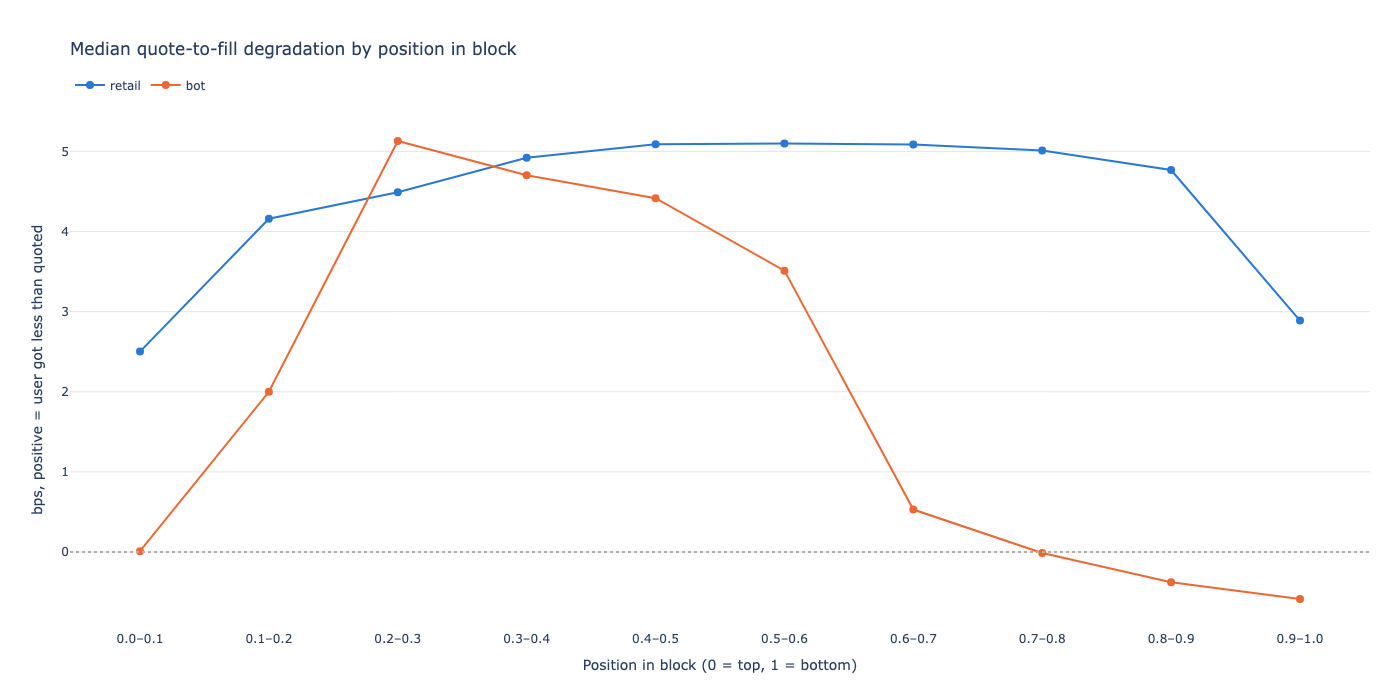

flow,bot,retail,unlabelled
position_bin,,,
0.0–0.1,0.01,2.50,0.01
0.1–0.2,2.00,4.16,4.87
0.2–0.3,5.13,4.49,5.48
0.3–0.4,4.70,4.92,5.49
0.4–0.5,4.42,5.09,5.48
0.5–0.6,3.51,5.10,5.43
0.6–0.7,0.53,5.08,5.50
0.7–0.8,-0.01,5.01,5.30
0.8–0.9,-0.38,4.77,4.47


In [23]:
df["position_bin"] = pd.cut(df["rel_gas_position"], bins=np.linspace(0, 1, 11), labels=[f"{i/10:.1f}–{(i+1)/10:.1f}" for i in range(10)], include_lowest=True)
pos = df.groupby(["position_bin", "flow"], observed=True)["quote_to_fill_bps"].agg(n="size", p50="median").reset_index()

fig = go.Figure()
for flow in ["retail", "bot"]:
    sub = pos[(pos["flow"] == flow) & (pos["n"] >= 200)]
    fig.add_scatter(x=sub["position_bin"].astype(str), y=sub["p50"], mode="lines+markers", name=flow, line=dict(color=COLOURS[flow], width=2), marker=dict(size=8))
fig.add_hline(y=0, line=dict(color="#b0b0ad", dash="dot"))
style(fig, "Median quote-to-fill degradation by position in block", "Position in block (0 = top, 1 = bottom)", "bps, positive = user got less than quoted").show()
display(pos.pivot(index="position_bin", columns="flow", values="p50").style.format("{:.2f}"))

**What this chart shows.** Median quote-to-fill degradation as a function of where in the block the fill landed, retail and bots on the same axis.

**What the result means.** The venue does not discriminate by counterparty. Bots that do land in the middle of the block pay the same four to five bps as retail (bins 0.2 to 0.6); bots at the top of the block pay nothing and bots at the bottom are filled better than the quote. Retail's curve is flat at about five bps because retail almost never lands at either end. The price is worse for everyone in the middle of every block; bots simply avoid the middle.

**What it means for retail users.** This chart removes the possibility that retail is being identified and charged as retail. Nobody is being charged as such; the venue is in a worse-price state for a large fraction of every block, and retail transactions happen to land in it. A retail user who could reliably land at the very end of a block would get the bot price. None can.

## One keeper update before the fill costs five bps, none or two cost nothing

- For every trade, count the keeper price updates earlier in the same block
- Trades that settle after a reprice in their own block should be worse than trades that settle before any update
- The pattern is exact: zero updates before the fill gives zero degradation, one update (the top-of-block reprice) gives the full skim, two updates (the refresh has landed) gives zero again

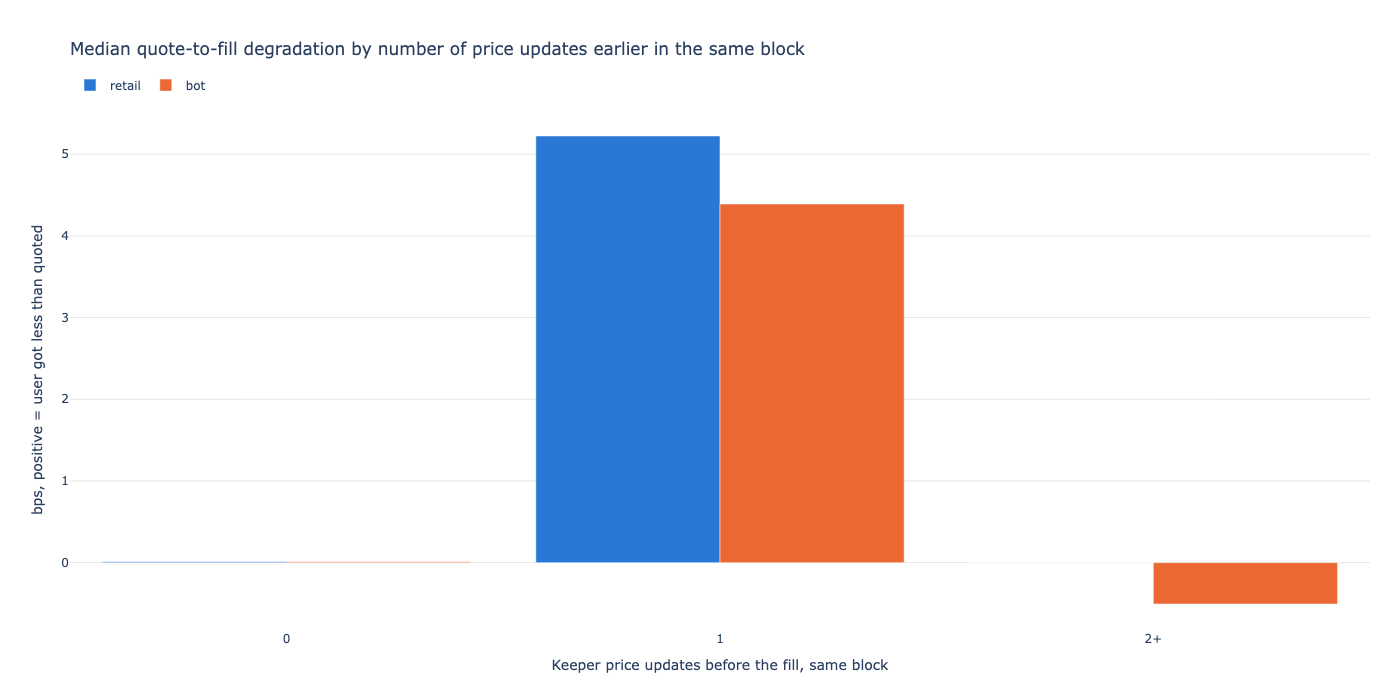

In [24]:
before = con.execute("""
    SELECT t.tx_hash, t.log_index,
           count(u.tx_index) FILTER (WHERE u.tx_index < t.tx_index) AS updates_before,
           count(u.tx_index) FILTER (WHERE u.tx_index > t.tx_index) AS updates_after
    FROM trades t
    LEFT JOIN price_updates u ON u.block_number = t.block_number AND u.selector = '0x1667d875'
    WHERE t.venue = 'tessera' AND t.block_number >= ?
    GROUP BY 1, 2
""", [WINDOW_START_BLOCK]).df()
df = df.drop(columns=[c for c in ["updates_before", "updates_after"] if c in df.columns]).merge(before, on=["tx_hash", "log_index"], how="left")
df["updates_before_bucket"] = pd.cut(df["updates_before"], bins=[-1, 0, 1, np.inf], labels=["0", "1", "2+"])

ub = df.groupby(["updates_before_bucket", "flow"], observed=True)["quote_to_fill_bps"].agg(n="size", p50="median").reset_index()
fig = go.Figure()
for flow in ["retail", "bot"]:
    sub = ub[(ub["flow"] == flow) & (ub["n"] >= 200)]
    fig.add_bar(x=sub["updates_before_bucket"].astype(str), y=sub["p50"], name=flow, marker_color=COLOURS[flow])
fig.update_layout(barmode="group")
style(fig, "Median quote-to-fill degradation by number of price updates earlier in the same block", "Keeper price updates before the fill, same block", "bps, positive = user got less than quoted").show()
ub_pivot = ub.pivot(index="updates_before_bucket", columns="flow", values=["n", "p50"])
display(ub_pivot.style.format({c: ("{:,.0f}" if c[0] == "n" else "{:.2f}") for c in ub_pivot.columns}))

**What this chart shows.** For every fill, the number of keeper price updates earlier in the same block, and the median degradation for fills with zero, one, and two or more prior updates, retail and bots side by side.

**What the result means.** The pattern is exact: fills with no prior update in their block are filled at the quote (0.01 bps, both flows); fills after exactly one update, the top-of-block reprice, are filled 5.2 bps worse (retail) and 4.4 bps worse (bots); fills after two or more updates, when the end-of-block refresh has landed, are back at the quote or better. The state that costs the user five bps begins with the keeper's first write in the block and ends with its second.

**What it means for retail users.** This is the mechanism in one table. Between the venue's two writes per block, its quotes are set worse than the price it published at the end of the previous block and worse than the price it will publish again at the end of this one. Retail users trade in that interval because that is where their transactions land. The interval is created and closed by the venue's own keeper, twice a block, all day.

## Two thirds of retail fills are worse than both the quote before and after

- Compare each fill with the quote at the end of the previous block (before) and the quote at the end of its own block (after)
- If the fill is worse than *both*, the price was widened around the fill and tightened again afterwards: the temporary widening 0x described
- If the fill is only worse than the earlier quote, the market moved and the new price stayed
- Roughly three quarters of retail fills are worse than both quotes: the worse price is a transient state of the venue, not a market move

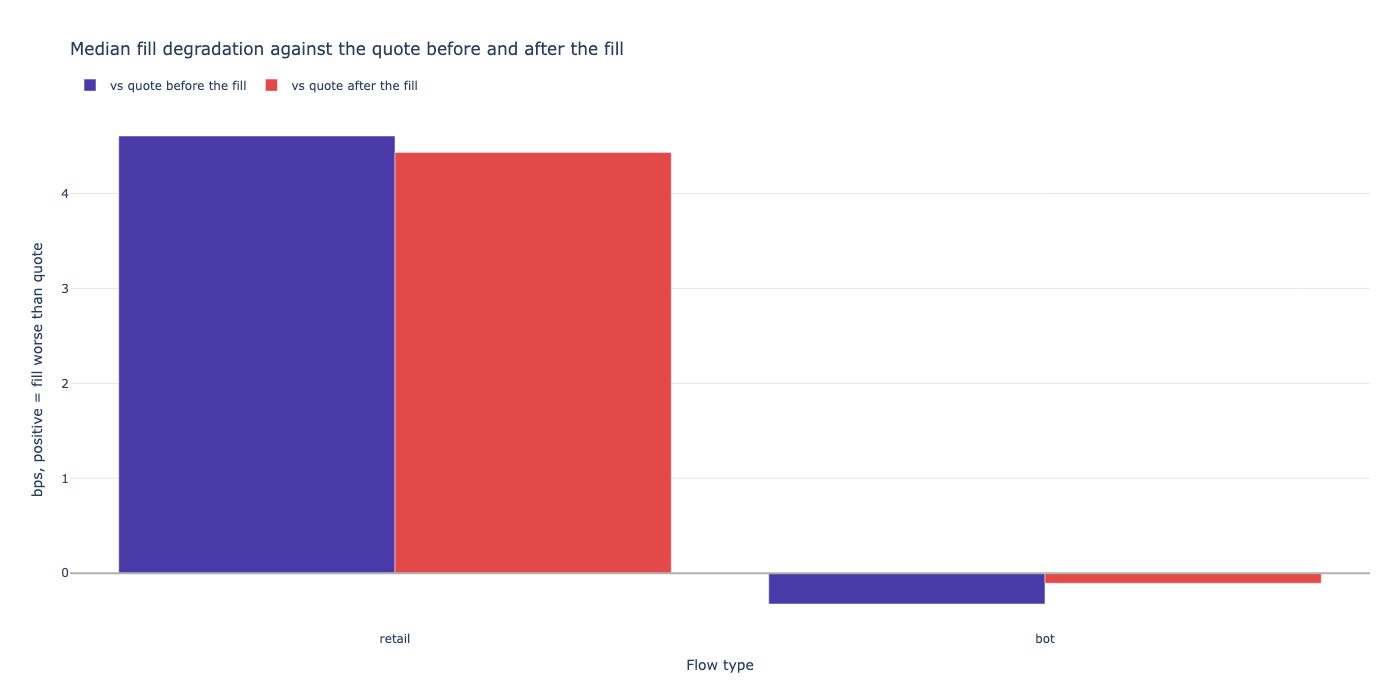

Retail fills worse than both the earlier and the later quote by more than 1 bps: 67%; worse only than the earlier quote: 8%


In [25]:
retail = df[df["flow"] == "retail"].dropna(subset=["quote_to_fill_bps", "same_block_quote_to_fill_bps"])
worse_than_both = ((retail["quote_to_fill_bps"] > 1) & (retail["same_block_quote_to_fill_bps"] > 1)).mean()
worse_only_before = ((retail["quote_to_fill_bps"] > 1) & (retail["same_block_quote_to_fill_bps"] <= 1)).mean()

comp = pd.DataFrame({
    "vs quote before (end of previous block)": [df.loc[df["flow"] == f, "quote_to_fill_bps"].median() for f in ["retail", "bot"]],
    "vs quote after (end of own block)": [df.loc[df["flow"] == f, "same_block_quote_to_fill_bps"].median() for f in ["retail", "bot"]],
}, index=["retail", "bot"])

fig = go.Figure()
fig.add_bar(name="vs quote before the fill", x=comp.index, y=comp.iloc[:, 0], marker_color=COLOURS["quote"])
fig.add_bar(name="vs quote after the fill", x=comp.index, y=comp.iloc[:, 1], marker_color=COLOURS["fill"])
fig.update_layout(barmode="group")
fig.add_hline(y=0, line=dict(color="#b0b0ad"))
style(fig, "Median fill degradation against the quote before and after the fill", "Flow type", "bps, positive = fill worse than quote").show()
print(f"Retail fills worse than both the earlier and the later quote by more than 1 bps: {worse_than_both:.0%}; worse only than the earlier quote: {worse_only_before:.0%}")

**What this chart shows.** Each fill compared with two quotes: the quote at the end of the previous block (before the fill) and the quote at the end of the fill's own block (after it). If the fill is worse than both, the price was widened around the fill and tightened again afterwards. If it is worse only than the earlier quote, the market moved and the new price stayed.

**What the result means.** 67 % of retail fills are worse than both the quote before and the quote after by more than a basis point; only 8 % are worse than the earlier quote alone. Retail's median degradation is about five bps against either quote. Bots are at or better than both. The worse price is a transient state of the venue that exists during the fill and is gone by the end of the block; it is not the market moving.

**What it means for retail users.** If a user checked Tessera's price a second before their trade and a second after, they would see two prices that agree with each other and with the pool, and a fill that matches neither. There is no market move to blame it on and no chart on which it would show up; the only record is the difference between the user's own received amount and the two quotes that bracket it.

## The keeper writes one parameter state at the top of the block and resets it at the bottom

- The keeper payload is three packed 32-bit words that we could not fully decode without the engine source
- The first word is, however, revealing: the top-of-block update sets it to a baseline plus an offset, the end-of-block update resets it to the baseline
- Whatever the parameter is, the venue is in one state while retail settles and in another when the aggregator quotes and bots trade

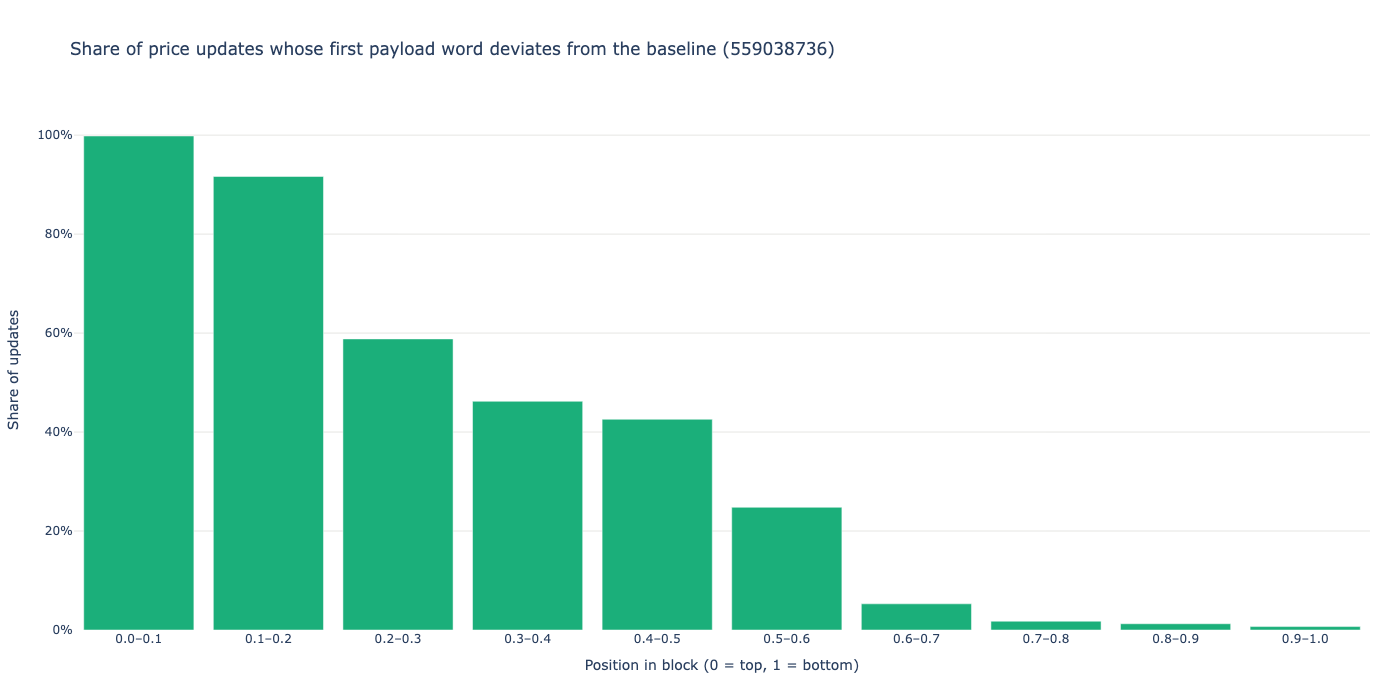

,n,share_nonzero,median_abs_offset
position_bin,,,
0.0–0.1,"2,832,071",99.8%,559
0.1–0.2,"276,804",91.6%,545
0.2–0.3,"42,113",58.8%,98
0.3–0.4,"9,261",46.2%,0
0.4–0.5,"2,844",42.6%,0
0.5–0.6,"2,799",24.8%,0
0.6–0.7,"17,839",5.3%,0
0.7–0.8,"200,085",1.8%,0
0.8–0.9,"1,224,044",1.3%,0


In [26]:
words = con.execute("""
    SELECT rel_gas_position, ('0x' || substr(input, 51, 8))::UBIGINT AS word1
    FROM price_update_analysis
    WHERE selector = '0x1667d875' AND block_number >= ? AND length(input) >= 74 AND rel_gas_position IS NOT NULL
""", [WINDOW_START_BLOCK]).df()
baseline = words["word1"].mode().iloc[0]
words["offset"] = words["word1"].astype("int64") - int(baseline)
words["position_bin"] = pd.cut(words["rel_gas_position"], bins=np.linspace(0, 1, 11), labels=[f"{i/10:.1f}–{(i+1)/10:.1f}" for i in range(10)], include_lowest=True)
w = words.groupby("position_bin", observed=True)["offset"].agg(n="size", share_nonzero=lambda s: (s != 0).mean(), median_abs_offset=lambda s: s.abs().median())

fig = go.Figure(go.Bar(x=w.index.astype(str), y=w["share_nonzero"], marker_color=COLOURS["price update"], name="share of updates with offset ≠ 0"))
style(fig, f"Share of price updates whose first payload word deviates from the baseline ({baseline})", "Position in block (0 = top, 1 = bottom)", "Share of updates", legend=False)
fig.update_yaxes(tickformat=".0%")
fig.show()
display(w.style.format({"n": "{:,}", "share_nonzero": "{:.1%}", "median_abs_offset": "{:,.0f}"}))

**What this chart shows.** The keeper's price-store payload is three packed 32-bit words. We could not decode them without the engine source, but the first word behaves distinctively: the share of updates whose first word differs from its baseline value, by position in the block.

**What the result means.** 99.8 % of top-of-block updates carry an offset from the baseline; 0.7 % of bottom-of-block updates do. The keeper writes one parameter state at the top of the block and resets it at the bottom, in almost every block. We do not know what the word encodes; what we know is that the venue is in one state while retail settles and another when aggregators quote and bots trade, and that the keeper flips it deliberately twice a block.

**What it means for retail users.** The worse mid-block price is not an emergent side effect of latency or of the keeper reacting to trades. It is written into the venue's state by a scheduled update at the top of each block and written out again at the bottom. The user is trading against a parameter that was set, on a timer, to a different value from the one the aggregator saw.

# Question 5: when, and why?

## Three regimes: skim, five honest days in July, skim

- Is the skim constant? We detect change points in the daily median of retail fills vs the reference pool mid (majors, fresh reference, days with at least 200 retail trades) using binary segmentation with a minimum segment of five days and a minimum median shift of two bps
- Regimes with a median shortfall of three bps or more are labelled *skim*, the rest *honest*
- A regime detected on the outcome says nothing about its cause on its own; the composition table shows what else changed between regimes, and the next section tests the keeper independently
- Days with too few trades are excluded from the fit rather than filled in, and the change points are re-run at 100 and 400 trades/day to show how sensitive the boundaries are

79 days in window, 66 with >= 200 retail trades on the majors, 2 change points: ['2026-07-23', '2026-07-28']


min trades/day,days used,change points
100,71,"2026-07-23, 2026-07-28"
200,66,"2026-07-23, 2026-07-28"
400,63,"2026-07-23, 2026-07-29"


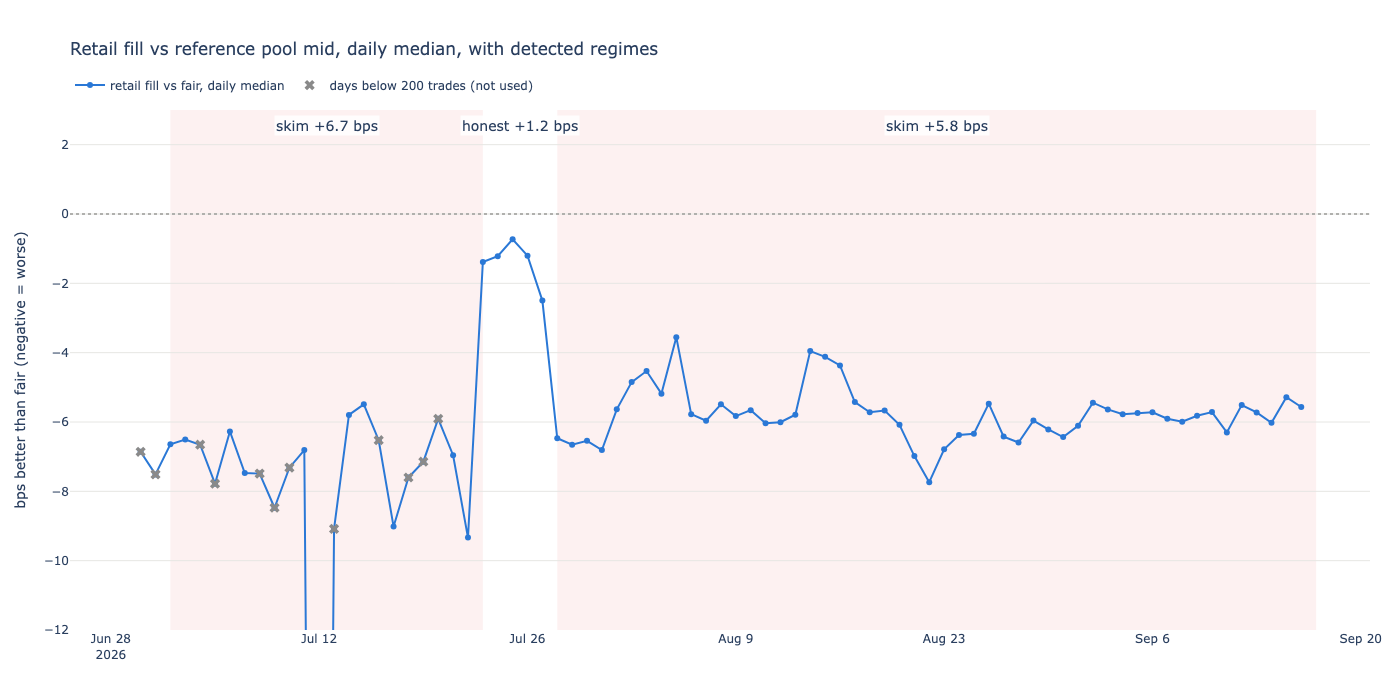

,start,end,trades,retail_share,bot_share,weth_share,median_trade_usd,retail_fill_vs_fair_p50,quote_vs_fair_p50,label,okx share of retail,kyberswap share of retail,0x share of retail,lifi share of retail
regime,,,,,,,,,,,,,,
0,2026-07-02,2026-07-22,"14,624",55%,1%,86%,"$1,549",6.76,-0.84,skim,11%,8%,62%,6%
1,2026-07-23,2026-07-27,"8,681",31%,17%,93%,$168,1.38,0.25,honest,32%,15%,6%,33%
2,2026-07-28,2026-09-16,"192,911",41%,47%,90%,"$1,735",5.96,0.21,skim,40%,17%,1%,15%


In [27]:
fresh = df[df["pair"].isin(MAJORS) & (df["benchmark_age_blocks"] <= 3)].copy()
retail_fresh = fresh[fresh["flow"] == "retail"]
daily_counts = retail_fresh.groupby("day")["fill_vs_benchmark_bps"].size()
daily_median = retail_fresh.groupby("day")["fill_vs_benchmark_bps"].median()

MIN_TRADES_PER_DAY = 200
usable = daily_median[daily_counts >= MIN_TRADES_PER_DAY]
cuts = detect_change_points(usable, min_size=5, min_shift=2.0)
regimes = build_regimes(usable, cuts)
df["regime"] = assign_regime(df["timestamp"], regimes).astype("Int64")
fresh["regime"] = assign_regime(fresh["timestamp"], regimes).astype("Int64")

print(f"{len(daily_median)} days in window, {len(usable)} with >= {MIN_TRADES_PER_DAY} retail trades on the majors, {len(cuts)} change points: {[c.date().isoformat() for c in cuts]}")

sensitivity = []
for threshold in (100, 200, 400):
    u = daily_median[daily_counts >= threshold]
    sensitivity.append({"min trades/day": threshold, "days used": len(u), "change points": ", ".join(c.date().isoformat() for c in detect_change_points(u, 5, 2.0))})
display(pd.DataFrame(sensitivity).style.hide(axis="index"))

fig = go.Figure()
fig.add_scatter(x=daily_median.index, y=-daily_median, mode="lines+markers", name="retail fill vs fair, daily median", line=dict(color=COLOURS["retail"], width=2), marker=dict(size=6))
thin = daily_median[daily_counts < MIN_TRADES_PER_DAY]
fig.add_scatter(x=thin.index, y=-thin, mode="markers", name=f"days below {MIN_TRADES_PER_DAY} trades (not used)", marker=dict(color=COLOURS["unlabelled"], size=9, symbol="x"))
fig.add_hline(y=0, line=dict(color="#b0b0ad", dash="dot"))
add_regime_bands(fig, regimes)
style(fig, "Retail fill vs reference pool mid, daily median, with detected regimes", "", "bps better than fair (negative = worse)")
fig.update_yaxes(range=[-12, 3])
fig.show()

comp = fresh.groupby("regime").agg(
    start=("timestamp", "min"), end=("timestamp", "max"), trades=("tx_hash", "size"),
    retail_share=("flow", lambda s: (s == "retail").mean()), bot_share=("flow", lambda s: (s == "bot").mean()),
    weth_share=("pair", lambda s: s.isin(["WETH/USDC", "USDC/WETH"]).mean()),
    median_trade_usd=("notional_usd", "median"),
    retail_fill_vs_fair_p50=("fill_vs_benchmark_bps", lambda s: s[fresh.loc[s.index, "flow"] == "retail"].median()),
    quote_vs_fair_p50=("quote_vs_benchmark_bps", "median"),
)
comp["label"] = regimes.set_index("regime_id")["label"]
top_aggs = df[df["flow"] == "retail"]["aggregator"].value_counts().index[:4]
for a in top_aggs:
    comp[f"{a} share of retail"] = fresh[fresh["flow"] == "retail"].groupby("regime")["aggregator"].apply(lambda s: (s == a).mean())
display(comp.style.format({"start": "{:%Y-%m-%d}", "end": "{:%Y-%m-%d}", "trades": "{:,}", "retail_share": "{:.0%}", "bot_share": "{:.0%}", "weth_share": "{:.0%}", "median_trade_usd": "${:,.0f}", "retail_fill_vs_fair_p50": "{:.2f}", "quote_vs_fair_p50": "{:.2f}", **{f"{a} share of retail": "{:.0%}" for a in top_aggs}}))

**What this chart shows.** The daily median of retail fills against the reference pool mid on the majors, with the regimes found by change-point detection shaded. Days with fewer than 200 retail trades are marked and excluded from the fit. The first table shows how the boundaries move when that threshold is changed; the second shows what else differed between regimes.

**What the result means.** Three regimes: a skim regime from 2 to 22 July (retail 6.8 bps below fair), an honest regime from 23 to 27 July (1.4 bps), and a skim regime from 28 July to the end of the window (6.0 bps); the band labels on the chart average the daily medians instead of pooling the trades, which is why they read slightly lower. The boundaries are stable at 100, 200 and 400 trades a day. The composition table shows the honest days were unusual in other ways too: median retail trade $168 against about $1,600 elsewhere, 0x's share of retail volume down to 6 %, and bots beginning to appear. A regime found on the outcome cannot say what caused it; the next section tests the keeper independently.

**What it means for retail users.** Five days in July are the only days in the window when a retail user of the majors was filled close to fair on Tessera. The rest of the time the shortfall was five to seven bps, day after day. The honest days are the most useful days in the dataset: they prove the venue can fill retail at its quote, which means that the rest of the time it is choosing not to.

## The main keeper was silent on exactly the honest days

- The regimes above were found on retail outcomes, so keeper behaviour inside them can only co-vary by construction. The independent test: run the same change-point detector on two keeper series that never look at fill quality — the daily share of top-of-block updates carrying the payload offset, and updates per block — and compare the boundary dates
- Boundaries that coincide within a day across independently detected series mean the keeper's state and the fill-quality regime switch together; boundaries that do not coincide are reported as such
- Two updaters write to the price store: the main keeper (selector `0x1667d875`, one wallet, about two updates per block) and a secondary fleet of rotating wallets and selectors. Days on which the main keeper is silent are shown explicitly
- Result: the main keeper's cadence has change points on exactly the same days as the fill-quality regimes. It was silent from 22 July to 27 July — the honest spell — while the secondary fleet kept running; keeper-update patterns switch on the same days as the fill-quality regimes. The payload offset share does not change (it is near 100 % whenever the main keeper is active), so the offset is a property of the main keeper's updates rather than a dial that is turned

Keeper offset-share change points: none
Keeper cadence change points: ['2026-07-23', '2026-07-28']
Days with no main-keeper updates at all: ['2026-07-23', '2026-07-24', '2026-07-25', '2026-07-26']


fill-quality regime boundary,nearest keeper offset boundary,offset Δ days,nearest keeper cadence boundary,cadence Δ days
2026-07-23,—,—,2026-07-23,0
2026-07-28,—,—,2026-07-28,0


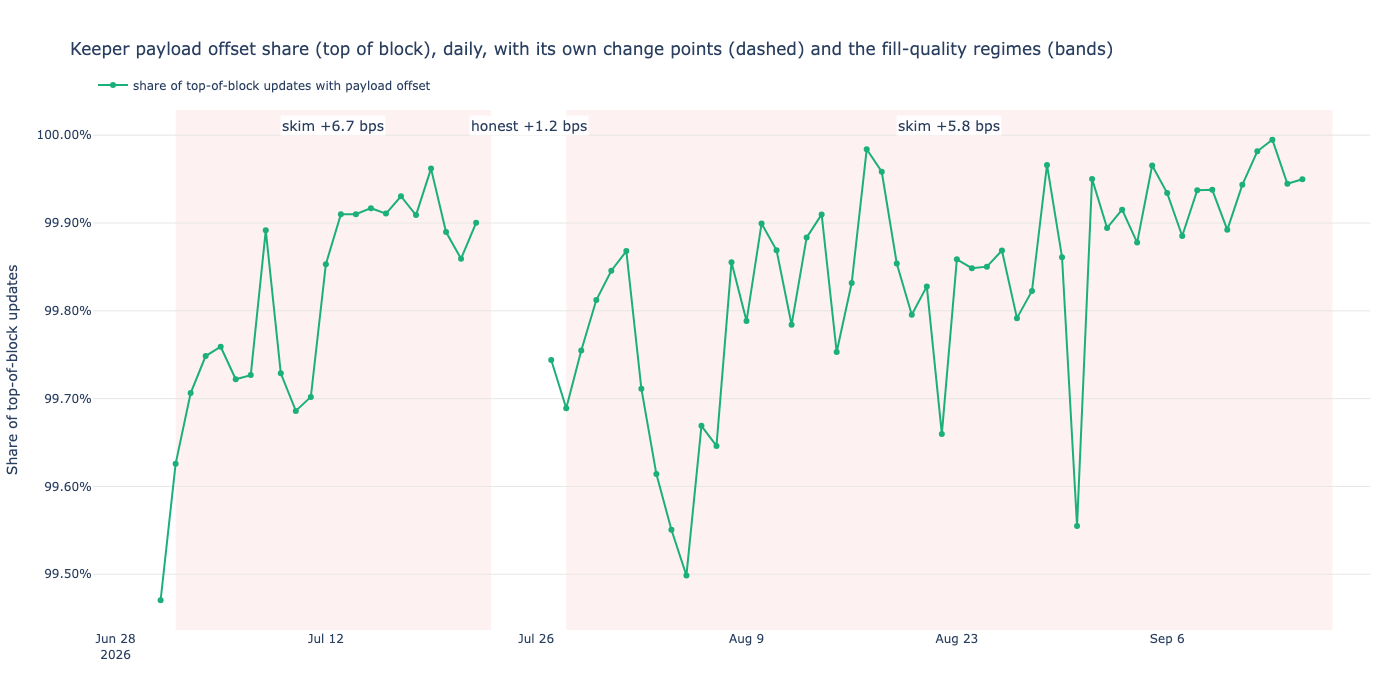

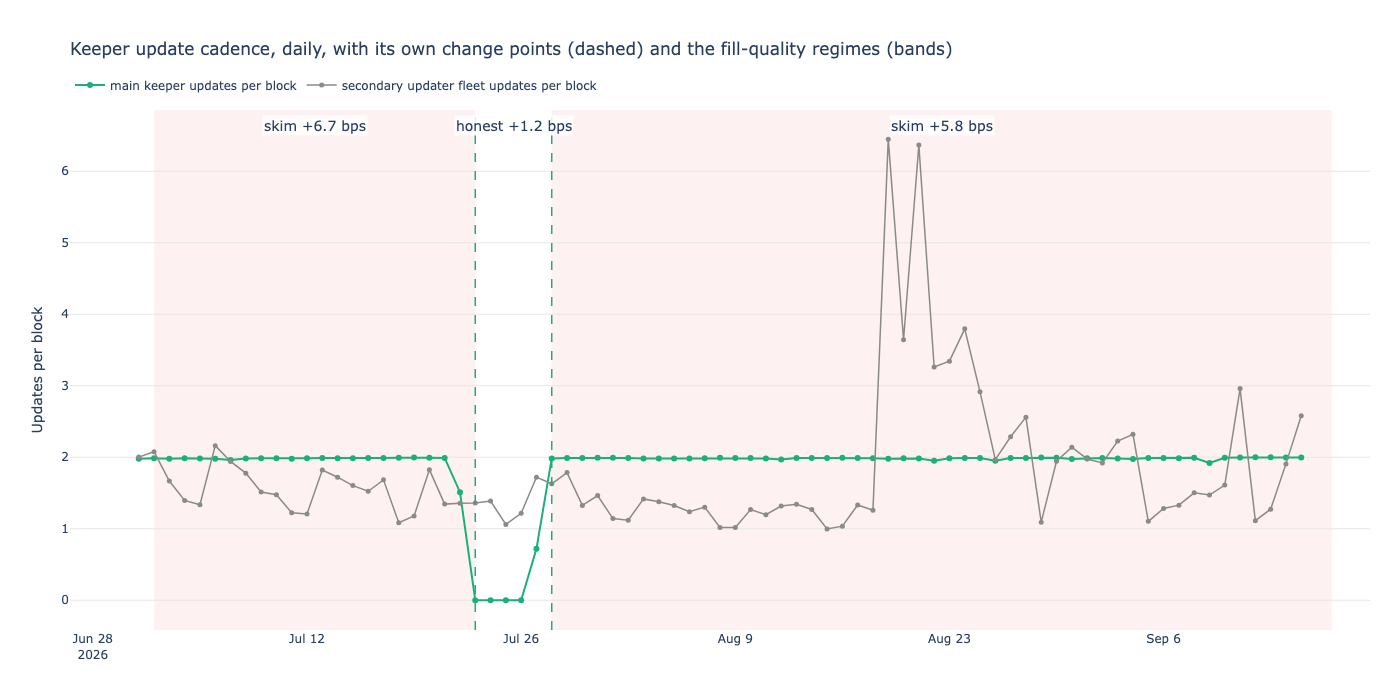

,days,main_keeper_updates_per_block,secondary_updates_per_block,top_offset_share,baseline_values,label
regime,,,,,,
0,21,1.99,1.52,99.9%,1,skim
1,5,0.00,1.36,99.7%,1,honest
2,50,1.99,1.44,99.9%,1,skim


In [28]:
keeper_daily = con.execute("""
    WITH days AS (SELECT date_trunc('day', timestamp) AS day, count(*) AS blocks FROM blocks WHERE block_number >= ? GROUP BY 1),
    u AS (
        SELECT date_trunc('day', timestamp) AS day, rel_gas_position, ('0x' || substr(input, 51, 8))::UBIGINT AS word1
        FROM price_update_analysis
        WHERE selector = '0x1667d875' AND block_number >= ? AND length(input) >= 74 AND rel_gas_position IS NOT NULL
    ),
    m AS (SELECT day, mode(word1) AS baseline FROM u GROUP BY 1),
    agg AS (
        SELECT u.day, count(*) AS updates, any_value(m.baseline) AS baseline,
               avg(CASE WHEN u.rel_gas_position < 0.1 THEN (u.word1 <> m.baseline)::INT END) AS top_offset_share
        FROM u JOIN m ON m.day = u.day GROUP BY u.day
    ),
    other AS (
        SELECT date_trunc('day', timestamp) AS day, count(*) AS other_updates
        FROM price_update_analysis WHERE selector <> '0x1667d875' AND block_number >= ? GROUP BY 1
    )
    SELECT days.day, coalesce(agg.updates, 0) AS updates, coalesce(agg.updates, 0) * 1.0 / days.blocks AS updates_per_block,
           coalesce(other.other_updates, 0) * 1.0 / days.blocks AS other_updates_per_block,
           agg.baseline, agg.top_offset_share
    FROM days LEFT JOIN agg ON agg.day = days.day LEFT JOIN other ON other.day = days.day
    ORDER BY days.day
""", [WINDOW_START_BLOCK, WINDOW_START_BLOCK, WINDOW_START_BLOCK]).df()
keeper_daily["day"] = pd.to_datetime(keeper_daily["day"])
keeper_daily = keeper_daily.set_index("day")
# Drop partial first and last days so cadence is per full day
keeper_daily = keeper_daily.iloc[1:-1]

offset_cuts = detect_change_points(keeper_daily["top_offset_share"].dropna() * 100, min_size=5, min_shift=10.0)
cadence_cuts = detect_change_points(keeper_daily["updates_per_block"], min_size=3, min_shift=0.5)

boundaries = pd.DataFrame({"fill-quality regime boundary": [c.date() for c in cuts]})
def nearest(target, candidates):
    if not candidates:
        return None, None
    d = min(candidates, key=lambda c: abs((c - target).days))
    return d.date(), (d - target).days
boundaries["nearest keeper offset boundary"], boundaries["offset Δ days"] = zip(*[nearest(c, offset_cuts) for c in cuts]) if len(cuts) else ([], [])
boundaries["nearest keeper cadence boundary"], boundaries["cadence Δ days"] = zip(*[nearest(c, cadence_cuts) for c in cuts]) if len(cuts) else ([], [])
print("Keeper offset-share change points:", [c.date().isoformat() for c in offset_cuts] or "none")
print("Keeper cadence change points:", [c.date().isoformat() for c in cadence_cuts] or "none")
silent = keeper_daily[keeper_daily["updates"] == 0].index
print("Days with no main-keeper updates at all:", [d.date().isoformat() for d in silent] or "none")
display(boundaries.style.hide(axis="index").format(na_rep="—"))

fig = go.Figure()
fig.add_scatter(x=keeper_daily.index, y=keeper_daily["top_offset_share"], mode="lines+markers", name="share of top-of-block updates with payload offset", line=dict(color=COLOURS["price update"], width=2), marker=dict(size=6))
for c in offset_cuts:
    fig.add_vline(x=c, line=dict(color=COLOURS["price update"], dash="dash", width=1.5))
add_regime_bands(fig, regimes)
style(fig, "Keeper payload offset share (top of block), daily, with its own change points (dashed) and the fill-quality regimes (bands)", "", "Share of top-of-block updates")
fig.update_yaxes(tickformat=".2%")
fig.show()

fig = go.Figure()
fig.add_scatter(x=keeper_daily.index, y=keeper_daily["updates_per_block"], mode="lines+markers", name="main keeper updates per block", line=dict(color=COLOURS["price update"], width=2), marker=dict(size=6))
fig.add_scatter(x=keeper_daily.index, y=keeper_daily["other_updates_per_block"], mode="lines+markers", name="secondary updater fleet updates per block", line=dict(color=COLOURS["unlabelled"], width=1.5), marker=dict(size=5))
for c in cadence_cuts:
    fig.add_vline(x=c, line=dict(color=COLOURS["price update"], dash="dash", width=1.5))
add_regime_bands(fig, regimes)
style(fig, "Keeper update cadence, daily, with its own change points (dashed) and the fill-quality regimes (bands)", "", "Updates per block").show()

keeper_daily["regime"] = assign_regime(pd.Series(keeper_daily.index, index=keeper_daily.index), regimes).astype("Int64")
display(keeper_daily.groupby("regime").agg(days=("updates", "size"), main_keeper_updates_per_block=("updates_per_block", "median"), secondary_updates_per_block=("other_updates_per_block", "median"), top_offset_share=("top_offset_share", "median"), baseline_values=("baseline", "nunique")).join(regimes.set_index("regime_id")[["label"]]).style.format({"main_keeper_updates_per_block": "{:.2f}", "secondary_updates_per_block": "{:.2f}", "top_offset_share": "{:.1%}"}, na_rep="—"))

**What these charts show.** Two series that never look at fill quality: the share of top-of-block updates carrying the payload offset, and the number of updates per block written by the main keeper (one wallet, selector `0x1667d875`) and by the secondary updater fleet. Each has its own change points (dashed lines) detected independently, drawn over the fill-quality regimes (bands) for comparison.

**What the result means.** The main keeper's cadence has change points on 23 July and 28 July, zero days from the fill-quality boundaries. It wrote nothing at all from midday 22 July to midday 27 July, the honest spell; the secondary fleet kept running at its usual 1.4 updates per block. The payload offset share shows no change points because it is near 100 % whenever the main keeper is active; the offset is a property of the main keeper's updates, not a dial that is turned. Keeper-update patterns switch on the same days as the fill-quality regimes.

**What it means for retail users.** This is the strongest evidence in the notebook. Two series, one built from the venue's keeper transactions and one from retail fill quality, found the same five days independently. When the venue's main keeper stopped writing, retail was filled at fair; when it resumed, the six-bp shortfall resumed with it. The shortfall is produced by that keeper's activity, and its absence is sufficient to remove the shortfall.

## At the same block position, one prior keeper update still costs five bps

- The number of keeper updates before a fill is largely a function of where in the block the fill lands, and late-block execution, gas competition, size and aggregator mix can all move fill quality on their own
- So the comparison is made *within* narrow position bins: at the same position, is a retail fill with exactly one prior update worse than one with none, or with two (refresh landed)?
- Cells with fewer than 200 trades are suppressed; shown per regime. Bars for zero prior updates sit at zero bps and are therefore invisible: at the same position in the block, a fill with no keeper update before it is filled at the quote

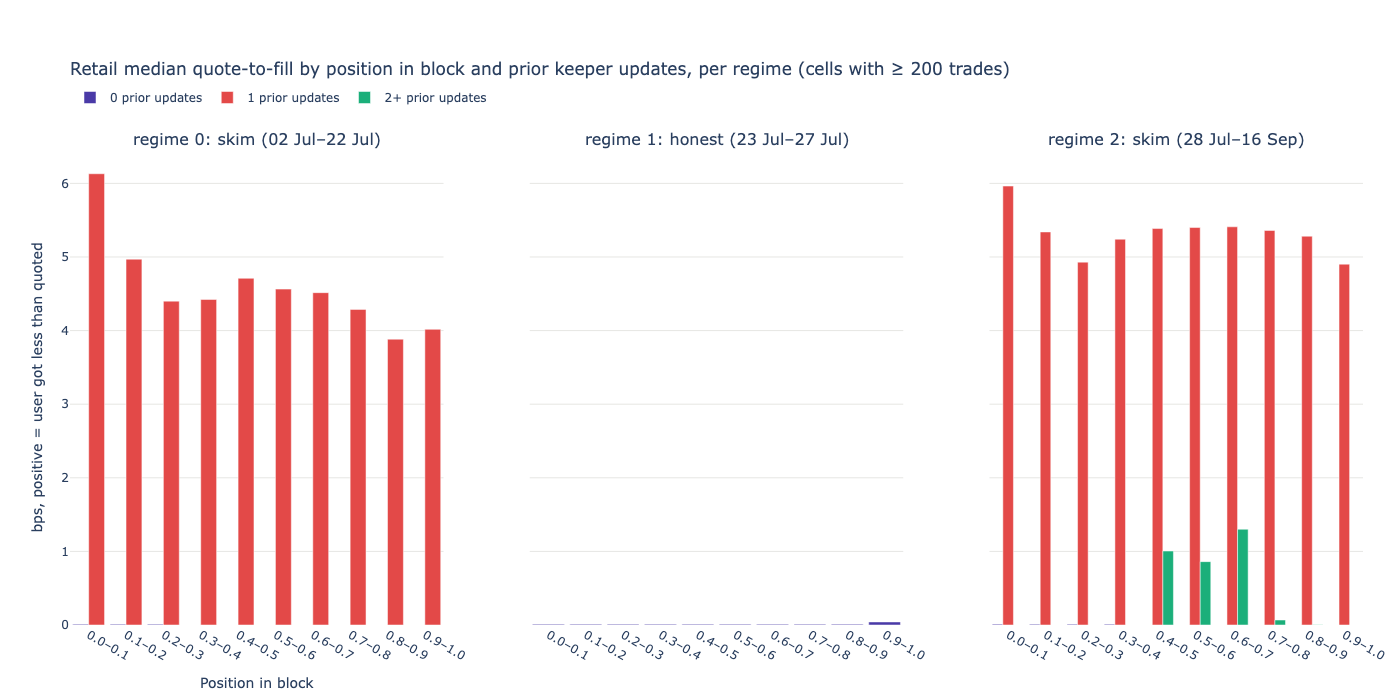

In [29]:
retail = df[(df["flow"] == "retail") & df["updates_before"].notna()].copy()
retail["position_bin"] = pd.cut(retail["rel_gas_position"], bins=np.linspace(0, 1, 11), labels=[f"{i/10:.1f}–{(i+1)/10:.1f}" for i in range(10)], include_lowest=True)
retail["updates_before_bucket"] = pd.cut(retail["updates_before"], bins=[-1, 0, 1, np.inf], labels=["0", "1", "2+"])
cells = retail.groupby(["regime", "position_bin", "updates_before_bucket"], observed=True)["quote_to_fill_bps"].agg(n="size", p50="median").reset_index()
cells = cells[cells["n"] >= 200]
cells["regime_label"] = cells["regime"].map(regimes.set_index("regime_id")["label"])

fig = make_subplots(rows=1, cols=len(regimes), shared_yaxes=True, subplot_titles=[f"regime {int(r.regime_id)}: {r.label} ({r.start:%d %b}–{r.end:%d %b})" for r in regimes.itertuples()])
bucket_colours = {"0": COLOURS["quote"], "1": COLOURS["fill"], "2+": COLOURS["price update"]}
shown = set()
for col, r in enumerate(regimes.itertuples(), start=1):
    sub = cells[cells["regime"] == r.regime_id]
    for bucket, colour in bucket_colours.items():
        b = sub[sub["updates_before_bucket"] == bucket]
        if b.empty:
            continue
        fig.add_bar(x=b["position_bin"].astype(str), y=b["p50"], name=f"{bucket} prior updates", marker_color=colour, showlegend=bucket not in shown, row=1, col=col)
        shown.add(bucket)
fig.update_layout(barmode="group")
style(fig, "Retail median quote-to-fill by position in block and prior keeper updates, per regime (cells with ≥ 200 trades)", "Position in block", "bps, positive = user got less than quoted")
fig.update_layout(legend=dict(y=1.08), margin=dict(t=150))
fig.show()

pivot = cells.pivot_table(index=["regime_label", "position_bin"], columns="updates_before_bucket", values="p50", observed=True)
display(pivot.style.format("{:.2f}", na_rep="—"))

**What this chart shows.** The prior-update comparison again, but controlled for position in the block: within each tenth of the block, retail fills with zero, one and two or more keeper updates before them, per regime. Cells with fewer than 200 trades are suppressed. Bars at zero bps are invisible.

**What the result means.** At the same position in the block, a retail fill after no keeper update is filled at the quote, and a fill after exactly one update is filled four to six bps worse, in every position bin and in both skim regimes. After two updates the fill is back near the quote. In the honest regime, with the main keeper silent, every cell is at the quote. Position in the block therefore does not explain the degradation on its own; the keeper's first write in the block does.

**What it means for retail users.** This closes the alternative explanations. It is not late-block gas competition, not trade size, not aggregator mix and not position by itself: two retail fills at the same point in the block differ by five bps depending only on whether the venue's keeper has written its top-of-block update before them. Almost every retail fill lands after it.

## The price does not move after retail or bot fills

- For every fill on the majors we compare the fill price with the reference pool mid 5, 30 and 150 blocks later (10 s, 1 min, 5 min). The baseline is the trade's own fill price, so there is no look-ahead; the horizon price must come from a swap no older than half the horizon or the observation is dropped
- Two measures, both signed so that positive means the price subsequently moved in the trader's favour: the *markout* compares the horizon mid with the fill price (so it contains the fill shortfall), the *drift* compares the horizon mid with the mid before the trade (the information content of the flow, free of the fill)
- The question this answers: is the flow being charged the skim the kind of flow that predicts price moves?
- Result: the mid does not drift after either flow (both within about half a bp at every horizon, bots slightly negative). Retail's negative markout is the fill shortfall itself and does not grow with the horizon. Under this definition, neither retail nor bot fills are followed by favourable price moves, so an adverse-selection justification for the spread is not visible in the flow being charged

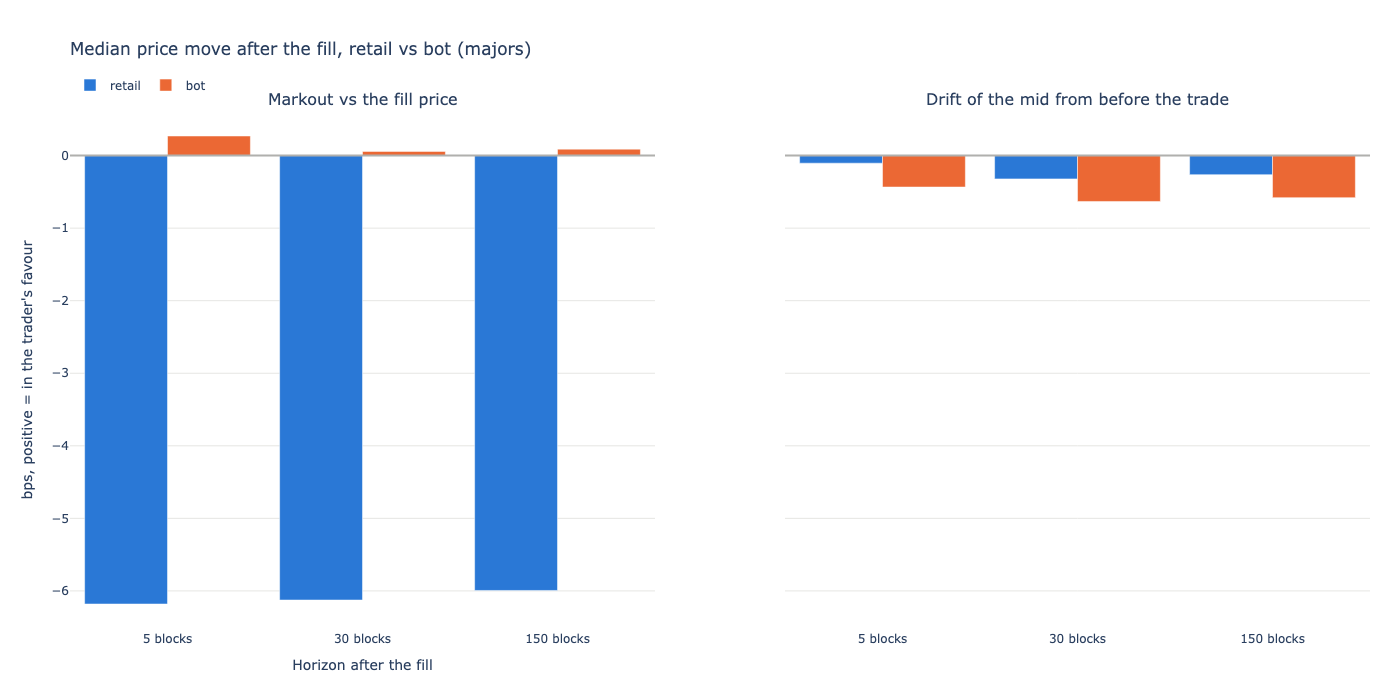

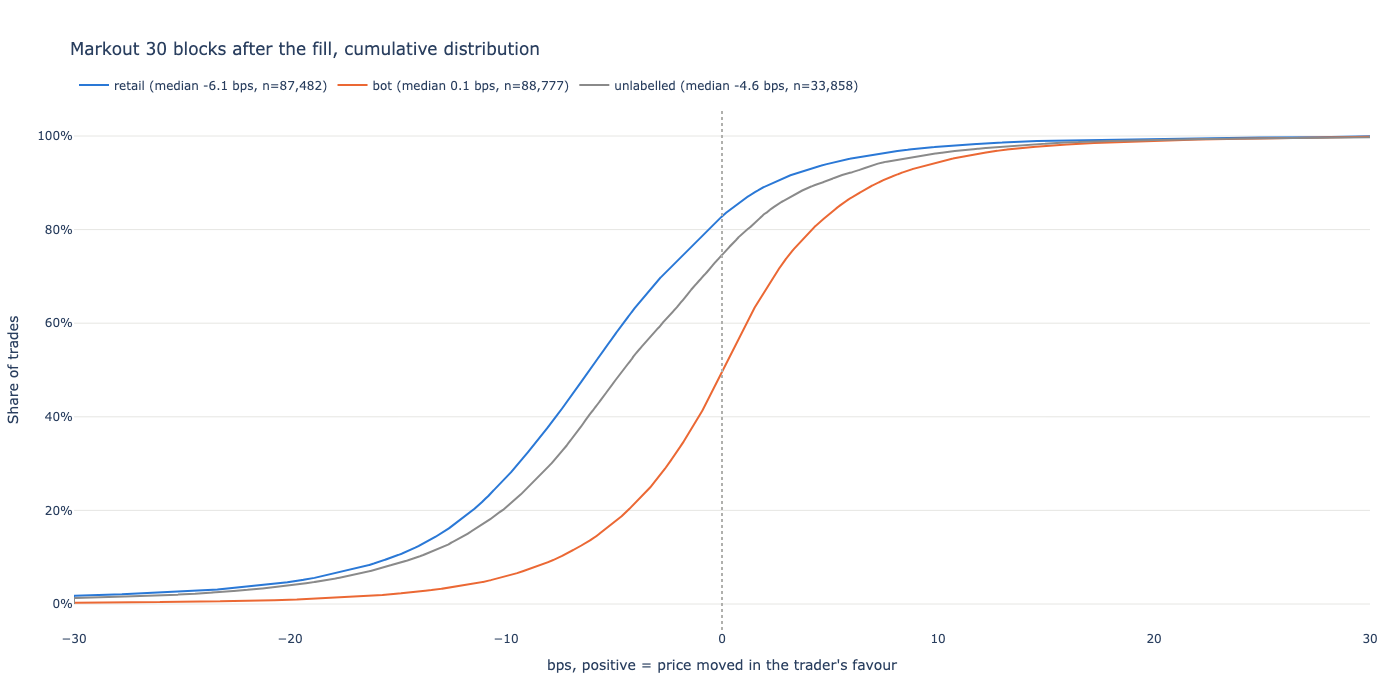

,n at 5 blocks,n at 30 blocks,n at 150 blocks,median at 5 blocks,median at 30 blocks,median at 150 blocks,label
regime,,,,,,,
0,"6,278","7,867","8,037",-6.80,-6.79,-7.04,skim
1,"1,723","2,528","2,645",-1.72,-1.98,-2.11,honest
2,"63,565","76,895","78,959",-6.20,-6.20,-6.05,skim


In [30]:
HORIZONS = [5, 30, 150]
base = con.execute("""
    SELECT tx_hash, log_index, block_number, pool, sells_token0, fill_price_t1_per_t0, benchmark_price AS pre_trade_mid
    FROM trade_vs_benchmark
    WHERE venue = 'tessera' AND block_number >= ? AND benchmark_age_blocks <= 3
      AND symbol_in || '/' || symbol_out IN ('WETH/USDC', 'USDC/WETH', 'cbBTC/USDC', 'USDC/cbBTC')
""", [WINDOW_START_BLOCK]).df()
prices = con.execute("""
    SELECT pool, block_number AS price_block, price AS horizon_price FROM benchmark_block_prices
    WHERE block_number >= ? AND pool IN (SELECT DISTINCT pool FROM trade_benchmarks) ORDER BY price_block
""", [WINDOW_START_BLOCK - 1000]).df()

# DuckDB 1.5 hangs when materialising an ASOF join with a full projection, so the "last price at or before the horizon" lookup is done in pandas
markout_frames = []
for h in HORIZONS:
    left = base.assign(target=base["block_number"] + h).sort_values("target")
    m = pd.merge_asof(left, prices, left_on="target", right_on="price_block", by="pool", direction="backward")
    m["age"] = m["target"] - m["price_block"]
    m = m[m["age"] <= h / 2]
    direction = np.where(m["sells_token0"], -1.0, 1.0)
    m["markout_bps"] = direction * (m["horizon_price"] - m["fill_price_t1_per_t0"]) / m["fill_price_t1_per_t0"] * 1e4
    # Drift of the mid itself from before the trade to the horizon: the information content of the flow, free of the fill shortfall
    m["drift_bps"] = direction * (m["horizon_price"] - m["pre_trade_mid"]) / m["pre_trade_mid"] * 1e4
    m["horizon"] = h
    markout_frames.append(m[["tx_hash", "log_index", "horizon", "markout_bps", "drift_bps"]])
markouts = pd.concat(markout_frames).merge(df[["tx_hash", "log_index", "flow", "regime"]], on=["tx_hash", "log_index"], how="left")

by_h = markouts.groupby(["horizon", "flow"]).agg(n=("markout_bps", "size"), markout_median=("markout_bps", "median"), markout_mean=("markout_bps", "mean"), drift_median=("drift_bps", "median"), drift_mean=("drift_bps", "mean")).reset_index()
fig = make_subplots(rows=1, cols=2, shared_yaxes=True, subplot_titles=["Markout vs the fill price", "Drift of the mid from before the trade"])
for flow in ["retail", "bot"]:
    sub = by_h[by_h["flow"] == flow]
    fig.add_bar(x=[f"{h} blocks" for h in sub["horizon"]], y=sub["markout_median"], name=f"{flow}", marker_color=COLOURS[flow], row=1, col=1)
    fig.add_bar(x=[f"{h} blocks" for h in sub["horizon"]], y=sub["drift_median"], name=f"{flow}", marker_color=COLOURS[flow], showlegend=False, row=1, col=2)
fig.update_layout(barmode="group")
fig.add_hline(y=0, line=dict(color="#b0b0ad"))
style(fig, "Median price move after the fill, retail vs bot (majors)", "Horizon after the fill", "bps, positive = in the trader's favour").show()
display(by_h.set_index(["horizon", "flow"]).style.format({"n": "{:,.0f}", "markout_median": "{:.2f}", "markout_mean": "{:.2f}", "drift_median": "{:.2f}", "drift_mean": "{:.2f}"}))

fig = go.Figure()
for flow in FLOW_ORDER:
    s = markouts.loc[(markouts["horizon"] == 30) & (markouts["flow"] == flow), "markout_bps"].dropna().clip(-30, 30).sort_values()
    if len(s):
        fig.add_scatter(x=s.values, y=np.linspace(0, 1, len(s)), mode="lines", name=f"{flow} (median {s.median():.1f} bps, n={len(s):,})", line=dict(color=COLOURS[flow], width=2))
fig.add_vline(x=0, line=dict(color="#b0b0ad", dash="dot"))
style(fig, "Markout 30 blocks after the fill, cumulative distribution", "bps, positive = price moved in the trader's favour", "Share of trades")
fig.update_yaxes(tickformat=".0%")
fig.show()

by_regime = markouts[markouts["flow"] == "retail"].groupby(["regime", "horizon"])["markout_bps"].agg(n="size", median="median").reset_index()
by_regime_table = by_regime.pivot(index="regime", columns="horizon", values=["n", "median"])
by_regime_table.columns = [f"{stat} at {h} blocks" for stat, h in by_regime_table.columns]
display(by_regime_table.join(regimes.set_index("regime_id")[["label"]]).style.format({c: "{:,.0f}" if c.startswith("n ") else "{:.2f}" for c in by_regime_table.columns}))

**What these charts show.** What the market did after each fill on the majors, at 10 seconds, one minute and five minutes. The markout compares the horizon mid with the fill price, so it includes the fill shortfall; the drift compares the horizon mid with the mid before the trade, isolating whether the flow predicted anything. Positive is in the trader's favour. Horizon prices older than half the horizon are dropped.

**What the result means.** The mid does not drift after either flow: retail −0.1 to −0.3 bps, bots −0.4 to −0.6 bps, at every horizon. Retail's markout is −6.1 bps at 10 seconds and −6.0 bps at five minutes: it is the fill shortfall and nothing else, and it does not grow. In the honest regime retail's markout shrinks to about −2 bps with the same flat drift. Under this definition neither retail nor bot fills are followed by favourable price moves; bots are not informed, they capture the quote.

**What it means for retail users.** The standard defence of a wide spread is that it compensates the market maker for trading against informed flow that moves the price against it. Retail flow on Tessera does not move the price at all. The six bps is not insurance against what retail knows; retail knows nothing the price does not already reflect. It is a charge on flow that carries no information, and the venue's own fills to bots show it does not need the charge to trade profitably against informed counterparties either.

## Retail shortfall and bot gain against fair, per day and regime

- Per day: how much retail flow received less than the reference mid, and how much bot flow received more, in USD on the majors
- These are two attributions against a common benchmark, not two sides of a transfer: the trades are not matched, bot gains can come from timing and inventory unrelated to retail's shortfall, and the benchmark omits the pool's fee and impact. The two lines are not additive and nothing here is a venue P&L
- Whether bot gains rise when the skim is off is worth knowing either way: it is the observation a venue would cite to justify the skim

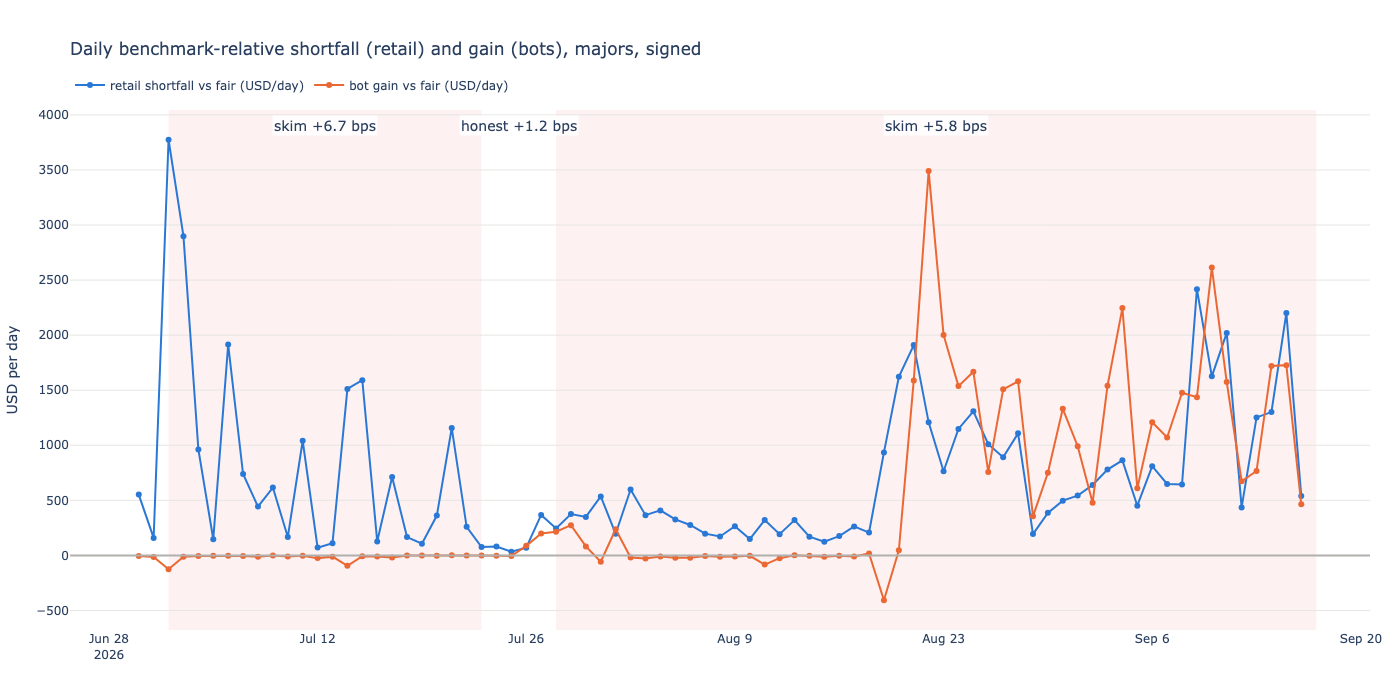

regime,regime_label,flow,trades,notional_usd,signed_shortfall_usd,gross_shortfall_usd,days,signed_shortfall_per_day
0,skim,bot,143,"$439,198",$354,$356,10,$35
0,skim,retail,"8,079","$29,661,128","$18,879","$19,073",10,"$1,888"
1,honest,bot,"1,448","$3,227,701",$-276,$159,5,$-55
1,honest,retail,"2,672","$2,753,825",$629,$698,5,$126
2,skim,bot,"90,010","$381,093,223","$-37,313","$14,900",51,$-732
2,skim,retail,"79,658","$76,490,479","$36,393","$38,523",51,$714


Retail shortfall vs fair on the majors: $56,611. For comparison, retail shortfall vs Tessera's own quote on all pairs (earlier section): $96,868. The two differ because the baselines differ (pool mid vs Tessera's end-of-previous-block quote) and the pair sets differ.


In [31]:
fresh["shortfall_usd"] = fresh["fill_vs_benchmark_bps"] / 1e4 * fresh["notional_usd"]
ledger = fresh.pivot_table(index="day", columns="flow", values="shortfall_usd", aggfunc="sum").fillna(0)
ledger["retail shortfall"] = ledger.get("retail", 0)
ledger["bot gain"] = -ledger.get("bot", 0)

fig = go.Figure()
fig.add_scatter(x=ledger.index, y=ledger["retail shortfall"], mode="lines+markers", name="retail shortfall vs fair (USD/day)", line=dict(color=COLOURS["retail"], width=2), marker=dict(size=6))
fig.add_scatter(x=ledger.index, y=ledger["bot gain"], mode="lines+markers", name="bot gain vs fair (USD/day)", line=dict(color=COLOURS["bot"], width=2), marker=dict(size=6))
fig.add_hline(y=0, line=dict(color="#b0b0ad"))
add_regime_bands(fig, regimes)
style(fig, "Daily benchmark-relative shortfall (retail) and gain (bots), majors, signed", "", "USD per day").show()

fresh["regime_label"] = fresh["regime"].map(regimes.set_index("regime_id")["label"])
per_regime = fresh.groupby(["regime", "regime_label", "flow"]).agg(trades=("tx_hash", "size"), notional_usd=("notional_usd", "sum"), signed_shortfall_usd=("shortfall_usd", "sum"), gross_shortfall_usd=("shortfall_usd", lambda s: s[s > 0].sum())).reset_index()
per_regime["days"] = per_regime["regime"].map(regimes.set_index("regime_id")["days"])
per_regime["signed_shortfall_per_day"] = per_regime["signed_shortfall_usd"] / per_regime["days"]
display(per_regime[per_regime["flow"].isin(["retail", "bot"])].style.format({"trades": "{:,}", "notional_usd": "${:,.0f}", "signed_shortfall_usd": "${:,.0f}", "gross_shortfall_usd": "${:,.0f}", "signed_shortfall_per_day": "${:,.0f}"}).hide(axis="index"))
print(f"Retail shortfall vs fair on the majors: ${ledger['retail shortfall'].sum():,.0f}. "
      f"For comparison, retail shortfall vs Tessera's own quote on all pairs (earlier section): ${df.loc[df['flow'] == 'retail', 'extracted_usd'].sum():,.0f}. "
      "The two differ because the baselines differ (pool mid vs Tessera's end-of-previous-block quote) and the pair sets differ.")

**What this chart shows.** Per day on the majors, how much retail flow received less than the reference mid and how much bot flow received more, in dollars, with the regimes shaded. The two lines are attributions against a common benchmark and are not additive: the trades are not matched, bots' gains can come from timing and inventory unrelated to retail's shortfall, and the benchmark omits the pool's fee and impact. Nothing here is a venue P&L.

**What the result means.** Retail's shortfall against fair on the majors is $56k over the window; bots' gain is $37k, nearly all of it after 17 August when the bot fleet arrived. During the honest regime retail's shortfall was $126 a day against $714 to $1,888 a day in the skim regimes, and bots were slightly behind fair. Bot gains did not rise when the skim was off, so the data does not support the justification that the skim exists to fund losses to bots picking off the tight quote.

**What it means for retail users.** The money retail leaves on the table does not simply flow to bots. Bot gains on the same benchmark come to about two thirds of retail's shortfall and nearly all of them arrive after 17 August; the remaining third, and the whole of the July shortfall, is matched by no bot gain and stays with the venue on this benchmark. During the five honest days retail lost almost nothing and bots gained almost nothing, which is what a venue quoting at fair to everybody looks like. That is the counterfactual retail users are paying the difference against.

## 0x and KyberSwap users were protected, users of the others were not

- Tessera-only data cannot show routing decisions: less Tessera volume from an aggregator can mean less routing, less user demand, market-wide volume, a different pair mix or label coverage
- What it can show is each aggregator's observed Tessera activity and fill quality per regime, normalised by that aggregator's own window average, next to total Tessera volume as a market-wide control
- Two things stand out in the weekly view: 0x's Tessera flow on the majors collapses in early July and its residual fills move from about six bps below fair to near fair by mid-August, consistent with its public statement that it monitors and cuts propAMM sources; KyberSwap flow fills near fair throughout. Whether either reflects routing decisions or user demand cannot be told from Tessera's side alone

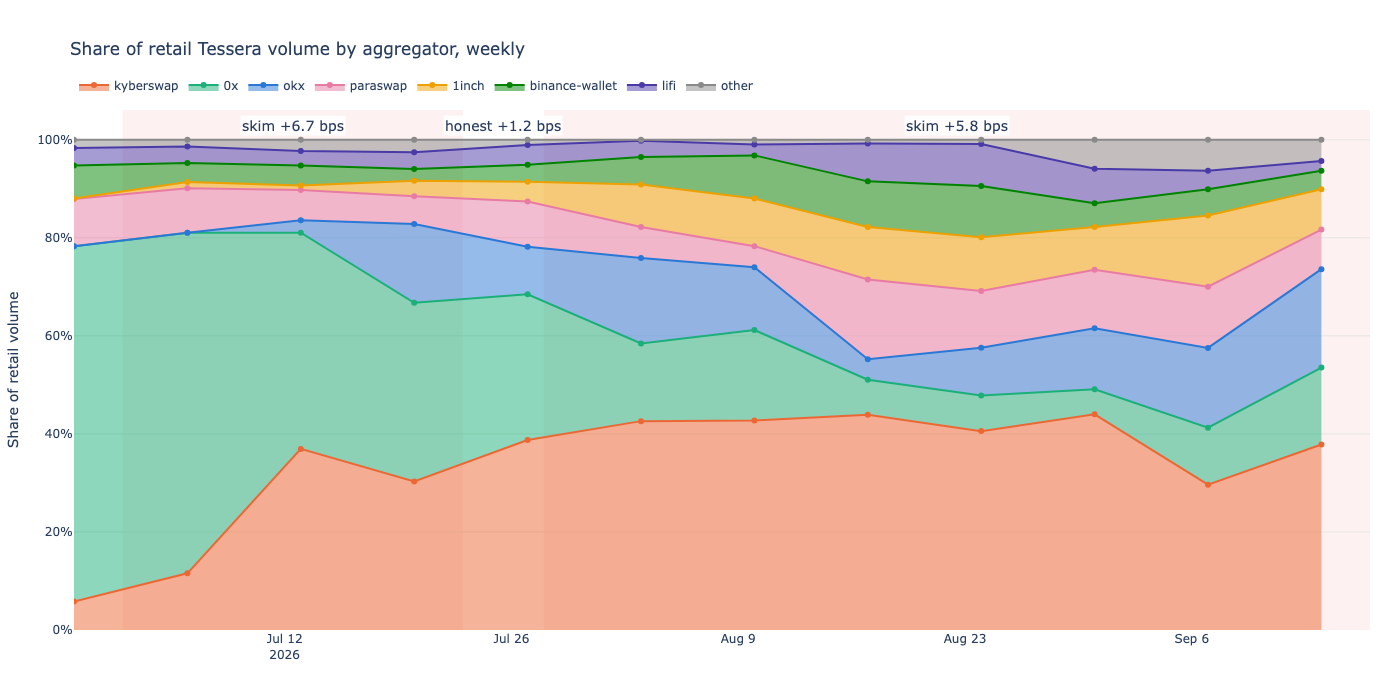

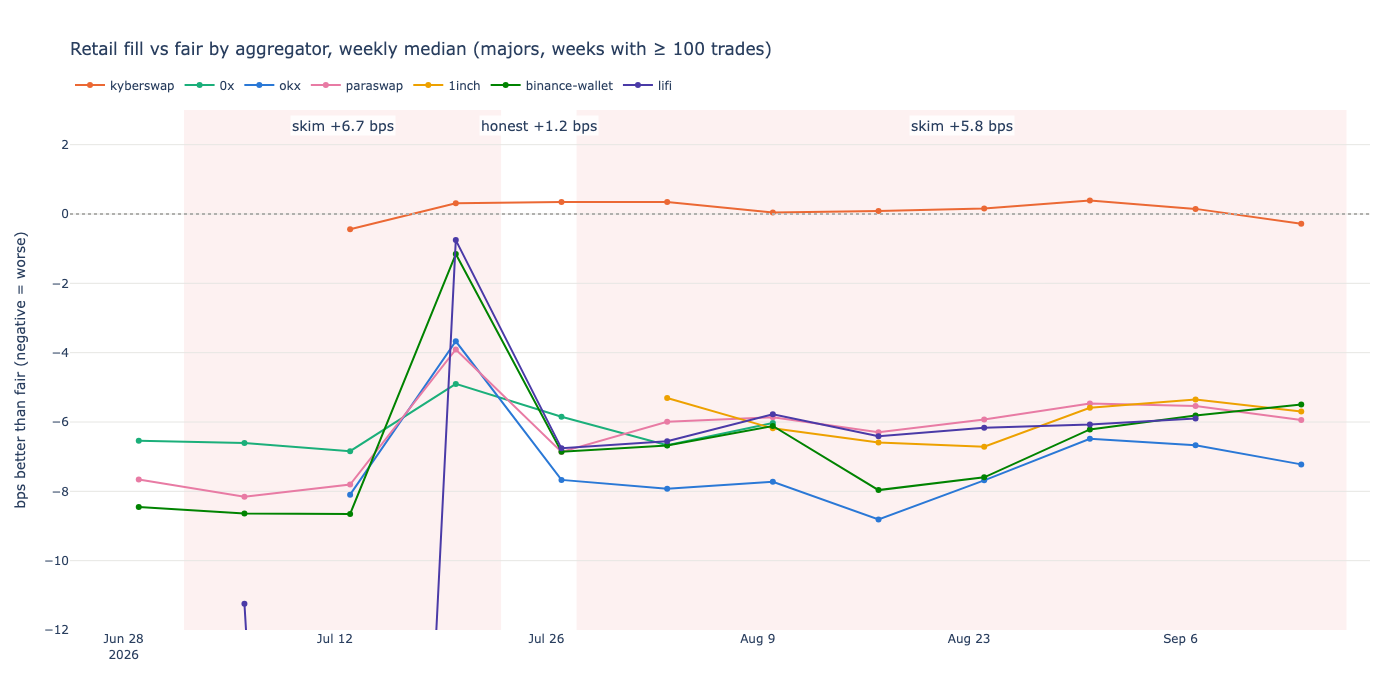

,regime 0 (skim),regime 1 (honest),regime 2 (skim)
aggregator_group,,,
0x,2.10×,0.63×,0.26×
1inch,0.47×,0.20×,2.33×
binance-wallet,1.23×,0.43×,1.34×
kyberswap,1.04×,0.69×,1.28×
lifi,1.02×,0.69×,1.29×
okx,0.64×,0.97×,1.39×
other,1.00×,0.93×,1.07×
paraswap,1.27×,0.47×,1.27×
all retail (control),1.43×,0.64×,0.92×


Cells with fewer than 100 trades are shown as —.


,"fill vs fair, regime 0","fill vs fair, regime 1","fill vs fair, regime 2"
aggregator,,,
0x,6.62,1.14,6.07
1inch,—,—,5.92
binance-wallet,8.65,1.00,6.73
kyberswap,0.35,-0.22,-0.17
lifi,54.03,0.87,6.23
okx,7.47,2.68,7.64
paraswap,7.90,2.55,5.91


In [32]:
retail_all = df[(df["flow"] == "retail") & df["notional_usd"].notna()].copy()
retail_all["week"] = retail_all["timestamp"].dt.to_period("W").dt.start_time
top_aggs = retail_all.groupby("aggregator")["notional_usd"].sum().sort_values(ascending=False).index[:7]
retail_all["aggregator_group"] = np.where(retail_all["aggregator"].isin(top_aggs), retail_all["aggregator"], "other")

weekly = retail_all.pivot_table(index="week", columns="aggregator_group", values="notional_usd", aggfunc="sum").fillna(0)
share = weekly.div(weekly.sum(axis=1), axis=0)
fig = go.Figure()
for name in list(top_aggs) + ["other"]:
    if name in share:
        fig.add_scatter(x=share.index, y=share[name], mode="lines+markers", name=name, line=dict(color=AGGREGATOR_COLOURS.get(name, "#8a8a8a"), width=2), marker=dict(size=6), stackgroup="one")
add_regime_bands(fig, regimes)
style(fig, "Share of retail Tessera volume by aggregator, weekly", "", "Share of retail volume")
fig.update_yaxes(tickformat=".0%")
fig.show()

fresh_retail = fresh[fresh["flow"] == "retail"].copy()
fresh_retail["week"] = fresh_retail["timestamp"].dt.to_period("W").dt.start_time
wq = fresh_retail[fresh_retail["aggregator"].isin(top_aggs)].groupby(["week", "aggregator"])["fill_vs_benchmark_bps"].agg(n="size", p50="median").reset_index()
wq = wq[wq["n"] >= 100]
fig = go.Figure()
for name in top_aggs:
    sub = wq[wq["aggregator"] == name]
    fig.add_scatter(x=sub["week"], y=-sub["p50"], mode="lines+markers", name=name, line=dict(color=AGGREGATOR_COLOURS.get(name, "#8a8a8a"), width=2), marker=dict(size=6))
fig.add_hline(y=0, line=dict(color="#b0b0ad", dash="dot"))
add_regime_bands(fig, regimes)
style(fig, "Retail fill vs fair by aggregator, weekly median (majors, weeks with ≥ 100 trades)", "", "bps better than fair (negative = worse)")
fig.update_yaxes(range=[-12, 3])
fig.show()

regime_days = regimes.set_index("regime_id")["days"]
vol = retail_all.groupby(["aggregator_group", "regime"])["notional_usd"].sum().unstack("regime").fillna(0)
vol_per_day = vol.div(regime_days, axis=1)
normalised = vol_per_day.div(vol_per_day.mean(axis=1), axis=0)
normalised.columns = [f"regime {int(c)} ({regimes.set_index('regime_id').loc[c, 'label']})" for c in normalised.columns]
total = retail_all.groupby("regime")["notional_usd"].sum() / regime_days
normalised.loc["all retail (control)"] = (total / total.mean()).values
fq_stats = fresh_retail.groupby(["aggregator", "regime"])["fill_vs_benchmark_bps"].agg(n="size", p50="median").reset_index()
fq_stats.loc[fq_stats["n"] < 100, "p50"] = np.nan
fq = fq_stats.pivot(index="aggregator", columns="regime", values="p50")
fq.columns = [f"fill vs fair, regime {int(c)}" for c in fq.columns]
display(normalised.style.format("{:.2f}×"))
print("Cells with fewer than 100 trades are shown as —.")
display(fq.loc[fq.index.isin(top_aggs)].style.format("{:.2f}", na_rep="—"))

**What these charts show.** Weekly share of retail Tessera volume by aggregator, and each aggregator's weekly median fill against fair on the majors, both with the regimes shaded. The tables normalise each aggregator's Tessera volume per day by its own window average per regime, next to total retail volume as a market-wide control, and give each aggregator's fill vs fair per regime.

**What the result means.** 0x's Tessera volume collapsed across the window (2.1× its average in early July, 0.26× by the last regime) while its residual fills moved from six bps below fair to near fair; KyberSwap's fills stayed within a quarter of a basis point of fair in every regime. OKX, 1inch, Paraswap, LI.FI and Binance Wallet kept routing and kept being filled six bps or more below fair in both skim regimes. In the honest regime every aggregator's fills were within about a basis point of fair. Tessera-only data cannot say whether 0x chose to route elsewhere or its users left; it can say its observed Tessera activity fell and its fill quality improved.

**What it means for retail users.** The aggregators differ in whether they notice. 0x's and KyberSwap's users were protected, by fill-quality monitoring or by routing changes we cannot see from here; users of the others were charged the same six bps in the skim regimes as they had been since July. When an aggregator advertises a better quote, the useful question is whether it checks that its users receive it, and this chart is the only place a user could find the answer.

## Cents per casual user, thousands for the most active

- From aggregate dollars to per-user impact, named precisely: *estimated Tessera-leg shortfall by recipient key*. The shortfall is against Tessera's reconstructed previous-block quote (not necessarily the price the user saw) for one leg of a possibly multi-hop route; the fair-value variant excludes the pool's fee and impact
- The recipient key is the router order's recipient when a trace decoded one (smart wallets and relayed orders), otherwise the transaction sender; key coverage is reported
- "Affected" means a positive net shortfall vs quote. Addresses are truncated; this is aggregate research

68,469 recipient keys ({'transaction sender': 0.65, 'order recipient': 0.35}); 61,525 affected (90%), 5% net zero, 5% net negative; 61% of keys traded once. Median affected key: $0.03 over a median of 1 trade(s).
Keys with at least $100 traded: 29,487 (48% of affected keys); median shortfall $0.30 over 2 trades; the rest are dust trades.


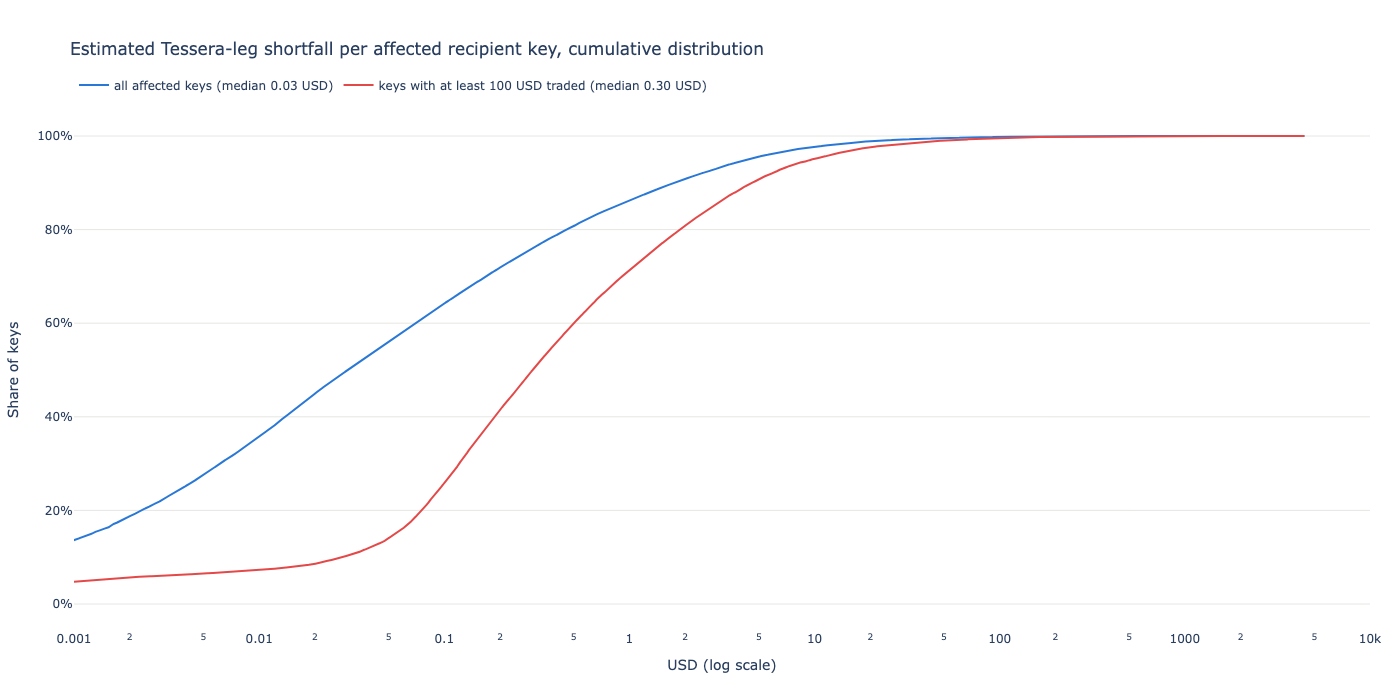

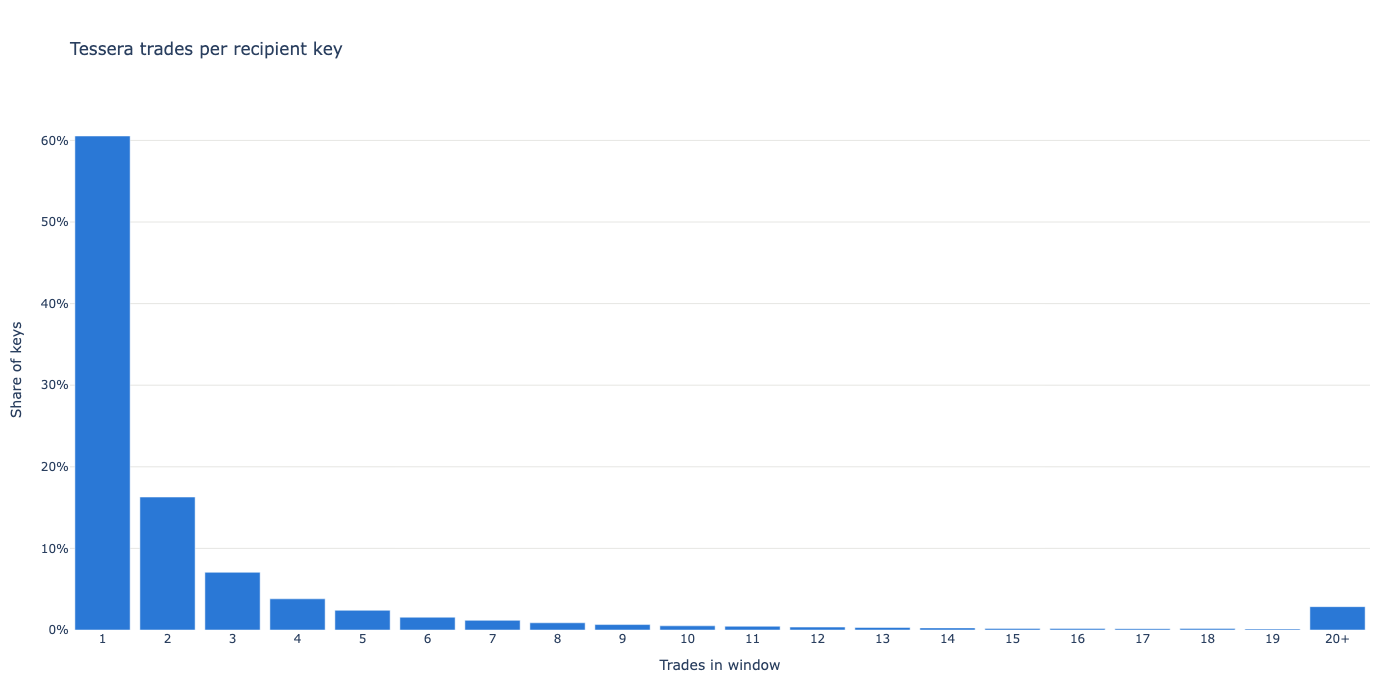

Top 1% of affected keys carry 59% of the shortfall, top 10% carry 91%.


,trades,notional_usd,shortfall_vs_quote_usd,shortfall_vs_fair_usd,first_seen,last_seen
0xf70d…dbEF,"4,486","$7,339,803","$4,422","$3,692",2026-06-30,2026-09-16
0x6008…B6d1,55,"$3,236,929","$1,605","$1,736",2026-06-30,2026-09-07
0x55b6…AC4f,706,"$2,113,194","$1,444","$1,421",2026-07-17,2026-08-18
0x7378…1ca6,19,"$1,792,136","$1,159","$2,133",2026-09-09,2026-09-09
0xa2e2…fe57,752,"$2,044,334","$1,121","$1,639",2026-06-30,2026-09-16
0x7AA5…9d8F,69,"$1,581,260",$939,"$1,051",2026-08-07,2026-09-11
0x0d1D…51fd,30,"$1,206,097",$835,$950,2026-07-16,2026-08-17
0x4F79…8118,111,"$1,175,920",$825,"$1,017",2026-06-30,2026-09-15
0xfEf7…71E3,10,"$1,380,667",$780,"$1,134",2026-07-04,2026-08-15
0x048e…cEF5,"3,876","$1,644,729",$707,"$1,252",2026-06-30,2026-09-16


In [33]:
recipients = con.execute("""
    SELECT tx_hash, any_value(order_recipient) AS order_recipient FROM trade_orders WHERE order_recipient IS NOT NULL GROUP BY 1
""").df()
known_contracts = {a.lower() for (a,) in con.execute("SELECT address FROM router_labels").fetchall()} | {"0x0000000000000000000000000000000000000000"}
retail_w = df[df["flow"] == "retail"].merge(recipients, on="tx_hash", how="left")
# Routers use the zero address for "msg.sender", and some orders name a router or wrapper as recipient; neither is a user
retail_w.loc[retail_w["order_recipient"].str.lower().isin(known_contracts), "order_recipient"] = np.nan
retail_w["key"] = retail_w["order_recipient"].fillna(retail_w["tx_from"])
retail_w = retail_w[~retail_w["key"].str.lower().isin(known_contracts)]
retail_w["key_source"] = np.where(retail_w["order_recipient"].notna(), "order recipient", "transaction sender")
retail_w["fair_shortfall_usd"] = retail_w["fill_vs_benchmark_bps"] / 1e4 * retail_w["notional_usd"]

wallets = retail_w.groupby("key").agg(trades=("tx_hash", "size"), notional_usd=("notional_usd", "sum"), shortfall_vs_quote_usd=("extracted_usd", "sum"), shortfall_vs_fair_usd=("fair_shortfall_usd", "sum"), first_seen=("timestamp", "min"), last_seen=("timestamp", "max"))
affected = wallets[wallets["shortfall_vs_quote_usd"] > 0]
share_once = (wallets["trades"] == 1).mean()
print(f"{len(wallets):,} recipient keys ({retail_w['key_source'].value_counts(normalize=True).round(2).to_dict()}); "
      f"{len(affected):,} affected ({len(affected) / len(wallets):.0%}), {(wallets['shortfall_vs_quote_usd'] == 0).mean():.0%} net zero, {(wallets['shortfall_vs_quote_usd'] < 0).mean():.0%} net negative; "
      f"{share_once:.0%} of keys traded once. Median affected key: ${affected['shortfall_vs_quote_usd'].median():,.2f} over a median of {affected['trades'].median():.0f} trade(s).")

sized = affected[affected["notional_usd"] >= 100]
print(f"Keys with at least $100 traded: {len(sized):,} ({len(sized) / len(affected):.0%} of affected keys); median shortfall ${sized['shortfall_vs_quote_usd'].median():,.2f} over {sized['trades'].median():.0f} trades; the rest are dust trades.")
fig = go.Figure()
for label, frame in (("all affected keys", affected), ("keys with at least 100 USD traded", sized)):
    v = frame["shortfall_vs_quote_usd"].sort_values()
    fig.add_scatter(x=v.values, y=np.linspace(0, 1, len(v)), mode="lines", name=f"{label} (median {v.median():,.2f} USD)", line=dict(color=COLOURS["retail"] if label.startswith("all") else COLOURS["fill"], width=2))
style(fig, "Estimated Tessera-leg shortfall per affected recipient key, cumulative distribution", "USD (log scale)", "Share of keys")
fig.update_xaxes(type="log", range=[-3, 4])
fig.update_yaxes(tickformat=".0%")
fig.show()

trades_hist = wallets["trades"].clip(upper=20).value_counts().sort_index()
fig = go.Figure(go.Bar(x=[str(i) if i < 20 else "20+" for i in trades_hist.index], y=trades_hist.values / trades_hist.sum(), marker_color=COLOURS["retail"]))
style(fig, "Tessera trades per recipient key", "Trades in window", "Share of keys", legend=False)
fig.update_yaxes(tickformat=".0%")
fig.show()

sorted_loss = affected["shortfall_vs_quote_usd"].sort_values(ascending=False)
cum = sorted_loss.cumsum() / sorted_loss.sum()
print(f"Top 1% of affected keys carry {cum.iloc[int(len(cum) * 0.01)]:.0%} of the shortfall, top 10% carry {cum.iloc[int(len(cum) * 0.10)]:.0%}.")
top_keys = affected.sort_values("shortfall_vs_quote_usd", ascending=False).head(20).copy()
top_keys.index = [k[:6] + "…" + k[-4:] for k in top_keys.index]
display(top_keys.style.format({"trades": "{:,}", "notional_usd": "${:,.0f}", "shortfall_vs_quote_usd": "${:,.0f}", "shortfall_vs_fair_usd": "${:,.0f}", "first_seen": "{:%Y-%m-%d}", "last_seen": "{:%Y-%m-%d}"}))

**What these charts show.** The shortfall aggregated per recipient key: the router order's recipient where a trace decoded one, otherwise the transaction sender, with the zero address and known router contracts excluded. The first chart is the distribution of estimated Tessera-leg shortfall per affected key, for all affected keys and for keys with at least $100 traded; the second is trades per key. The table lists the twenty most affected keys, truncated.

**What the result means.** 68,469 keys, 90 % of them with a positive shortfall. 61 % traded exactly once and most of those were dust: the median affected key lost three cents. Among the 29,487 keys with at least $100 traded, the median is 30 cents over two trades. The distribution is heavily concentrated: the top 1 % of keys carry 59 % of the shortfall and the top 10 % carry 91 %; the most affected key lost $4,400 over 4,486 trades, a pattern that looks like an automated strategy routed through an aggregator rather than a person. The shortfall is against the reconstructed previous-block quote for one leg of a possibly multi-hop route and is an estimate, not the price a user saw.

**What it means for retail users.** For a typical retail user the individual cost is cents to a few dollars: real, invisible and not worth a support ticket. For an active user or a strategy that trades through an affected aggregator many times a day the cost is in the hundreds to thousands of dollars over ten weeks. The mechanism scales with activity, so the users who pay most are the venue's most loyal users, and the ones with the least reason to suspect it, because they see thousands of trades that all succeeded.

## Summary

- Headline numbers for the analysis window

In [34]:
retail = df[df["flow"] == "retail"]
bots = df[df["flow"] == "bot"]
majors_retail = majors[majors["flow"] == "retail"]
majors_bot = majors[majors["flow"] == "bot"]
best = agg["p50"].idxmin(); worst = agg["p50"].idxmax()
m30 = markouts[markouts["horizon"] == 30].groupby("flow")["markout_bps"].median()
d30 = markouts[markouts["horizon"] == 30].groupby("flow")["drift_bps"].median()
skim_rows = regimes[regimes["label"] == "skim"]; honest_rows = regimes[regimes["label"] == "honest"]
offset_by_regime = keeper_daily.groupby("regime")["top_offset_share"].median()
retail_ledger = per_regime[per_regime["flow"] == "retail"].set_index("regime")["signed_shortfall_usd"]
bot_ledger = per_regime[per_regime["flow"] == "bot"].set_index("regime")["signed_shortfall_usd"]

headline = pd.DataFrame([
    ("Analysis window", f"{df['timestamp'].min():%Y-%m-%d} – {df['timestamp'].max():%Y-%m-%d}"),
    ("Tessera trades in window", f"{len(df):,} (retail {len(retail):,}, bot {len(bots):,}, unlabelled {(df['flow'] == 'unlabelled').sum():,})"),
    ("Retail volume with USDC leg", f"${retail['notional_usd'].sum():,.0f}"),
    ("Median retail fill vs Tessera's own quote", f"{retail['quote_to_fill_bps'].median():.2f} bps worse"),
    ("Median bot fill vs Tessera's own quote", f"{bots['quote_to_fill_bps'].median():.2f} bps"),
    ("Median retail fill vs fair pool price (majors)", f"{majors_retail['fill_vs_benchmark_bps'].median():.2f} bps worse"),
    ("Median bot fill vs fair pool price (majors)", f"{majors_bot['fill_vs_benchmark_bps'].median():.2f} bps"),
    ("Tessera quote vs fair pool price (majors, retail)", f"{majors_retail['quote_vs_benchmark_bps'].median():.2f} bps better"),
    ("Best aggregator for the user", f"{best} ({agg.loc[best, 'p50']:.2f} bps)"),
    ("Worst aggregator for the user", f"{worst} ({agg.loc[worst, 'p50']:.2f} bps)"),
    ("Retail median reweighted to the bot pair mix / bot median reweighted to the retail pair mix", f"{retail_on_bot_mix:.2f} / {bot_on_retail_mix:.2f} bps"),
    ("Best aggregator, reweighted to the retail pair mix", f"{agg_mix_adjusted.index[0]} ({agg_mix_adjusted.iloc[0]['reweighted to the retail pair mix']:.2f} bps)"),
    ("Median user slippage tolerance (single-leg orders)", f"{bound['user_slippage_bps'].median():.0f} bps"),
    ("USD extracted from retail in window (quote-to-fill)", f"${retail['extracted_usd'].sum():,.0f}"),
    ("Estimated USD extracted over full history", f"${est['estimated_extracted_usd'].sum():,.0f}"),
    ("Keeper updates in first 10% / last 20% of block", f"{top:.0%} / {bottom:.0%}"),
    ("Regimes detected (retail fill vs fair)", "; ".join(f"{r.label} {r.start:%d %b}–{r.end:%d %b} ({r.retail_fill_vs_fair_p50:+.1f} bps)" for r in regimes.itertuples())),
    ("Keeper cadence change points (independent of fill quality)", ", ".join(c.date().isoformat() for c in cadence_cuts) or "none"),
    ("Days with no main-keeper updates", ", ".join(d.date().isoformat() for d in silent) or "none"),
    ("Keeper top-of-block offset share, skim vs honest regimes", f"{offset_by_regime.reindex(skim_rows['regime_id']).median():.1%} vs {offset_by_regime.reindex(honest_rows['regime_id']).median():.1%}" if len(honest_rows) else "no honest regime detected"),
    ("Markout 30 blocks after fill, retail vs bot (median)", f"{m30.get('retail', float('nan')):+.2f} vs {m30.get('bot', float('nan')):+.2f} bps"),
    ("Mid drift 30 blocks after fill, retail vs bot (median)", f"{d30.get('retail', float('nan')):+.2f} vs {d30.get('bot', float('nan')):+.2f} bps"),
    ("Retail shortfall vs fair on majors / bot gain vs fair", f"${retail_ledger.sum():,.0f} / ${-bot_ledger.sum():,.0f} (not a transfer, see text)"),
    ("Affected recipient keys", f"{len(affected):,} of {len(wallets):,}; median ${affected['shortfall_vs_quote_usd'].median():,.2f} over a median of {affected['trades'].median():.0f} trade(s); {share_once:.0%} traded once"),
    ("Keys with ≥ $100 traded", f"{len(sized):,}; median ${sized['shortfall_vs_quote_usd'].median():,.2f} over {sized['trades'].median():.0f} trades"),
], columns=["Metric", "Value"])
display(headline.style.hide(axis="index"))

Metric,Value
Analysis window,2026-06-30 – 2026-09-16
Tessera trades in window,"728,592 (retail 409,647, bot 156,874, unlabelled 162,071)"
Retail volume with USDC leg,"$299,399,768"
Median retail fill vs Tessera's own quote,4.61 bps worse
Median bot fill vs Tessera's own quote,-0.32 bps
Median retail fill vs fair pool price (majors),5.95 bps worse
Median bot fill vs fair pool price (majors),-0.86 bps
"Tessera quote vs fair pool price (majors, retail)",0.22 bps better
Best aggregator for the user,0x (0.01 bps)
Worst aggregator for the user,binance-wallet (6.08 bps)
